# 🧠 Text-to-SQL: Tradução de Linguagem Natural para SQL

**Projeto de NLP — Seq2Seq com Atenção de Bahdanau + Fine-Tuning com T5**

Este notebook implementa um pipeline completo de tradução de perguntas em linguagem natural (português e inglês) para queries SQL, com:

- **Parte 1:** EDA, Pré-processamento e Vocabulário
- **Parte 2:** Modelo Seq2Seq com LSTM Bidirecional + Atenção de Bahdanau (treinado do zero)
- **Parte 3:** Treinamento e comparação PT vs EN
- **Parte 4:** Fine-Tuning com T5 (com e sem schema do banco)

---
**Datasets utilizados:**
- `xlangai/spider` — Spider EN: 7.000 train + 1.034 validation (inglês)
- `Boakpe/spider-test-portuguese` — Spider PT: ~1.034 registros (português, split gerado)
- `C4AI` — Pares PT extraídos de notebooks (opcional, local)


## ⚙️ PARTE 1 — Setup, Dados e Pré-processamento

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C1 — INSTALAÇÃO DE DEPENDÊNCIAS                                         ║
# ║  Instala todas as bibliotecas necessárias para o projeto.                ║
# ║  sys.executable garante que o pip do ambiente correto seja usado.        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import sys

!{sys.executable} -m pip install -q \
    torch \
    datasets \
    sacrebleu \
    nltk \
    pandas \
    matplotlib \
    seaborn \
    tqdm \
    huggingface_hub \
    scikit-learn \
    transformers \
    sentencepiece \
    accelerate \
    sqlparse

# transformers + sentencepiece: necessários para fine-tuning com T5
# accelerate: otimiza treino em GPU com transformers
# scikit-learn: usado para train_test_split estratificado
print('✅ Dependências instaladas.')

✅ Dependências instaladas.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C2 — IMPORTS                                                            ║
# ║  Importações organizadas em blocos por categoria:                        ║
# ║  stdlib → dados → PyTorch → HuggingFace → NLP → avaliação                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import os
import re
import json
import random
import unicodedata
import warnings
from pathlib import Path
from collections import Counter
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# HuggingFace
from datasets import load_dataset, get_dataset_split_names, DatasetDict

# NLP
import nltk
from nltk.tokenize import word_tokenize
from sacrebleu.metrics import BLEU

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print(f'PyTorch {torch.__version__} | CUDA disponível: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.0.1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


PyTorch 2.10.0+cpu | CUDA disponível: False


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C3 — REPRODUTIBILIDADE, DEVICE E HIPERPARÂMETROS                        ║
# ║                                                                          ║
# ║  SEED fixa todos os geradores aleatórios (CPU e GPU) para resultados     ║
# ║  reprodutíveis entre execuções.                                          ║
# ║                                                                          ║
# ║  CFG centraliza todos os hiperparâmetros em um único dicionário,         ║
# ║  facilitando experimentos e documentação.                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True   # garante determinismo na GPU
    torch.backends.cudnn.benchmark     = False  # desativa otimizações não-determinísticas

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

# ── Tokens especiais (ordem fixa: PAD=0, SOS=1, EOS=2, UNK=3) ─────────────
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

# ── Hiperparâmetros ────────────────────────────────────────────────────────
CFG = {
    # Dados
    'max_src_len'    : 60,    # comprimento máximo da pergunta (tokens)
    'max_tgt_len'    : 100,   # aumentado para suportar SQLs com WITH/subqueries
    'min_freq'       : 3,     # frequência mínima para entrar no vocabulário
    'val_split'      : 0.15,  # fração de validação quando não há split nativo
    'test_split'     : 0.15,  # fração de teste

    # Modelo Seq2Seq (LSTM)
    'embed_dim'      : 256,   # dimensão dos embeddings
    'hidden_dim'     : 256,   # dimensão das células LSTM
    'num_layers'     : 2,     # camadas LSTM
    'dropout'        : 0.3,
    'bidirectional'  : True,  # encoder bidirecional

    # Treinamento
    'batch_size'     : 64,
    'learning_rate'  : 3e-4,
    'num_epochs'     : 30,
    'clip_grad'      : 1.0,
    'teacher_forcing': 0.5,

    # Early Stopping
    'patience'       : 5,
    'lr_factor'      : 0.5,
    'lr_patience'    : 3,

    # Modo de treinamento comparativo
    # 'pt'   → só português
    # 'en'   → só inglês
    # 'both' → ambos (treina dois modelos separados para comparação)
    'lang_mode'      : 'both',

    # Fine-Tuning (T5)
    'ft_model_name'  : 'mrm8488/t5-base-finetuned-wikiSQL',  # T5 já pré-treinado em SQL
    'ft_max_src_len' : 256,   # maior pois inclui schema do banco
    'ft_max_tgt_len' : 128,
    'ft_batch_size'  : 16,
    'ft_epochs'      : 5,
    'ft_lr'          : 5e-5,

    # I/O
    'checkpoint_dir' : './checkpoints',
    'vocab_dir'      : './checkpoints/vocabs',
}

Path(CFG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['vocab_dir']).mkdir(parents=True, exist_ok=True)
print('✅ Configurações carregadas.')
print(f"   Modo de treinamento: {CFG['lang_mode'].upper()}")

Dispositivo: cpu
✅ Configurações carregadas.
   Modo de treinamento: BOTH


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C4 — INTROSPECÇÃO E CARREGAMENTO DOS DATASETS (PT e EN)                 ║
# ║                                                                          ║
# ║  Mapa de datasets utilizados:                                            ║
# ║  ┌─────────────────────────────────┬──────────────────────────────────┐  ║
# ║  │ xlangai/spider (EN)             │ train(7000) + validation(1034)   │  ║
# ║  │ Boakpe/spider-test-portuguese   │ test(~1034) → splits gerados     │  ║
# ║  │ Marchanjo/spider-pt             │ IGNORADO (arquivos corrompidos)  │  ║
# ║  └─────────────────────────────────┴──────────────────────────────────┘  ║
# ║                                                                          ║
# ║  A função inspect_dataset usa get_dataset_split_names para verificar     ║ 
# ║  em tempo de execução quais splits existem, sem assumir nada.            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
from datasets import load_dataset, get_dataset_split_names

DATASETS_CONFIG = {
    'en': {
        'hf_id'  : 'xlangai/spider',
        'splits' : ['train', 'validation'],
        'q_col'  : 'question',
        'sql_col': 'query',
        'lang'   : 'en',
    },
    'pt': {
        'hf_id'  : 'Boakpe/spider-test-portuguese',
        'splits' : ['test'],
        'q_col'  : 'question',
        'sql_col': 'query',
        'lang'   : 'pt',
    },
}

def inspect_dataset(hf_id: str) -> List[str]:
    """Consulta o HuggingFace Hub para listar splits disponíveis."""
    try:
        splits = get_dataset_split_names(hf_id)
        print(f'  ✅ [{hf_id}] splits: {splits}')
        return splits
    except Exception as e:
        print(f'  ⚠️  [{hf_id}] erro na introspecção: {e}')
        return []

print('🔍 Inspecionando splits disponíveis no HuggingFace Hub...\n')
for lang, cfg in DATASETS_CONFIG.items():
    found = inspect_dataset(cfg['hf_id'])
    if found:
        DATASETS_CONFIG[lang]['splits'] = found

🔍 Inspecionando splits disponíveis no HuggingFace Hub...



  ✅ [xlangai/spider] splits: ['train', 'validation']
  ✅ [Boakpe/spider-test-portuguese] splits: ['test']


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C5 — CARREGAMENTO E CONVERSÃO PARA DATAFRAME                            ║
# ║  Carrega cada split disponível e converte para DataFrame pandas com      ║
# ║  colunas padronizadas: question | query | split | lang | source          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def load_hf_to_df(hf_id: str, splits: List[str],
                  q_col: str, sql_col: str, lang: str) -> pd.DataFrame:
    frames = []
    for split in splits:
        try:
            ds = load_dataset(hf_id, split=split)   
            available_cols = ds.column_names
            if q_col not in available_cols or sql_col not in available_cols:
                print(f'  ⚠️  [{hf_id}/{split}] colunas não encontradas.')
                print(f'       Disponíveis: {available_cols}')
                continue
            df = pd.DataFrame({
                'question': ds[q_col],
                'query'   : ds[sql_col],
                'split'   : split,
                'lang'    : lang,
                'source'  : hf_id,
            })
            frames.append(df)
            print(f'  ✅ [{hf_id}] split="{split}" → {len(df):,} registros')
        except Exception as e:
            print(f'  ❌ [{hf_id}] split="{split}" falhou: {e}')

    if not frames:
        return pd.DataFrame(columns=['question','query','split','lang','source'])
    return pd.concat(frames, ignore_index=True)


print('📥 Carregando Spider EN...')
df_en = load_hf_to_df(
    hf_id   = DATASETS_CONFIG['en']['hf_id'],
    splits  = DATASETS_CONFIG['en']['splits'],
    q_col   = DATASETS_CONFIG['en']['q_col'],
    sql_col = DATASETS_CONFIG['en']['sql_col'],
    lang    = 'en'
)

print('\n📥 Carregando Spider PT...')
df_pt = load_hf_to_df(
    hf_id   = DATASETS_CONFIG['pt']['hf_id'],
    splits  = DATASETS_CONFIG['pt']['splits'],
    q_col   = DATASETS_CONFIG['pt']['q_col'],
    sql_col = DATASETS_CONFIG['pt']['sql_col'],
    lang    = 'pt'
)

print(f'\n── Resumo ────────────────────────────────────')
print(f'Spider EN: {len(df_en):,} | splits: {df_en["split"].unique().tolist()}')
print(f'Spider PT: {len(df_pt):,} | splits: {df_pt["split"].unique().tolist()}')

📥 Carregando Spider EN...
  ✅ [xlangai/spider] split="train" → 7,000 registros
  ✅ [xlangai/spider] split="validation" → 1,034 registros

📥 Carregando Spider PT...
  ✅ [Boakpe/spider-test-portuguese] split="test" → 2,147 registros

── Resumo ────────────────────────────────────
Spider EN: 8,034 | splits: ['train', 'validation']
Spider PT: 2,147 | splits: ['test']


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C5B — GERAÇÃO DE SPLITS PARA O SPIDER PT                                ║
# ║                                                                          ║
# ║  O Spider PT contém apenas split 'test'. Para treinar e validar,         ║
# ║  geramos splits train/val/test de forma reproducível usando SEED.        ║
# ║  Proporção: 70% train | 15% val | 15% test                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def create_splits(df: pd.DataFrame,
                  train_r: float = 0.70,
                  val_r:   float = 0.15,
                  seed: int = SEED) -> pd.DataFrame:
    """Gera train/val/test a partir de um DataFrame sem splits."""
    if len(df) < 10:
        print(f"⚠️ Dataset muito pequeno ({len(df)} amostras). Pulando split.")
        df['split'] = 'train'
        return df
    
    df = df.copy().reset_index(drop=True)
    # Primeira divisão: treino vs (val+test)
    idx_train, idx_temp = train_test_split(
        df.index, test_size=1 - train_r, random_state=seed
    )
    # Segunda divisão: val vs test (50/50 do restante)
    idx_val, idx_test = train_test_split(
        idx_temp, test_size=0.5, random_state=seed
    )
    df['split'] = 'train'
    df.loc[idx_val,  'split'] = 'validation'
    df.loc[idx_test, 'split'] = 'test'
    return df


# Aplicar apenas se o PT tiver só split 'test'
if len(df_pt['split'].unique()) == 1 and df_pt['split'].iloc[0] == 'test':
    print('⚙️  Spider PT: apenas "test" disponível. Gerando splits (70/15/15)...')
    df_pt = create_splits(df_pt)

print('\nSplits Spider PT:')
print(df_pt['split'].value_counts().to_string())

⚙️  Spider PT: apenas "test" disponível. Gerando splits (70/15/15)...

Splits Spider PT:
split
train         1502
test           323
validation     322


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C6/C7 — CARREGAMENTO OPCIONAL DO DATASET C4AI                           ║
# ║                                                                          ║
# ║  O C4AI contém pares PT extraídos de notebooks Jupyter do repositório    ║
# ║  da USP. A extração usa regex robusto que captura múltiplos tipos        ║
# ║  de comando SQL (SELECT, WITH, INSERT, etc.).                            ║
# ║                                                                          ║
# ║  Para usar: clone o repositório antes de executar esta célula:           ║
# ║  !git clone https://github.com/C4AI/Integrating-Question-Answering-      ║
# ║             and-Text-to-SQL-in-Portuguese.git                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
C4AI_PATH = Path('./Integrating-Question-Answering-and-Text-to-SQL-in-Portuguese')

SQL_PATTERN = re.compile(
    r'(?:Question|Pergunta):\s*(.+?)\s*'
    r'(?:Query|SQL):\s*'
    r'((?:SELECT|WITH|INSERT|UPDATE|DELETE).+?)'
    r'(?=\n(?:Question|Pergunta):|\Z)',
    re.DOTALL | re.IGNORECASE
)

def extract_c4ai_pairs(repo_path: Path) -> pd.DataFrame:
    """Extrai pares question/query de notebooks Jupyter do C4AI."""
    records = []
    notebooks = list(repo_path.rglob('*.ipynb'))
    print(f'  📓 {len(notebooks)} notebooks encontrados')

    for f in tqdm(notebooks, desc='Lendo notebooks'):
        try:
            with open(f, encoding='utf-8') as fp:
                nb = json.load(fp)
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            print(f'  ⚠️  {f.name}: {e}')
            continue

        for cell in nb.get('cells', []):
            for output in cell.get('outputs', []):
                text = ''
                if 'text' in output:
                    text += ''.join(output['text'])
                elif 'data' in output:
                    text += str(output['data'])

                for question, query in SQL_PATTERN.findall(text):
                    question = question.strip().split('\n')[0].strip()
                    query    = re.split(
                        r'\n.*(?:New request|nova pergunta)',
                        query, flags=re.IGNORECASE
                    )[0].strip()
                    #if len(question) > 5 and len(query) > 10:
                    if question and query:
                        records.append({
                            'question': question,
                            'query'   : query,
                            'split'   : 'raw',
                            'lang'    : 'pt',
                            'source'  : 'c4ai',
                        })

    if not records:
        return pd.DataFrame(columns=['question','query','split','lang','source'])

    df = pd.DataFrame(records)
    df = df.drop_duplicates(subset=['question','query']).reset_index(drop=True)
    df = create_splits(df)  # gerar splits
    print(f'  ✅ {len(df):,} pares extraídos e limpos')
    return df


if C4AI_PATH.exists():
    print('📥 Extraindo pares do C4AI...')
    df_c4ai = extract_c4ai_pairs(C4AI_PATH)
else:
    print('ℹ️  C4AI não encontrado — usando apenas Spider PT e EN.')
    print(f'   Para usar: clone em {C4AI_PATH}')
    df_c4ai = pd.DataFrame(columns=['question','query','split','lang','source'])

📥 Extraindo pares do C4AI...
  📓 23 notebooks encontrados


Lendo notebooks: 100%|██████████| 23/23 [00:00<00:00, 75.32it/s]

⚠️ Dataset muito pequeno (2 amostras). Pulando split.
  ✅ 2 pares extraídos e limpos


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C8 — CONSOLIDAÇÃO, LIMPEZA E CRIAÇÃO DE TEST PARA EN                    ║
# ║                                                                          ║
# ║  PROBLEMA IDENTIFICADO: EN não possuía split 'test', impossibilitando    ║
# ║  comparação justa EN vs PT na avaliação final.                           ║
# ║                                                                          ║
# ║  SOLUÇÃO: 50% do validation EN é separado como test EN, mantendo         ║
# ║  proporção representativa.                                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
frames = [df_en, df_pt]
if not df_c4ai.empty:
    frames.append(df_c4ai)

df_all = pd.concat(frames, ignore_index=True)

# Limpeza global
df_all = df_all.dropna(subset=['question', 'query'])
df_all = df_all[df_all['question'].str.strip().str.len() > 5]
df_all = df_all[df_all['query'].str.strip().str.len() > 10]
df_all = df_all.drop_duplicates(subset=['question', 'query']).reset_index(drop=True)
df_all['query'] = df_all['query'].str.strip().str.upper()

# ── Criar split test para EN (50% do validation EN) ──────────────────────
en_val_mask = (df_all['lang'] == 'en') & (df_all['split'] == 'validation')
en_val_idx  = df_all[en_val_mask].index.tolist()

idx_en_val_keep, idx_en_test = train_test_split(
    en_val_idx, test_size=0.5, random_state=SEED
)
df_all.loc[idx_en_test, 'split'] = 'test'

print('══ Dataset Consolidado ══════════════════════════')
print(f'Total de pares: {len(df_all):,}\n')
print('Por fonte:')
print(df_all['source'].value_counts().to_string())
print('\nPor idioma:')
print(df_all['lang'].value_counts().to_string())
print('\nPor split:')
print(df_all['split'].value_counts().to_string())
print('\nPor idioma × split (verificar se EN agora tem test):')
print(df_all.groupby(['lang','split']).size().unstack(fill_value=0).to_string())

══ Dataset Consolidado ══════════════════════════
Total de pares: 10,159

Por fonte:
source
xlangai/spider                   8013
Boakpe/spider-test-portuguese    2144
c4ai                                2

Por idioma:
lang
en    8013
pt    2146

Por split:
split
train         8482
test           839
validation     838

Por idioma × split (verificar se EN agora tem test):
split  test  train  validation
lang                          
en      517   6980         516
pt      322   1502         322


## 📊 PARTE 2 — Análise Exploratória (EDA)

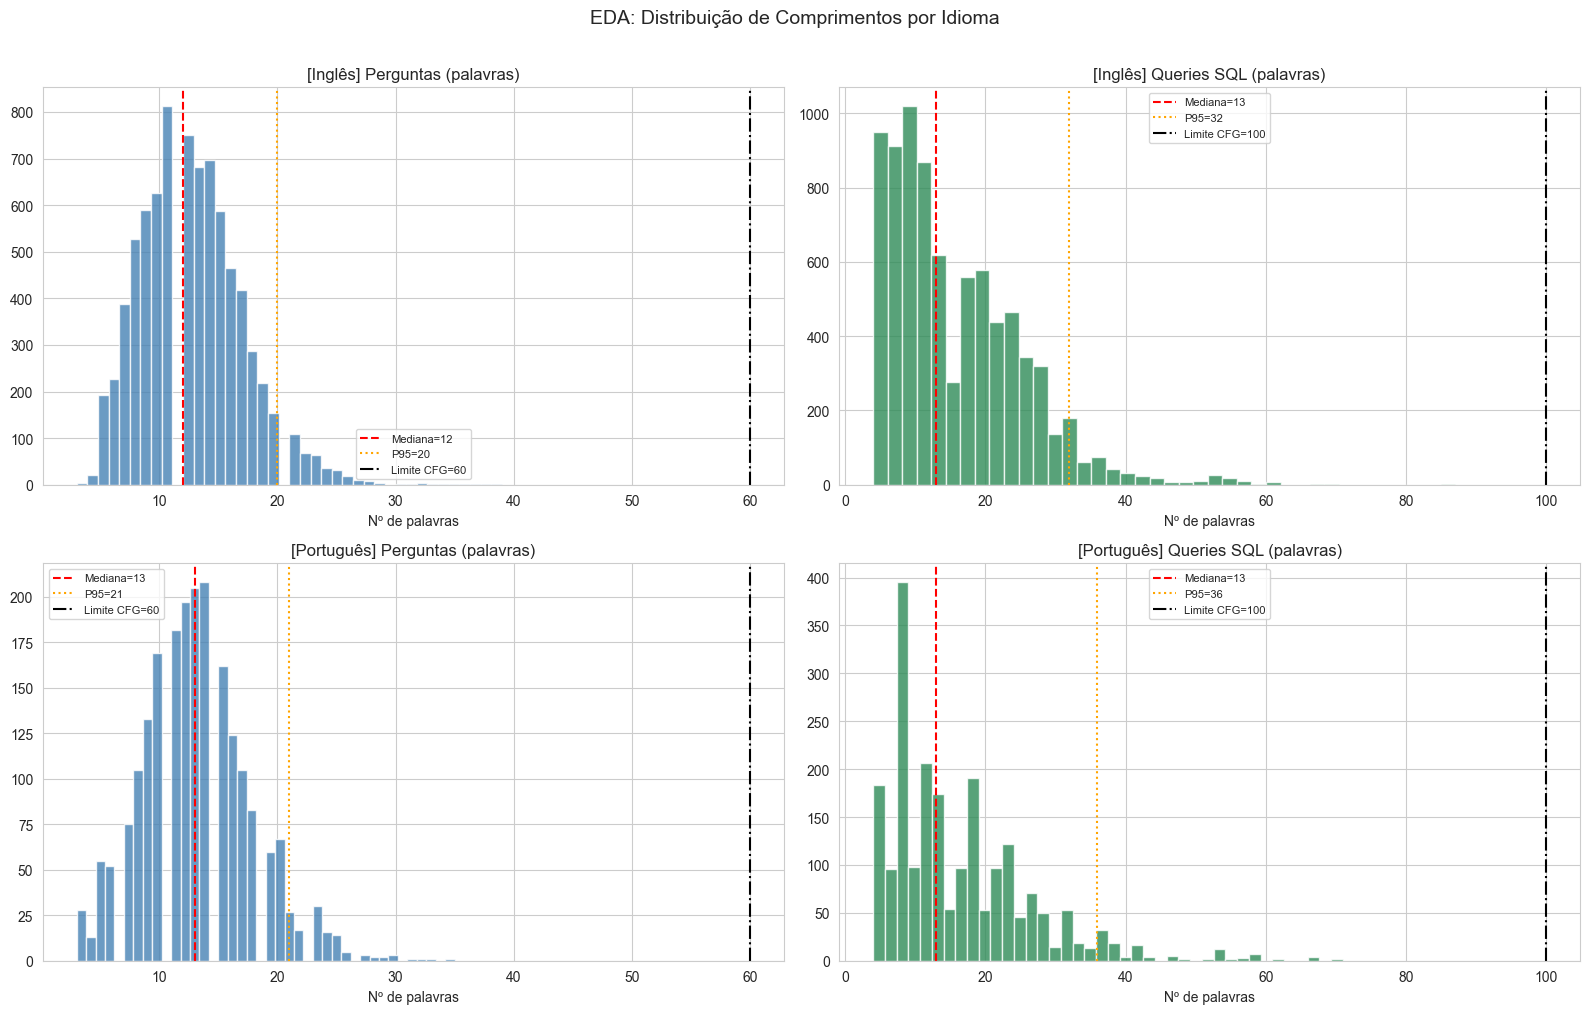

── Estatísticas por idioma ──────────────────────
     q_len_raw                                         sql_len_raw                                        
         count  mean  std  min   25%   50%   75%   max       count  mean   std  min  25%   50%   75%   max
lang                                                                                                      
en      8013.0  12.7  4.3  3.0  10.0  12.0  15.0  39.0      8013.0  15.9   9.4  4.0  9.0  13.0  21.0  87.0
pt      2146.0  13.0  4.6  3.0  10.0  13.0  16.0  35.0      2146.0  16.3  10.3  4.0  9.0  13.0  21.0  71.0

── % acima dos limites do CFG ───────────────────
  [en] Perguntas acima do limite: 0.0%
  [en] Queries acima do limite:   0.0%
  [pt] Perguntas acima do limite: 0.0%
  [pt] Queries acima do limite:   0.0%


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C9 — EDA: DISTRIBUIÇÃO DE COMPRIMENTOS                                  ║
# ║                                                                          ║
# ║  IMPORTANTE: Calculamos comprimentos por split de espaço aqui (EDA       ║
# ║  inicial). Os comprimentos reais de tokens serão recalculados após       ║
# ║  a tokenização (C12). Separamos por idioma para comparação PT vs EN.     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
df_all['q_len_raw']   = df_all['question'].str.split().str.len()
df_all['sql_len_raw'] = df_all['query'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (lang, label) in enumerate([('en','Inglês'), ('pt','Português')]):
    sub = df_all[df_all['lang'] == lang]

    for col, (metric, title, lim_key, color) in enumerate([
        ('q_len_raw',   'Perguntas',   'max_src_len', 'steelblue'),
        ('sql_len_raw', 'Queries SQL', 'max_tgt_len', 'seagreen'),
    ]):
        ax  = axes[row, col]
        med = sub[metric].median()
        p95 = sub[metric].quantile(0.95)

        ax.hist(sub[metric], bins=40, color=color, edgecolor='white', alpha=0.8)
        ax.axvline(med, color='red',    linestyle='--', label=f'Mediana={med:.0f}')
        ax.axvline(p95, color='orange', linestyle=':',  label=f'P95={p95:.0f}')
        ax.axvline(CFG[lim_key], color='black', linestyle='-.',
                   label=f'Limite CFG={CFG[lim_key]}')
        ax.set_title(f'[{label}] {title} (palavras)')
        ax.set_xlabel('Nº de palavras')
        ax.legend(fontsize=8)

plt.suptitle('EDA: Distribuição de Comprimentos por Idioma', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('── Estatísticas por idioma ──────────────────────')
print(df_all.groupby('lang')[['q_len_raw','sql_len_raw']].describe().round(1).to_string())

print('\n── % acima dos limites do CFG ───────────────────')
for lang in ['en', 'pt']:
    sub = df_all[df_all['lang'] == lang]
    pq  = (sub['q_len_raw']   > CFG['max_src_len']).mean() * 100
    ps  = (sub['sql_len_raw'] > CFG['max_tgt_len']).mean() * 100
    print(f'  [{lang}] Perguntas acima do limite: {pq:.1f}%')
    print(f'  [{lang}] Queries acima do limite:   {ps:.1f}%')

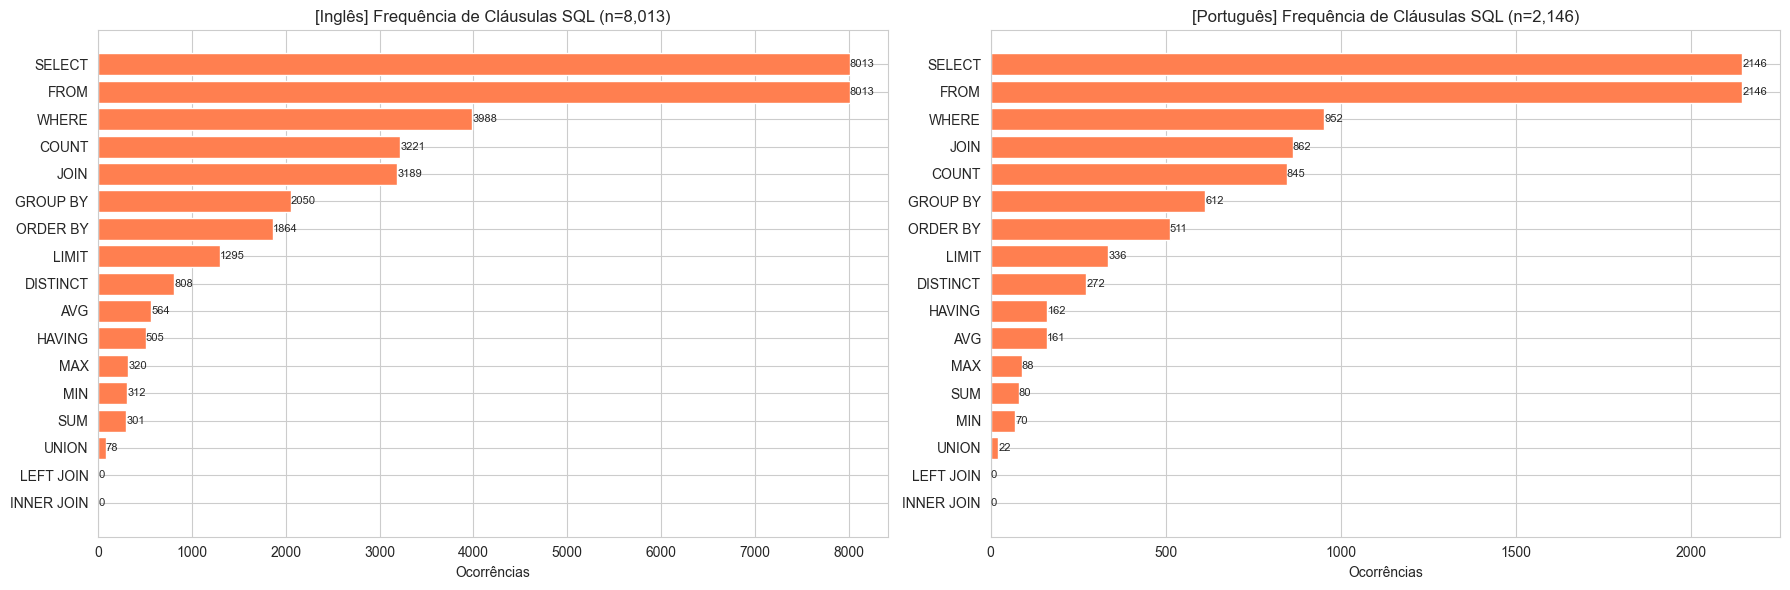


── Comparação EN vs PT ──────────────────────────
              en    pt  diff_%
SELECT      8013  2146    73.2
FROM        8013  2146    73.2
WHERE       3988   952    76.1
COUNT       3221   845    73.8
JOIN        3189   862    73.0
GROUP BY    2050   612    70.1
ORDER BY    1864   511    72.6
LIMIT       1295   336    74.1
DISTINCT     808   272    66.3
AVG          564   161    71.5
HAVING       505   162    67.9
MAX          320    88    72.5
MIN          312    70    77.6
SUM          301    80    73.4
UNION         78    22    71.8
INNER JOIN     0     0     0.0
LEFT JOIN      0     0     0.0


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C10 — EDA: FREQUÊNCIA DE CLÁUSULAS SQL                                  ║
# ║                                                                          ║
# ║  Mostra quais cláusulas SQL são mais comuns em cada idioma.              ║
# ║  Bigrams (GROUP BY, ORDER BY) são normalizados antes da busca.           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
SQL_KEYWORDS = [
    'SELECT', 'FROM', 'WHERE', 'JOIN', 'LEFT JOIN', 'INNER JOIN',
    'GROUP BY', 'ORDER BY', 'HAVING', 'LIMIT', 'UNION',
    'DISTINCT', 'COUNT', 'SUM', 'AVG', 'MAX', 'MIN',
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

kw_data = {}
for ax, (lang, label) in zip(axes, [('en','Inglês'), ('pt','Português')]):
    sub  = df_all[df_all['lang'] == lang]
    norm = sub['query'].str.upper().str.replace(r'\s+', ' ', regex=True)

    counts = {
        kw: norm.str.contains(re.escape(kw)).sum()
        for kw in SQL_KEYWORDS
    }
    kw_data[lang] = counts
    series = pd.Series(counts).sort_values(ascending=True)

    bars = ax.barh(series.index, series.values, color='coral', edgecolor='white')
    ax.set_title(f'[{label}] Frequência de Cláusulas SQL (n={len(sub):,})')
    ax.set_xlabel('Ocorrências')

    for bar, val in zip(bars, series.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Tabela comparativa EN vs PT
kw_df = pd.DataFrame(kw_data).fillna(0).astype(int)
kw_df['diff_%'] = ((kw_df['en'] - kw_df['pt']) / kw_df['en'].replace(0,1) * 100).round(1)
print('\n── Comparação EN vs PT ──────────────────────────')
print(kw_df.sort_values('en', ascending=False).to_string())

## 🔤 PARTE 3 — Pré-processamento e Vocabulário

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C11 — NORMALIZAÇÃO E TOKENIZAÇÃO (CORRIGIDA)                            ║
# ║                                                                          ║
# ║  BUG CORRIGIDO: operador >= era separado em > e = pela regex manual.     ║
# ║  SOLUÇÃO: sqlparse — tokenizador SQL dedicado que trata operadores       ║
# ║  compostos (>=, <=, <>, !=), strings literais e palavras-chave           ║
# ║  SQL corretamente, sem regex frágil.                                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import sqlparse
import sqlparse.tokens as T


def normalize_text(text: str) -> str:
    """Normalização básica: unicode NFC + colapsar espaços."""
    text = str(text).strip()
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def tokenize_question(text: str, lang: str = 'portuguese') -> List[str]:
    """
    Tokeniza pergunta em linguagem natural.
    lang: 'portuguese' para PT, 'english' para EN.
    """
    text = normalize_text(text.lower())
    try:
        tokens = word_tokenize(text, language=lang)
    except LookupError:
        tokens = text.split()
    return tokens


def tokenize_sql(query: str) -> List[str]:
    """
    Tokeniza SQL usando sqlparse.
    Garante que >= <= <> != sejam tokens únicos (bug corrigido).
    Strings literais ('valor') são preservadas como token único.
    Whitespace, newlines e comentários são descartados.
    """
    query   = normalize_text(query.upper())
    parsed  = sqlparse.parse(query)
    if not parsed:
        return query.split()

    # Tipos de token a ignorar
    IGNORE = {
        T.Text.Whitespace,
        T.Text.Whitespace.Newline,
        T.Newline,
        T.Comment.Single,
        T.Comment.Multiline,
        T.Comment,
    }

    tokens = []
    for token in parsed[0].flatten():
        if token.ttype in IGNORE:
            continue
        val = token.value.strip()
        if val:
            tokens.append(val)
    return tokens


# ── Verificação dos operadores compostos ──────────────────────────────────
print('── Verificação da tokenização SQL (operadores compostos) ──\n')

verification_cases = [
    {
        'lang': 'pt',
        'q'  : "Quais alunos tiraram nota acima de 7 na disciplina de Cálculo?",
        'sql': "SELECT nome FROM alunos WHERE nota > 7 AND disciplina = 'Calculo';",
        'ops': [],
    },
    {
        'lang': 'en',
        'q'  : "What students scored at least 7 in Calculus?",
        'sql': "SELECT name FROM students WHERE score >= 7 AND subject = 'Calculus';",
        'ops': ['>='],
    },
    {
        'lang': 'en',
        'q'  : "Find departments where average salary is not equal to 5000",
        'sql': "SELECT dept FROM emp GROUP BY dept HAVING AVG(salary) <> 5000;",
        'ops': ['<>'],
    },
    {
        'lang': 'en',
        'q'  : "List employees with salary below or equal to 3000",
        'sql': "SELECT name FROM emp WHERE salary <= 3000 AND dept != 'HR';",
        'ops': ['<=', '!='],
    },
]

all_ok = True
for case in verification_cases:
    nltk_lang = 'portuguese' if case['lang'] == 'pt' else 'english'
    toks_sql  = tokenize_sql(case['sql'])
    toks_q    = tokenize_question(case['q'], lang=nltk_lang)

    print(f"[{case['lang'].upper()}] SQL: {case['sql']}")
    print(f"  Tokens SQL: {toks_sql}")

    for op in case['ops']:
        if op in case['sql']:
            ok = op in toks_sql
            status = f'✅ {op} preservado' if ok else f'❌ {op} SEPARADO — bug persiste'
            if not ok:
                all_ok = False
            print(f"  Operador {op}: {status}")
    print()

print(f"{'✅ Todos os operadores compostos OK' if all_ok else '❌ Ainda há operadores sendo separados'}")

── Verificação da tokenização SQL (operadores compostos) ──

[PT] SQL: SELECT nome FROM alunos WHERE nota > 7 AND disciplina = 'Calculo';
  Tokens SQL: ['SELECT', 'NOME', 'FROM', 'ALUNOS', 'WHERE', 'NOTA', '>', '7', 'AND', 'DISCIPLINA', '=', "'CALCULO'", ';']

[EN] SQL: SELECT name FROM students WHERE score >= 7 AND subject = 'Calculus';
  Tokens SQL: ['SELECT', 'NAME', 'FROM', 'STUDENTS', 'WHERE', 'SCORE', '>=', '7', 'AND', 'SUBJECT', '=', "'CALCULUS'", ';']
  Operador >=: ✅ >= preservado

[EN] SQL: SELECT dept FROM emp GROUP BY dept HAVING AVG(salary) <> 5000;
  Tokens SQL: ['SELECT', 'DEPT', 'FROM', 'EMP', 'GROUP BY', 'DEPT', 'HAVING', 'AVG', '(', 'SALARY', ')', '<>', '5000', ';']
  Operador <>: ✅ <> preservado

[EN] SQL: SELECT name FROM emp WHERE salary <= 3000 AND dept != 'HR';
  Tokens SQL: ['SELECT', 'NAME', 'FROM', 'EMP', 'WHERE', 'SALARY', '<=', '3000', 'AND', 'DEPT', '!=', "'HR'", ';']
  Operador <=: ✅ <= preservado
  Operador !=: ✅ != preservado

✅ Todos os operadores compo

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C12 — TOKENIZAÇÃO DO DATASET COMPLETO                                   ║
# ║                                                                          ║
# ║  Usa tokenize_sql corrigido com sqlparse (definido em C11).              ║
# ║  Cada linha usa o tokenizador correto para seu idioma.                   ║
# ║  Após tokenizar, filtramos pares que excedem os limites do CFG.          ║
# ║  Inclui verificação automática do >= no dataset real para confirmar      ║
# ║  que o fix foi aplicado corretamente sobre os dados de produção.         ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def tokenize_row_question(row) -> List[str]:
    lang_nltk = 'portuguese' if row['lang'] == 'pt' else 'english'
    return tokenize_question(row['question'], lang=lang_nltk)


print('🔤 Tokenizando perguntas...')
tqdm.pandas(desc='  Perguntas')
df_all['q_tokens'] = df_all.progress_apply(tokenize_row_question, axis=1)

print('🔤 Tokenizando queries SQL...')
tqdm.pandas(desc='  Queries SQL')
df_all['sql_tokens'] = df_all['query'].progress_apply(tokenize_sql)

# Recalcular comprimentos com tokens reais (pós-correção)
df_all['q_len']   = df_all['q_tokens'].apply(len)
df_all['sql_len'] = df_all['sql_tokens'].apply(len)

# ── Verificação dos operadores compostos no dataset real ──────────────────
print('\n── Verificação operadores compostos no dataset real ────────')
ops_to_check = ['>=', '<=', '<>', '!=']
for op in ops_to_check:
    subset = df_all[df_all['query'].str.contains(re.escape(op), na=False)]
    if len(subset) == 0:
        print(f'  {op}: não encontrado no dataset')
        continue
    sample = subset.head(2)
    broken = 0
    for _, row in sample.iterrows():
        toks = row['sql_tokens']
        if op not in toks:
            broken += 1
    status = '✅ OK' if broken == 0 else f'❌ separado em {broken}/2 amostras'
    print(f'  {op}: {len(subset):,} ocorrências no dataset — {status}')

# ── Filtrar por comprimento máximo ────────────────────────────────────────
before = len(df_all)
mask   = (
    (df_all['q_len']   <= CFG['max_src_len']) &
    (df_all['sql_len'] <= CFG['max_tgt_len'])
)
df_all  = df_all[mask].reset_index(drop=True)
after   = len(df_all)
removed = before - after

print(f'\nPares removidos por exceder comprimento: {removed:,} ({removed/before*100:.1f}%)')
print(f'Pares restantes: {after:,}')
print('\nDistribuição final por idioma × split:')
print(df_all.groupby(['lang','split']).size().unstack(fill_value=0).to_string())

🔤 Tokenizando perguntas...


  Perguntas: 100%|██████████| 10159/10159 [00:00<00:00, 22764.06it/s]


🔤 Tokenizando queries SQL...


  Queries SQL: 100%|██████████| 10159/10159 [00:06<00:00, 1579.91it/s]


── Verificação operadores compostos no dataset real ────────
  >=: 335 ocorrências no dataset — ✅ OK
  <=: 63 ocorrências no dataset — ✅ OK
  <>: não encontrado no dataset
  !=: 181 ocorrências no dataset — ✅ OK

Pares removidos por exceder comprimento: 6 (0.1%)
Pares restantes: 10,153

Distribuição final por idioma × split:
split  test  train  validation
lang                          
en      517   6976         516
pt      322   1501         321


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C13 — VOCABULÁRIOS (CORRIGIDA)                                          ║
# ║                                                                          ║
# ║  IMPORTANTE: vocabulário construído APENAS com dados de TREINO           ║
# ║  para evitar data leakage (vazamento de informação do val/test).         ║
# ║                                                                          ║
# ║  Funcionalidades extras:                                                 ║
# ║  - save/load: persistência em JSON                                       ║
# ║  - coverage: % de tokens do corpus cobertos pelo vocabulário             ║
# ║  - decode com skip_special: para avaliação BLEU                          ║
# ║                                                                          ║
# ║  Além do vocabulário compartilhado (ALL), criamos                        ║
# ║  vocabulários específicos por idioma:                                    ║
# ║                                                                          ║
# ║  src_vocab     → perguntas EN+PT (para modelo ALL)                       ║
# ║  src_vocab_en  → perguntas só EN  (para modelo EN-only)                  ║
# ║  src_vocab_pt  → perguntas só PT  (para modelo PT-only)                  ║
# ║  tgt_vocab     → SQL compartilhado (igual para todos — SQL é SQL)        ║
# ║                                                                          ║
# ║  Vocabulários separados eliminam ruído de tokens de um idioma            ║
# ║  dentro do modelo do outro idioma.                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class Vocabulary:
    """Vocabulário bidirecional token ↔ índice com persistência e diagnóstico."""

    SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

    def __init__(self, name: str, min_freq: int = 1):
        self.name      = name
        self.min_freq  = min_freq
        self.token2idx: Dict[str, int] = {}
        self.idx2token: Dict[int, str] = {}
        self._init_specials()

    def _init_specials(self):
        for i, tok in enumerate(self.SPECIAL_TOKENS):
            self.token2idx[tok] = i
            self.idx2token[i]   = tok

    def build_from_corpus(self, token_lists: List[List[str]]):
        counter = Counter(tok for toks in token_lists for tok in toks)
        # most_common: tokens mais frequentes primeiro
        for token, freq in counter.most_common():
            if freq >= self.min_freq and token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx]   = token
        print(f'Vocabulário [{self.name}]: {len(self):,} tokens (min_freq={self.min_freq})')

    def encode(self, tokens: List[str],
               max_len: Optional[int] = None) -> List[int]:
        ids = [self.token2idx.get(t, UNK_IDX) for t in tokens]
        return ids[:max_len] if max_len else ids

    def decode(self, indices: List[int],
               skip_special: bool = False) -> List[str]:
        special_ids = {PAD_IDX, SOS_IDX, UNK_IDX}
        tokens = []
        for i in indices:
            if i == EOS_IDX:
                break   # parar no EOS
            if skip_special and i in special_ids:
                continue
            tokens.append(self.idx2token.get(i, UNK_TOKEN))
        return tokens

    def coverage(self, token_lists: List[List[str]]) -> float:
        all_toks = [t for toks in token_lists for t in toks]
        if not all_toks:
            return 0.0
        known = sum(1 for t in all_toks if t in self.token2idx)
        return known / len(all_toks) * 100

    def save(self, path: str):
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({'name': self.name, 'min_freq': self.min_freq,
                       'token2idx': self.token2idx}, f,
                      ensure_ascii=False, indent=2)
        print(f"  Vocabulário [{self.name}] salvo em '{path}'")

    @classmethod
    def load(cls, path: str) -> 'Vocabulary':
        with open(path, encoding='utf-8') as f:
            data = json.load(f)
        vocab = cls(data['name'], data['min_freq'])
        vocab.token2idx = data['token2idx']
        vocab.idx2token = {int(i): t for t, i in data['token2idx'].items()}
        print(f"  Vocabulário [{vocab.name}] carregado: {len(vocab):,} tokens")
        return vocab

    def __len__(self) -> int:
        return len(self.token2idx)
    
train_mask    = df_all['split'] == 'train'
train_en_mask = train_mask & (df_all['lang'] == 'en')
train_pt_mask = train_mask & (df_all['lang'] == 'pt')

print(f'Construindo vocabulários...')
print(f'  Treino ALL: {train_mask.sum():,} | EN: {train_en_mask.sum():,} | PT: {train_pt_mask.sum():,}\n')

# Vocabulário compartilhado (modelo ALL)
src_vocab = Vocabulary('source_all', min_freq=CFG['min_freq'])
src_vocab.build_from_corpus(df_all.loc[train_mask, 'q_tokens'].tolist())

# Vocabulário EN-only (para modelo EN sem ruído de tokens PT)
src_vocab_en = Vocabulary('source_en', min_freq=CFG['min_freq'])
src_vocab_en.build_from_corpus(df_all.loc[train_en_mask, 'q_tokens'].tolist())

# Vocabulário PT-only (para modelo PT sem ruído de tokens EN)
src_vocab_pt = Vocabulary('source_pt', min_freq=CFG['min_freq'])
src_vocab_pt.build_from_corpus(df_all.loc[train_pt_mask, 'q_tokens'].tolist())

# Vocabulário SQL — compartilhado para todos (SQL é independente de idioma)
tgt_vocab = Vocabulary('target_sql', min_freq=CFG['min_freq'])
tgt_vocab.build_from_corpus(df_all.loc[train_mask, 'sql_tokens'].tolist())

# ── Diagnóstico de overlap entre vocabulários EN e PT ─────────────────────
toks_en_set = set(src_vocab_en.token2idx.keys()) - set(Vocabulary.SPECIAL_TOKENS)
toks_pt_set = set(src_vocab_pt.token2idx.keys()) - set(Vocabulary.SPECIAL_TOKENS)

shared   = toks_en_set & toks_pt_set
only_en  = toks_en_set - toks_pt_set
only_pt  = toks_pt_set - toks_en_set

print(f'\n── Análise de overlap vocabulário ───────────────────────')
print(f'  Tokens exclusivos EN: {len(only_en):,}')
print(f'  Tokens exclusivos PT: {len(only_pt):,}')
print(f'  Tokens compartilhados EN∩PT: {len(shared):,}')
print(f'  Ruído eliminado no modelo EN: {len(only_pt):,} tokens PT não aparecem mais')
print(f'  Ruído eliminado no modelo PT: {len(only_en):,} tokens EN não aparecem mais')

# Cobertura
print(f'\n── Cobertura dos vocabulários ───────────────────────────')
print(f'  src_vocab    (ALL): {src_vocab.coverage(df_all["q_tokens"].tolist()):.2f}%')
print(f'  src_vocab_en  (EN): {src_vocab_en.coverage(df_all.loc[df_all["lang"]=="en", "q_tokens"].tolist()):.2f}%')
print(f'  src_vocab_pt  (PT): {src_vocab_pt.coverage(df_all.loc[df_all["lang"]=="pt", "q_tokens"].tolist()):.2f}%')
print(f'  tgt_vocab    (SQL): {tgt_vocab.coverage(df_all["sql_tokens"].tolist()):.2f}%')

# Persistir todos os vocabulários
vocab_dir = Path(CFG['vocab_dir'])
src_vocab.save(str(vocab_dir / 'src_vocab_all.json'))
src_vocab_en.save(str(vocab_dir / 'src_vocab_en.json'))
src_vocab_pt.save(str(vocab_dir / 'src_vocab_pt.json'))
tgt_vocab.save(str(vocab_dir / 'tgt_vocab.json'))

Construindo vocabulários...
  Treino ALL: 8,477 | EN: 6,976 | PT: 1,501

Vocabulário [source_all]: 2,410 tokens (min_freq=3)
Vocabulário [source_en]: 1,755 tokens (min_freq=3)
Vocabulário [source_pt]: 721 tokens (min_freq=3)
Vocabulário [target_sql]: 2,105 tokens (min_freq=3)

── Análise de overlap vocabulário ───────────────────────
  Tokens exclusivos EN: 1,669
  Tokens exclusivos PT: 635
  Tokens compartilhados EN∩PT: 82
  Ruído eliminado no modelo EN: 635 tokens PT não aparecem mais
  Ruído eliminado no modelo PT: 1,669 tokens EN não aparecem mais

── Cobertura dos vocabulários ───────────────────────────
  src_vocab    (ALL): 96.56%
  src_vocab_en  (EN): 96.67%
  src_vocab_pt  (PT): 95.37%
  tgt_vocab    (SQL): 97.43%
  Vocabulário [source_all] salvo em 'checkpoints\vocabs\src_vocab_all.json'
  Vocabulário [source_en] salvo em 'checkpoints\vocabs\src_vocab_en.json'
  Vocabulário [source_pt] salvo em 'checkpoints\vocabs\src_vocab_pt.json'
  Vocabulário [target_sql] salvo em 'checkp

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C14 — DATALOADERS (CORRIGIDA)                                           ║
# ║  Text2SQLDataset: converte tokens em tensores, adiciona SOS/EOS          ║
# ║  collate_fn: padding dinâmico por batch (sem padding fixo global)        ║
# ║  build_loaders: respeita splits nativos do DataFrame                     ║
# ║                                                                          ║
# ║  CORREÇÃO: loaders EN usam src_vocab_en, loaders PT usam src_vocab_pt.   ║
# ║  Antes, todos usavam src_vocab compartilhado, fazendo o embedding do     ║
# ║  modelo EN carregar ~2k tokens PT irrelevantes.                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

class Text2SQLDataset(Dataset):
    """Dataset PyTorch para pares (pergunta → SQL)."""

    def __init__(self, df: pd.DataFrame,
                 src_vocab: Vocabulary,
                 tgt_vocab: Vocabulary,
                 max_src_len: Optional[int] = None,
                 max_tgt_len: Optional[int] = None):
        self.src_vocab   = src_vocab
        self.tgt_vocab   = tgt_vocab
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        self.src_tokens  = df['q_tokens'].tolist()
        self.tgt_tokens  = df['sql_tokens'].tolist()

    def __len__(self) -> int:
        return len(self.src_tokens)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        src_ids = self.src_vocab.encode(self.src_tokens[idx], self.max_src_len)
        tgt_ids = ([SOS_IDX]
                   + self.tgt_vocab.encode(self.tgt_tokens[idx], self.max_tgt_len)
                   + [EOS_IDX])
        return (torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long))


def collate_fn(
    batch: List[Tuple[torch.Tensor, torch.Tensor]]
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Padding dinâmico — pad só até o maior elemento do batch atual."""
    src_seqs, tgt_seqs = zip(*batch)
    src_padded  = pad_sequence(src_seqs, batch_first=True, padding_value=PAD_IDX)
    tgt_padded  = pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD_IDX)
    src_lengths = torch.tensor([len(s) for s in src_seqs], dtype=torch.long)
    tgt_lengths = torch.tensor([len(t) for t in tgt_seqs], dtype=torch.long)
    return src_padded, tgt_padded, src_lengths, tgt_lengths

def build_loaders(df: pd.DataFrame,
                  src_vocab: Vocabulary,
                  tgt_vocab: Vocabulary,
                  cfg: dict,
                  lang_filter: Optional[str] = None) -> Dict[str, DataLoader]:
    """
    Constrói DataLoaders para cada split respeitando a coluna 'split'.
    lang_filter: 'en' | 'pt' | None (ambos).
    src_vocab deve ser o vocabulário específico do idioma filtrado.
    """
    loaders   = {}
    split_cfg = {
        'train'     : {'shuffle': True,  'drop_last': True},
        'validation': {'shuffle': False, 'drop_last': False},
        'test'      : {'shuffle': False, 'drop_last': False},
    }
    for split, params in split_cfg.items():
        mask = df['split'] == split
        if lang_filter:
            mask &= df['lang'] == lang_filter
        sub = df[mask].reset_index(drop=True)
        if len(sub) == 0:
            print(f'  ⚠️  split="{split}" vazio para lang={lang_filter}')
            continue
        dataset = Text2SQLDataset(
            sub, src_vocab, tgt_vocab,
            max_src_len = cfg['max_src_len'],
            max_tgt_len = cfg['max_tgt_len'],
        )
        loaders[split] = DataLoader(
            dataset,
            batch_size = cfg['batch_size'],
            shuffle    = params['shuffle'],
            drop_last  = params['drop_last'],
            collate_fn = collate_fn,
            num_workers = 0,
            pin_memory  = torch.cuda.is_available(),
        )
        tag = lang_filter or 'all'
        print(f'  [{tag}] {split:12s}: {len(dataset):>5,} amostras | '
              f'{len(loaders[split]):>3} batches')
    return loaders


print('══ Construindo DataLoaders ══════════════════════════════')

# ALL usa vocabulário compartilhado
print('\n▶ Loaders ALL (vocabulário compartilhado EN+PT):')
loaders_all = build_loaders(df_all, src_vocab, tgt_vocab, CFG, lang_filter=None)

# EN usa vocabulário exclusivo EN — sem tokens PT como ruído
print('\n▶ Loaders EN (vocabulário exclusivo EN):')
loaders_en = build_loaders(df_all, src_vocab_en, tgt_vocab, CFG, lang_filter='en')

# PT usa vocabulário exclusivo PT — sem tokens EN como ruído
print('\n▶ Loaders PT (vocabulário exclusivo PT):')
loaders_pt = build_loaders(df_all, src_vocab_pt, tgt_vocab, CFG, lang_filter='pt')

# Aliases para o loop de treino
train_loader = loaders_all.get('train')
val_loader   = loaders_all.get('validation')
test_loader  = loaders_all.get('test')

# ── Verificação de splits por idioma ──────────────────────────────────────
print('\n── Verificação final de splits ──────────────────────────')
for lang in ['en', 'pt']:
    for split in ['train', 'validation', 'test']:
        n      = len(df_all[(df_all['lang'] == lang) & (df_all['split'] == split)])
        status = '✅' if n > 0 else '⚠️  vazio'
        print(f'  [{lang}] {split:12s}: {n:>5,} amostras  {status}')

print('\n✅ DataLoaders prontos.')

══ Construindo DataLoaders ══════════════════════════════

▶ Loaders ALL (vocabulário compartilhado EN+PT):
  [all] train       : 8,477 amostras | 132 batches
  [all] validation  :   837 amostras |  14 batches
  [all] test        :   839 amostras |  14 batches

▶ Loaders EN (vocabulário exclusivo EN):
  [en] train       : 6,976 amostras | 109 batches
  [en] validation  :   516 amostras |   9 batches
  [en] test        :   517 amostras |   9 batches

▶ Loaders PT (vocabulário exclusivo PT):
  [pt] train       : 1,501 amostras |  23 batches
  [pt] validation  :   321 amostras |   6 batches
  [pt] test        :   322 amostras |   6 batches

── Verificação final de splits ──────────────────────────
  [en] train       : 6,976 amostras  ✅
  [en] validation  :   516 amostras  ✅
  [en] test        :   517 amostras  ✅
  [pt] train       : 1,501 amostras  ✅
  [pt] validation  :   321 amostras  ✅
  [pt] test        :   322 amostras  ✅

✅ DataLoaders prontos.


## 🏗️ PARTE 4 — Arquitetura Seq2Seq com Atenção de Bahdanau

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C15 — ENCODER BIDIRECIONAL (CORRIGIDO)                                  ║
# ║                                                                          ║
# ║  LSTM Bidirecional: processa a sequência em ambas as direções            ║
# ║  → captura contexto anterior E posterior de cada palavra.                ║
# ║                                                                          ║
# ║  Projeção linear: o encoder bidirecional produz hidden de tamanho        ║
# ║  2*hidden_dim. A projeção comprime para hidden_dim para compatibilizar   ║
# ║  com o decoder (que é unidirecional).                                    ║
# ║                                                                          ║
# ║  pack_padded_sequence: ignora tokens de padding durante o cálculo        ║
# ║  da LSTM, tornando o processo mais eficiente e correto.                  ║
# ║                                                                          ║ 
# ║  CORREÇÃO: _merge substituída por lógica explícita que funciona          ║
# ║  corretamente para qualquer num_layers, não apenas 2.                    ║
# ║  Antes: apenas hidden[-2] e hidden[-1] eram usados, descartando          ║
# ║  camadas intermediárias silenciosamente quando num_layers > 2.           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class Encoder(nn.Module):
    """
    Codifica a pergunta em linguagem natural em estados ocultos.
    LSTM bidirecional + projeção para compatibilizar com decoder.
    """

    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_dim: int, num_layers: int, dropout: float,
                 bidirectional: bool = True):
        super().__init__()
        self.hidden_dim    = hidden_dim
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.num_dirs      = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0,
            bidirectional = bidirectional,
        )
        self.dropout = nn.Dropout(dropout)

        # Projeção: comprime saída bidirecional (2*hidden) → hidden
        # Aplicada por camada para suportar qualquer num_layers
        if bidirectional:
            self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
            self.fc_cell   = nn.Linear(hidden_dim * 2, hidden_dim)
            self.fc_output = nn.Linear(hidden_dim * 2, hidden_dim)

    def _merge_state(self, state: torch.Tensor,
                     fc: nn.Linear) -> torch.Tensor:
        """
        Combina as direções forward e backward de TODAS as camadas.

        state shape: (num_layers * 2, batch, hidden_dim)
        PyTorch organiza como: [fwd_layer0, bwd_layer0, fwd_layer1, bwd_layer1, ...]

        Retorna: (num_layers, batch, hidden_dim)
        """
        # Separar forward (índices pares) e backward (índices ímpares)
        fwd = state[0::2]  # (num_layers, batch, hidden_dim)
        bwd = state[1::2]  # (num_layers, batch, hidden_dim)

        # Concatenar e projetar cada camada individualmente
        merged = torch.cat([fwd, bwd], dim=2)  # (num_layers, batch, hidden_dim*2)

        # Aplicar a projeção linear em cada camada (via reshape)
        num_layers, batch, _ = merged.shape
        merged_flat = merged.reshape(num_layers * batch, -1)  # (L*B, hidden*2)
        projected   = fc(merged_flat)                          # (L*B, hidden)
        return torch.tanh(projected.reshape(num_layers, batch, -1))

    def forward(
        self,
        src: torch.Tensor,         # (batch, src_len)
        src_lengths: torch.Tensor,
    ) -> Tuple[torch.Tensor, Tuple]:

        embedded = self.dropout(self.embedding(src))  # (batch, src_len, embed)

        # Garantir que src_lengths não exceda o tamanho real da sequência
        src_lengths = src_lengths.clamp(max=src.size(1))

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(),
            batch_first=True, enforce_sorted=False
        )
        outputs, (hidden, cell) = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            outputs, batch_first=True
        )
        # outputs: (batch, src_len, hidden_dim * num_dirs)

        if self.bidirectional:
            # Projetar hidden e cell de todas as camadas corretamente
            hidden  = self._merge_state(hidden, self.fc_hidden)
            cell    = self._merge_state(cell,   self.fc_cell)
            # Projetar outputs de (hidden*2) → (hidden)
            outputs = torch.tanh(self.fc_output(outputs))

        return outputs, (hidden, cell)

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C16 — ATENÇÃO DE BAHDANAU (Additive Attention)                          ║
# ║                                                                          ║
# ║  Fórmula: score(s, h) = v^T · tanh(W_s·s + W_h·h)                        ║
# ║  onde s = estado do decoder, h = estado do encoder                       ║
# ║                                                                          ║
# ║  MELHORIA CRÍTICA: máscara de padding — tokens PAD no encoder            ║
# ║  recebem peso -inf antes do softmax, resultando em peso ≈ 0.             ║
# ║  Sem isso, o modelo "presta atenção" em tokens que não existem.          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class BahdanauAttention(nn.Module):
    """Atenção aditiva com máscara de padding."""

    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W_s = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v   = nn.Linear(hidden_dim, 1,          bias=False)

    def forward(
        self,
        decoder_hidden:  torch.Tensor,    # (batch, hidden_dim)
        encoder_outputs: torch.Tensor,    # (batch, src_len, hidden_dim)
        src_mask:        Optional[torch.Tensor] = None,  # (batch, src_len)
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        s = decoder_hidden.unsqueeze(1).expand_as(encoder_outputs)
        energy = self.v(
            torch.tanh(self.W_s(s) + self.W_h(encoder_outputs))
        ).squeeze(-1)  # (batch, src_len)

        # Mascarar posições de padding com -inf para que softmax → 0
        if src_mask is not None:
            energy = energy.masked_fill(src_mask == 0, float('-inf'))

        attn_weights = F.softmax(energy, dim=1)  # (batch, src_len)

        # Vetor de contexto: média ponderada dos estados do encoder
        context = torch.bmm(
            attn_weights.unsqueeze(1), encoder_outputs
        ).squeeze(1)   # (batch, hidden_dim)

        return context, attn_weights

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C17 — DECODER COM ATENÇÃO                                               ║
# ║                                                                          ║
# ║  Gera SQL token a token usando 'input feeding':                          ║
# ║  → o vetor de contexto é concatenado ao embedding antes do LSTM          ║
# ║  → forçando o modelo a considerar a atenção a cada passo                 ║
# ║                                                                          ║
# ║  Projeção final: [output + context + embedding] → vocab                  ║
# ║  Essa concatenação tripla é uma heurística clássica (Luong et al.)       ║
# ║  que melhora a geração ao preservar informação do input original.        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class Decoder(nn.Module):
    """Decoder auto-regressivo com atenção de Bahdanau e input feeding."""

    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.attention = BahdanauAttention(hidden_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(
            embed_dim + hidden_dim,
            hidden_dim,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0,
        )
        # Projeção: [hidden + context + embed] → vocab
        self.fc_out = nn.Linear(hidden_dim * 2 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(
        self,
        input_token:     torch.Tensor,     # (batch,)
        hidden:          Tuple,
        encoder_outputs: torch.Tensor,     # (batch, src_len, hidden_dim)
        src_mask:        Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, Tuple, torch.Tensor]:

        embedded = self.dropout(
            self.embedding(input_token.unsqueeze(1))
        )  # (batch, 1, embed)

        decoder_hidden_top = hidden[0][-1]   # último layer: (batch, hidden)
        context, attn_weights = self.attention(
            decoder_hidden_top, encoder_outputs, src_mask
        )

        rnn_input = torch.cat(
            [embedded, context.unsqueeze(1)], dim=2
        )  # (batch, 1, embed+hidden)
        output, hidden = self.rnn(rnn_input, hidden)   # (batch, 1, hidden)

        output_sq   = output.squeeze(1)    # (batch, hidden)
        embedded_sq = embedded.squeeze(1)  # (batch, embed)

        logits = self.fc_out(
            torch.cat([output_sq, context, embedded_sq], dim=1)
        )  # (batch, vocab)

        return logits, hidden, attn_weights

In [18]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C18 — SEQ2SEQ: ORQUESTRADOR ENCODER + DECODER (CORRIGIDO)               ║
# ║  Teacher Forcing: com probabilidade p, usa o token REAL como próximo     ║
# ║  input do decoder (acelera treinamento). Com prob (1-p), usa o token     ║
# ║  que o modelo prediz (mais realista para inferência).                    ║
# ║                                                                          ║
# ║  src_mask: construída a partir dos tokens PAD na sequência de entrada    ║
# ║  e passada para o mecanismo de atenção.                                  ║
# ║                                                                          ║
# ║  Método translate: inferência pura sem teacher forcing,                  ║
# ║  retorna tokens decodificados como string.                               ║
# ║                                                                          ║
# ║  CORREÇÃO no método translate():                                         ║
# ║  Antes: encode(tokens, self.encoder.rnn.input_size)                      ║
# ║         → input_size = embed_dim = 256 (truncava em 256 tokens)          ║
# ║  Depois: encode(tokens, CFG['max_src_len'])                              ║
# ║         → trunca no limite correto definido no CFG (60 tokens)           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
class Seq2Seq(nn.Module):
    Modelo seq2seq completo: encoder bidirecional + decoder com atenção.

    def __init__(self, encoder: Encoder, decoder: Decoder,
                 src_vocab: Vocabulary, tgt_vocab: Vocabulary,
                 device: torch.device):
        super().__init__()
        self.encoder   = encoder
        self.decoder   = decoder
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.device    = device

    def make_src_mask(self, src: torch.Tensor) -> torch.Tensor:
        Cria máscara booleana: 1 onde token != PAD, 0 onde é PAD.
        return (src != PAD_IDX)  # (batch, src_len)

    def forward(
        self,
        src: torch.Tensor,
        src_lengths: torch.Tensor,
        tgt: torch.Tensor,
        teacher_forcing_ratio: float = 0.5,
    ) -> torch.Tensor:

        batch_size = src.size(0)
        tgt_len    = tgt.size(1)
        vocab_size = self.decoder.fc_out.out_features

        outputs  = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        src_mask = self.make_src_mask(src).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)
        input_token = tgt[:, 0]   # <SOS>

        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder.forward_step(
                input_token, hidden, encoder_outputs, src_mask
            )
            outputs[:, t, :] = logits

            use_teacher = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if use_teacher else logits.argmax(dim=1)

        return outputs

    @torch.no_grad()
    def translate(self, question: str, lang: str = 'pt',
                  max_len: int = 100) -> str:
        
        Inferência: recebe pergunta em texto e retorna SQL como string.

        Parâmetros:
            question: pergunta em linguagem natural
            lang: 'pt' ou 'en' — define o tokenizador NLTK correto
            max_len: limite de tokens gerados na saída SQL
        
        self.eval()
        nltk_lang = 'portuguese' if lang == 'pt' else 'english'

        # Tokenizar a pergunta
        tokens = tokenize_question(question, lang=nltk_lang)

        # CORREÇÃO: usar max_src_len do CFG, não input_size do RNN
        # input_size = embed_dim (256) — sem relação com comprimento da sequência
        src_ids = self.src_vocab.encode(tokens, max_len=CFG['max_src_len'])

        src     = torch.tensor([src_ids], dtype=torch.long).to(self.device)
        src_len = torch.tensor([len(src_ids)], dtype=torch.long)
        src_mask = self.make_src_mask(src).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_len)
        input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(self.device)

        pred_ids = []
        for _ in range(max_len):
            logits, hidden, _ = self.decoder.forward_step(
                input_token, hidden, encoder_outputs, src_mask
            )
            pred_id = logits.argmax(dim=1)
            if pred_id.item() == EOS_IDX:
                break
            pred_ids.append(pred_id.item())
            input_token = pred_id

        return ' '.join(self.tgt_vocab.decode(pred_ids, skip_special=True))


# ── Instanciar modelo padrão (ALL) ───────────────────────────────────────
# Nota: make_fresh_model() na C21 instancia modelos por idioma com
# o vocab correto. Este modelo padrão é apenas para verificação de C18/C19.
encoder = Encoder(
    vocab_size    = len(src_vocab),
    embed_dim     = CFG['embed_dim'],
    hidden_dim    = CFG['hidden_dim'],
    num_layers    = CFG['num_layers'],
    dropout       = CFG['dropout'],
    bidirectional = CFG['bidirectional'],
)

decoder = Decoder(
    vocab_size = len(tgt_vocab),
    embed_dim  = CFG['embed_dim'],
    hidden_dim = CFG['hidden_dim'],
    num_layers = CFG['num_layers'],
    dropout    = CFG['dropout'],
)

model = Seq2Seq(encoder, decoder, src_vocab, tgt_vocab, DEVICE).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Modelo criado | Parâmetros treináveis: {n_params:,}')
print(f'   Encoder: {"Bidirecional" if CFG["bidirectional"] else "Unidirecional"}')
print(f'   Vocab src: {len(src_vocab):,} | Vocab tgt: {len(tgt_vocab):,}')
"""

'\nclass Seq2Seq(nn.Module):\n    Modelo seq2seq completo: encoder bidirecional + decoder com atenção.\n\n    def __init__(self, encoder: Encoder, decoder: Decoder,\n                 src_vocab: Vocabulary, tgt_vocab: Vocabulary,\n                 device: torch.device):\n        super().__init__()\n        self.encoder   = encoder\n        self.decoder   = decoder\n        self.src_vocab = src_vocab\n        self.tgt_vocab = tgt_vocab\n        self.device    = device\n\n    def make_src_mask(self, src: torch.Tensor) -> torch.Tensor:\n        Cria máscara booleana: 1 onde token != PAD, 0 onde é PAD.\n        return (src != PAD_IDX)  # (batch, src_len)\n\n    def forward(\n        self,\n        src: torch.Tensor,\n        src_lengths: torch.Tensor,\n        tgt: torch.Tensor,\n        teacher_forcing_ratio: float = 0.5,\n    ) -> torch.Tensor:\n\n        batch_size = src.size(0)\n        tgt_len    = tgt.size(1)\n        vocab_size = self.decoder.fc_out.out_features\n\n        outputs  =

In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C18 — SEQ2SEQ: ORQUESTRADOR ENCODER + DECODER (CORRIGIDO v2)           ║
# ║                                                                          ║
# ║  CORREÇÃO v2 — anti-loop no translate():                                ║
# ║  O decoder pode entrar em loop de dois tipos:                           ║
# ║    Tipo 1: token único repetido — FROM FROM FROM FROM                   ║
# ║    Tipo 2: padrão alternado repetido — T1 . T1 . T1 .                  ║
# ║  A verificação de janela deslizante captura ambos sem limitar           ║
# ║  o comprimento legítimo da query gerada.                                ║
# ║                                                                          ║
# ║  Lógica: se os últimos N tokens formam um padrão que se repete          ║
# ║  K vezes, o decoder está em loop e deve parar.                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class Seq2Seq(nn.Module):
    """Modelo seq2seq completo: encoder bidirecional + decoder com atenção."""

    def __init__(self, encoder: Encoder, decoder: Decoder,
                 src_vocab: Vocabulary, tgt_vocab: Vocabulary,
                 device: torch.device):
        super().__init__()
        self.encoder   = encoder
        self.decoder   = decoder
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.device    = device

    def make_src_mask(self, src: torch.Tensor) -> torch.Tensor:
        """Cria máscara booleana: 1 onde token != PAD, 0 onde é PAD."""
        return (src != PAD_IDX)

    @staticmethod
    def _detect_loop(pred_ids: List[int],
                     pattern_sizes: Tuple[int, ...] = (1, 2, 3),
                     min_repeats: int = 3) -> bool:
        """
        Detecta loops de geração verificando padrões repetidos.

        Verifica se os últimos tokens formam um padrão de tamanho
        pattern_size que se repete min_repeats vezes consecutivas.

        Exemplos detectados:
          pattern_size=1, repeats=3: [FROM, FROM, FROM]
          pattern_size=2, repeats=3: [T1, ., T1, ., T1, .]
          pattern_size=3, repeats=3: [AS, T1, ., AS, T1, ., AS, T1, .]

        Parâmetros:
          pred_ids:     lista de IDs gerados até o momento
          pattern_sizes: tamanhos de padrão a verificar
          min_repeats:  quantas repetições consecutivas caracterizam loop
        """
        for psize in pattern_sizes:
            window = psize * min_repeats
            if len(pred_ids) < window:
                continue
            tail    = pred_ids[-window:]
            pattern = tail[:psize]
            # Verificar se o padrão se repete min_repeats vezes
            if all(tail[i:i+psize] == pattern
                   for i in range(0, window, psize)):
                return True
        return False

    def forward(
        self,
        src: torch.Tensor,
        src_lengths: torch.Tensor,
        tgt: torch.Tensor,
        teacher_forcing_ratio: float = 0.5,
    ) -> torch.Tensor:

        batch_size = src.size(0)
        tgt_len    = tgt.size(1)
        vocab_size = self.decoder.fc_out.out_features

        outputs  = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        src_mask = self.make_src_mask(src).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder.forward_step(
                input_token, hidden, encoder_outputs, src_mask
            )
            outputs[:, t, :] = logits
            use_teacher = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if use_teacher else logits.argmax(dim=1)

        return outputs

    @torch.no_grad()
    def translate(self, question: str, lang: str = 'pt',
                  max_len: int = 100) -> str:
        """
        Inferência: recebe pergunta em texto e retorna SQL.

        A detecção de loop interrompe a geração quando o decoder
        entra em ciclo, sem impor limite fixo de comprimento.
        O max_len é apenas um safety net final.
        """
        self.eval()
        nltk_lang = 'portuguese' if lang == 'pt' else 'english'
        tokens    = tokenize_question(question, lang=nltk_lang)
        src_ids   = self.src_vocab.encode(tokens, max_len=CFG['max_src_len'])

        src      = torch.tensor([src_ids], dtype=torch.long).to(self.device)
        src_len  = torch.tensor([len(src_ids)], dtype=torch.long)
        src_mask = self.make_src_mask(src).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_len)
        input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(self.device)

        pred_ids = []
        for _ in range(max_len):
            logits, hidden, _ = self.decoder.forward_step(
                input_token, hidden, encoder_outputs, src_mask
            )
            pred_id = logits.argmax(dim=1)

            if pred_id.item() == EOS_IDX:
                break

            pred_ids.append(pred_id.item())

            # Detectar loop antes de continuar
            if self._detect_loop(pred_ids,
                                  pattern_sizes=(1, 2, 3),
                                  min_repeats=3):
                break

            input_token = pred_id

        return ' '.join(self.tgt_vocab.decode(pred_ids, skip_special=True))


# ── Instanciar modelo padrão (ALL) para verificação C18/C19 ───────────────
encoder = Encoder(
    vocab_size    = len(src_vocab),
    embed_dim     = CFG['embed_dim'],
    hidden_dim    = CFG['hidden_dim'],
    num_layers    = CFG['num_layers'],
    dropout       = CFG['dropout'],
    bidirectional = CFG['bidirectional'],
)
decoder = Decoder(
    vocab_size = len(tgt_vocab),
    embed_dim  = CFG['embed_dim'],
    hidden_dim = CFG['hidden_dim'],
    num_layers = CFG['num_layers'],
    dropout    = CFG['dropout'],
)
model = Seq2Seq(encoder, decoder, src_vocab, tgt_vocab, DEVICE).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Modelo criado | Parâmetros treináveis: {n_params:,}')
print(f'   Encoder: {"Bidirecional" if CFG["bidirectional"] else "Unidirecional"}')
print(f'   Vocab src: {len(src_vocab):,} | Vocab tgt: {len(tgt_vocab):,}')

# ── Verificar detecção de loop ────────────────────────────────────────────
print('\n── Teste da detecção de loop ────────────────────────────────────')
casos = [
    ([1, 2, 3, 4, 4, 4],          True,  'token único repetido 3x'),
    ([1, 2, 3, 4, 5, 4, 5, 4, 5], True,  'par alternado repetido 3x'),
    ([1, 2, 3, 4, 5, 6],          False, 'sequência normal sem loop'),
    ([1, 2, 1, 2, 1],             False, 'par repetido apenas 2x (abaixo do limite)'),
]
for ids, esperado, descricao in casos:
    resultado = Seq2Seq._detect_loop(ids)
    status = '✅' if resultado == esperado else '❌'
    print(f'  {status} {descricao}: detectado={resultado}')

✅ Modelo criado | Parâmetros treináveis: 7,244,345
   Encoder: Bidirecional
   Vocab src: 2,410 | Vocab tgt: 2,105

── Teste da detecção de loop ────────────────────────────────────
  ✅ token único repetido 3x: detectado=True
  ✅ par alternado repetido 3x: detectado=True
  ✅ sequência normal sem loop: detectado=False
  ✅ par repetido apenas 2x (abaixo do limite): detectado=False


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C19 — INICIALIZAÇÃO DE PESOS, OTIMIZADOR E FUNÇÕES DE TREINO            ║
# ║                                                                          ║
# ║  Inicialização de pesos:                                                 ║
# ║  - Embeddings: distribuição normal pequena (0, 0.01)                     ║
# ║  - Matrizes: Xavier Uniform (estabiliza gradientes na init)              ║
# ║  - Bias: zeros, exceto forget gate da LSTM → 1.0 (previne                ║
# ║    esquecimento prematuro nas primeiras épocas)                          ║
# ║                                                                          ║
# ║  Perplexidade: exp(loss) — mais interpretável que loss bruta.            ║
# ║  BLEU por epoch: avalia qualidade das traduções completas.               ║
# ║                                                                          ║
# ║  CORREÇÃO: BLEU-1 (max_ngram_order=1) para monitoramento durante         ║
# ║  treino. Com PPL > 100 o BLEU-4 padrão retorna 0 sempre — n-grams        ║
# ║  de 4 tokens raramente coincidem quando o modelo ainda está aprendendo.  ║
# ║  BLEU-1 (unigrams) é mais tolerante e dá sinal útil mais cedo.           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
def init_weights(m):
    for name, param in m.named_parameters():
        if 'embedding' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        elif 'weight' in name and param.data.dim() >= 2:
            nn.init.xavier_uniform_(param.data)
        elif 'bias' in name:
            nn.init.zeros_(param.data)
            if 'bias_ih' in name or 'bias_hh' in name:
                hidden_size = param.data.shape[0] // 4
                param.data[hidden_size:2*hidden_size].fill_(1.0)

model.apply(init_weights)
print('✅ Pesos inicializados.')

# Critério de perda — label_smoothing reduz overfitting em vocabulários pequenos
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

# Otimizador padrão (usado pelo modelo ALL e PT)
optimizer = optim.Adam(model.parameters(), lr=CFG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience = CFG['lr_patience'],
    factor   = CFG['lr_factor'],
)


def compute_bleu_sample(model, df_subset: pd.DataFrame,
                         n_samples: int = 100,
                         lang: str = 'pt') -> float:
    
    Calcula BLEU-1 em amostra do dataset para monitoramento durante treino.

    BLEU-1 (max_ngram_order=1) em vez de BLEU-4 padrão:
    - Com PPL > 100 o modelo ainda erra a maioria dos n-grams longos
    - BLEU-1 mede sobreposição de unigrams — dá sinal útil mais cedo
    - Quando o modelo melhorar, o valor subirá de forma mais visível
    
    model.eval()
    if len(df_subset) == 0:
        return 0.0

    sub  = df_subset.sample(min(n_samples, len(df_subset)), random_state=SEED)
    refs, hyps = [], []

    for _, row in sub.iterrows():
        try:
            pred = model.translate(row['question'], lang=lang)
        except Exception:
            pred = ''
        refs.append([row['query'].lower()])
        hyps.append(pred.lower() if pred else '<empty>')

    try:
        # BLEU-1: max_ngram_order=1 — tolerante com modelos em fase inicial
        bleu  = BLEU(tokenize='13a', max_ngram_order=1)
        score = bleu.corpus_score(hyps, [refs]).score
    except Exception:
        score = 0.0
    return score


def train_epoch(model, loader, optimizer, criterion,
                clip: float) -> Tuple[float, float]:
    Treina uma época. Retorna (loss_média, perplexidade).
    model.train()
    total_loss = 0.0
    bar = tqdm(loader, desc='  Treino', leave=False, ncols=90)

    for i, (src, tgt, src_len, _) in enumerate(bar):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()

        output  = model(src, src_len, tgt, CFG['teacher_forcing'])
        out_flat = output[:, 1:, :].reshape(-1, len(tgt_vocab))
        tgt_flat = tgt[:, 1:].reshape(-1)

        loss = criterion(out_flat, tgt_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()
        bar.set_postfix({
            'loss': f'{total_loss/(i+1):.4f}',
            'ppl' : f'{np.exp(min(total_loss/(i+1), 10)):.1f}',
        })

    avg_loss = total_loss / len(loader)
    return avg_loss, np.exp(min(avg_loss, 10))


@torch.no_grad()
def evaluate_epoch(model, loader, criterion) -> Tuple[float, float]:
    Avalia uma época. Retorna (loss_média, perplexidade).
    model.eval()
    total_loss = 0.0
    bar = tqdm(loader, desc='  Val', leave=False, ncols=90)

    for i, (src, tgt, src_len, _) in enumerate(bar):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output   = model(src, src_len, tgt, teacher_forcing_ratio=0.0)
        out_flat = output[:, 1:, :].reshape(-1, len(tgt_vocab))
        tgt_flat = tgt[:, 1:].reshape(-1)
        total_loss += criterion(out_flat, tgt_flat).item()
        bar.set_postfix({'loss': f'{total_loss/(i+1):.4f}'})

    avg_loss = total_loss / len(loader)
    return avg_loss, np.exp(min(avg_loss, 10))
"""

"\ndef init_weights(m):\n    for name, param in m.named_parameters():\n        if 'embedding' in name:\n            nn.init.normal_(param.data, mean=0, std=0.01)\n        elif 'weight' in name and param.data.dim() >= 2:\n            nn.init.xavier_uniform_(param.data)\n        elif 'bias' in name:\n            nn.init.zeros_(param.data)\n            if 'bias_ih' in name or 'bias_hh' in name:\n                hidden_size = param.data.shape[0] // 4\n                param.data[hidden_size:2*hidden_size].fill_(1.0)\n\nmodel.apply(init_weights)\nprint('✅ Pesos inicializados.')\n\n# Critério de perda — label_smoothing reduz overfitting em vocabulários pequenos\ncriterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)\n\n# Otimizador padrão (usado pelo modelo ALL e PT)\noptimizer = optim.Adam(model.parameters(), lr=CFG['learning_rate'])\nscheduler = optim.lr_scheduler.ReduceLROnPlateau(\n    optimizer,\n    patience = CFG['lr_patience'],\n    factor   = CFG['lr_factor'],\n)\

In [21]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C19 — INICIALIZAÇÃO, OTIMIZADOR E FUNÇÕES DE TREINO (CORRIGIDO v2)     ║
# ║                                                                          ║
# ║  CORREÇÃO: adicionado WarmupScheduler para o modelo ALL.                ║
# ║                                                                          ║
# ║  PROBLEMA IDENTIFICADO: o modelo ALL com lr=3e-4 e label_smoothing      ║
# ║  encontrou um mínimo local na época 1 e nunca mais melhorou.            ║
# ║                                                                          ║
# ║  CAUSA RAIZ: o espaço de embedding EN+PT é ~2x maior que os modelos    ║
# ║  mono-idioma. Com lr alto desde o início, o modelo faz passos grandes   ║
# ║  e cai num mínimo raso imediatamente.                                   ║
# ║                                                                          ║
# ║  SOLUÇÃO — Warmup linear:                                               ║
# ║  As primeiras N épocas usam lr crescente de 0 → lr_target.             ║
# ║  Isso permite que o modelo explore o espaço de parâmetros de forma      ║
# ║  gradual antes de fazer passos grandes.                                 ║
# ║                                                                          ║
# ║  Após o warmup, o ReduceLROnPlateau assume o controle normal.           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def init_weights(m):
    for name, param in m.named_parameters():
        if 'embedding' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        elif 'weight' in name and param.data.dim() >= 2:
            nn.init.xavier_uniform_(param.data)
        elif 'bias' in name:
            nn.init.zeros_(param.data)
            if 'bias_ih' in name or 'bias_hh' in name:
                hidden_size = param.data.shape[0] // 4
                param.data[hidden_size:2*hidden_size].fill_(1.0)

model.apply(init_weights)
print('✅ Pesos inicializados.')

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=CFG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience = CFG['lr_patience'],
    factor   = CFG['lr_factor'],
)

class WarmupScheduler:
    """
    Scheduler de warmup linear para as primeiras épocas.

    Durante as primeiras `warmup_epochs` épocas, o LR sobe linearmente
    de `start_lr` até `target_lr`. Após isso, o scheduler principal
    (ReduceLROnPlateau) assume o controle.

    Uso: chamar .step(epoch) antes de cada época de treino.
    """

    def __init__(self, optimizer: optim.Optimizer,
                 warmup_epochs: int,
                 target_lr: float,
                 start_lr: float = 1e-6):
        self.optimizer     = optimizer
        self.warmup_epochs = warmup_epochs
        self.target_lr     = target_lr
        self.start_lr      = start_lr

    def step(self, epoch: int):
        """Ajusta o LR se ainda estiver no período de warmup."""
        if epoch <= self.warmup_epochs:
            # Interpolação linear: start_lr → target_lr
            lr = self.start_lr + (self.target_lr - self.start_lr) * \
                 (epoch / self.warmup_epochs)
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr

    def is_warming_up(self, epoch: int) -> bool:
        return epoch <= self.warmup_epochs

"""
def compute_bleu_sample(model, df_subset: pd.DataFrame,
                         n_samples: int = 20,
                         lang: str = 'pt') -> float:
    
    #Calcula BLEU-1 em amostra do dataset para monitoramento.
    #BLEU-1 (max_ngram_order=1): tolerante com modelos em fase inicial.
    
    model.eval()
    if len(df_subset) == 0:
        return 0.0
    sub  = df_subset.sample(min(n_samples, len(df_subset)), random_state=SEED)
    refs, hyps = [], []
    for _, row in sub.iterrows():
        try:
            pred = model.translate(row['question'], lang=lang)
        except Exception:
            pred = ''
        refs.append([row['query'].lower()])
        hyps.append(pred.lower() if pred.strip() else '<empty>')
    try:
        bleu  = BLEU(tokenize='13a', max_ngram_order=1)
        score = bleu.corpus_score(hyps, [refs]).score
    except Exception:
        score = 0.0
    return score
"""

def compute_bleu_sample(model, df_subset: pd.DataFrame,
                         n_samples: int = 50,   # aumentado de 20 para 50
                         lang: str = 'pt') -> float:
    """
    Calcula BLEU-1 com smooth para monitoramento durante treino.
    Usa smooth_method='exp' do sacrebleu para evitar zeros em corpus pequenos.
    """
    model.eval()
    if len(df_subset) == 0:
        return 0.0

    # Fixar seed para amostras consistentes entre épocas
    sub = df_subset.sample(min(n_samples, len(df_subset)), random_state=SEED)
    refs, hyps = [], []

    for _, row in sub.iterrows():
        try:
            with torch.no_grad():
                pred = model.translate(row['question'], lang=lang)
        except Exception:
            pred = ''

        ref_clean  = row['query'].lower().strip()
        pred_clean = pred.lower().strip() if pred.strip() else 'select'

        refs.append([ref_clean])
        hyps.append(pred_clean)

    try:
        # smooth_method='exp': evita BLEU=0 em corpus pequenos
        # effective_order=True: usa apenas n-grams disponíveis (não penaliza ausência de 4-grams)
        bleu  = BLEU(tokenize='13a', max_ngram_order=1,
                     smooth_method='exp', effective_order=True)
        score = bleu.corpus_score(hyps, [refs]).score
    except Exception as e:
        score = 0.0
    return score
"""
def train_epoch(model, loader, optimizer, criterion,
                clip: float) -> Tuple[float, float]:
    model.train()
    total_loss = 0.0
    bar = tqdm(loader, desc='  Treino', leave=False, ncols=90)
    for i, (src, tgt, src_len, _) in enumerate(bar):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        output   = model(src, src_len, tgt, CFG['teacher_forcing'])
        out_flat = output[:, 1:, :].reshape(-1, len(tgt_vocab))
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss = criterion(out_flat, tgt_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
        bar.set_postfix({
            'loss': f'{total_loss/(i+1):.4f}',
            'ppl' : f'{np.exp(min(total_loss/(i+1), 10)):.1f}',
        })
    avg_loss = total_loss / len(loader)
    return avg_loss, np.exp(min(avg_loss, 10))


@torch.no_grad()
def evaluate_epoch(model, loader, criterion) -> Tuple[float, float]:
    model.eval()
    total_loss = 0.0
    bar = tqdm(loader, desc='  Val', leave=False, ncols=90)
    for i, (src, tgt, src_len, _) in enumerate(bar):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output   = model(src, src_len, tgt, teacher_forcing_ratio=0.0)
        out_flat = output[:, 1:, :].reshape(-1, len(tgt_vocab))
        tgt_flat = tgt[:, 1:].reshape(-1)
        total_loss += criterion(out_flat, tgt_flat).item()
        bar.set_postfix({'loss': f'{total_loss/(i+1):.4f}'})
    avg_loss = total_loss / len(loader)
    return avg_loss, np.exp(min(avg_loss, 10))
"""

def train_epoch(model, loader, optimizer, criterion,
                clip: float,
                tgt_vocab_size: int = None) -> Tuple[float, float]:
    """
    tgt_vocab_size: tamanho do vocabulário alvo.
    Se None, infere a partir do fc_out do modelo (correto por construção).
    """
    model.train()
    # Inferir tamanho do vocabulário do próprio modelo — sempre correto
    vocab_size = model.decoder.fc_out.out_features
    total_loss = 0.0
    bar = tqdm(loader, desc='  Treino', leave=False, ncols=90)

    for i, (src, tgt, src_len, _) in enumerate(bar):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()

        output   = model(src, src_len, tgt, CFG['teacher_forcing'])
        # Usar vocab_size do modelo, não a variável global tgt_vocab
        out_flat = output[:, 1:, :].reshape(-1, vocab_size)
        tgt_flat = tgt[:, 1:].reshape(-1)

        loss = criterion(out_flat, tgt_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()
        bar.set_postfix({
            'loss': f'{total_loss/(i+1):.4f}',
            'ppl' : f'{np.exp(min(total_loss/(i+1), 10)):.1f}',
        })

    avg_loss = total_loss / len(loader)
    return avg_loss, np.exp(min(avg_loss, 10))


@torch.no_grad()
def evaluate_epoch(model, loader, criterion) -> Tuple[float, float]:
    model.eval()
    vocab_size = model.decoder.fc_out.out_features   # inferir do modelo
    total_loss = 0.0
    bar = tqdm(loader, desc='  Val', leave=False, ncols=90)

    for i, (src, tgt, src_len, _) in enumerate(bar):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output   = model(src, src_len, tgt, teacher_forcing_ratio=0.0)
        out_flat = output[:, 1:, :].reshape(-1, vocab_size)
        tgt_flat = tgt[:, 1:].reshape(-1)
        total_loss += criterion(out_flat, tgt_flat).item()
        bar.set_postfix({'loss': f'{total_loss/(i+1):.4f}'})

    avg_loss = total_loss / len(loader)
    return avg_loss, np.exp(min(avg_loss, 10))

print('✅ train_epoch e evaluate_epoch corrigidos (vocab_size inferido do modelo).')

print('✅ Funções de treino e WarmupScheduler definidos.')

✅ Pesos inicializados.
✅ train_epoch e evaluate_epoch corrigidos (vocab_size inferido do modelo).
✅ Funções de treino e WarmupScheduler definidos.


## 🔁 PARTE 5 — Treinamento e Comparação PT vs EN

In [22]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C20 — FUNÇÃO DE TREINAMENTO COMPLETO (REUTILIZÁVEL)                     ║
# ║                                                                          ║
# ║  A função train_model é genérica e recebe qualquer par de loaders.       ║
# ║  Isso permite reutilizá-la para treinar o modelo com dados EN, PT        ║
# ║  ou ambos, apenas variando os loaders de entrada.                        ║
# ║                                                                          ║
# ║  O checkpoint salvo inclui: estado do modelo, otimizador, scheduler,     ║
# ║  histórico completo e melhor val_loss — permitindo retomar o treino.     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    cfg: dict,
    tag: str = 'model',           # identificador para o checkpoint
    df_val_sample: Optional[pd.DataFrame] = None,  # para calcular BLEU
    val_lang: str = 'pt',
) -> dict:
    Treina o modelo com early stopping e salva o melhor checkpoint.

    history = {'train_loss': [], 'val_loss': [],
               'train_ppl' : [], 'val_ppl' : [],
               'bleu'      : [], 'lr'      : []}

    best_val_loss   = float('inf')
    patience_count  = 0
    checkpoint_path = f"{cfg['checkpoint_dir']}/best_{tag}.pt"

    print(f'\n🚀 Iniciando treino [{tag}]...')
    print(f'   Épocas: {cfg["num_epochs"]} | Paciência: {cfg["patience"]} | '
          f'LR: {cfg["learning_rate"]}')
    print('─' * 75)

    for epoch in range(1, cfg['num_epochs'] + 1):
        train_loss, train_ppl = train_epoch(
            model, train_loader, optimizer, criterion, cfg['clip_grad']
        )
        val_loss, val_ppl = evaluate_epoch(model, val_loader, criterion)

        # BLEU rápido na validação (a cada 5 épocas para não ser lento)
        bleu = 0.0
        if df_val_sample is not None:
            bleu = compute_bleu_sample(
                model, df_val_sample,
                n_samples=20,  # antes era 50 e media a cada 5 épocas
                lang=val_lang
            )

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_ppl'].append(train_ppl)
        history['val_ppl'].append(val_ppl)
        history['bleu'].append(bleu)
        history['lr'].append(current_lr)

        scheduler.step(val_loss)

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss  = val_loss
            patience_count = 0
            torch.save({
                'epoch'          : epoch,
                'model_state'    : model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'val_loss'       : val_loss,
                'history'        : history,
                'cfg'            : cfg,
            }, checkpoint_path)
        else:
            patience_count += 1

        flag = '  ← ✅ melhor' if is_best else f'  (paciência: {patience_count}/{cfg["patience"]})'
        bleu_str = f'| BLEU: {bleu:.2f}' if bleu > 0 else ''
        print(
            f'Ep {epoch:02d}/{cfg["num_epochs"]} '
            f'| Train Loss: {train_loss:.4f} (ppl={train_ppl:.1f}) '
            f'| Val Loss: {val_loss:.4f} (ppl={val_ppl:.1f}) '
            f'| LR: {current_lr:.2e} {bleu_str}{flag}'
        )

        if patience_count >= cfg['patience']:
            print(f'\n⏹️  Early stopping na época {epoch} '
                  f'(sem melhora por {cfg["patience"]} épocas).')
            break

    print(f'\n✅ Melhor Val Loss [{tag}]: {best_val_loss:.4f}')
    print(f'   Checkpoint salvo em: {checkpoint_path}')
    return history
"""

'\ndef train_model(\n    model,\n    train_loader,\n    val_loader,\n    optimizer,\n    scheduler,\n    criterion,\n    cfg: dict,\n    tag: str = \'model\',           # identificador para o checkpoint\n    df_val_sample: Optional[pd.DataFrame] = None,  # para calcular BLEU\n    val_lang: str = \'pt\',\n) -> dict:\n    Treina o modelo com early stopping e salva o melhor checkpoint.\n\n    history = {\'train_loss\': [], \'val_loss\': [],\n               \'train_ppl\' : [], \'val_ppl\' : [],\n               \'bleu\'      : [], \'lr\'      : []}\n\n    best_val_loss   = float(\'inf\')\n    patience_count  = 0\n    checkpoint_path = f"{cfg[\'checkpoint_dir\']}/best_{tag}.pt"\n\n    print(f\'\n🚀 Iniciando treino [{tag}]...\')\n    print(f\'   Épocas: {cfg["num_epochs"]} | Paciência: {cfg["patience"]} | \'\n          f\'LR: {cfg["learning_rate"]}\')\n    print(\'─\' * 75)\n\n    for epoch in range(1, cfg[\'num_epochs\'] + 1):\n        train_loss, train_ppl = train_epoch(\n            model,

In [23]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C20 — FUNÇÃO DE TREINAMENTO (CORRIGIDA v2)                             ║
# ║                                                                          ║
# ║  ADIÇÃO: parâmetro warmup_epochs — quando > 0, aplica WarmupScheduler  ║
# ║  nas primeiras épocas antes de ceder controle ao ReduceLROnPlateau.    ║
# ║                                                                          ║
# ║  LÓGICA DO WARMUP:                                                      ║
# ║  - Épocas 1..warmup_epochs: lr cresce 0 → lr_target (warmup)           ║
# ║  - O early stopping NÃO conta durante o warmup (patience resetada)     ║
# ║  - Após warmup: ReduceLROnPlateau assume normalmente                    ║
# ║                                                                          ║
# ║  Por que não contar early stopping no warmup?                           ║
# ║  Durante o warmup o lr é artificialmente baixo — a val_loss pode        ║
# ║  oscilar ou não melhorar, mas isso não significa que o modelo parou     ║
# ║  de aprender. Contar paciência aqui causaria early stop prematuro.     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    cfg: dict,
    tag: str = 'model',
    df_val_sample: Optional[pd.DataFrame] = None,
    val_lang: str = 'pt',
    warmup_epochs: int = 0,
) -> dict:
    """
    Treina o modelo com early stopping, warmup opcional e BLEU por época.

    Parâmetros:
        warmup_epochs: épocas de warmup linear (0 = desativado).
                       Recomendado para o modelo ALL: warmup_epochs=3
    """
    history = {
        'train_loss': [], 'val_loss'  : [],
        'train_ppl' : [], 'val_ppl'   : [],
        'bleu'      : [], 'lr'        : [],
    }

    best_val_loss   = float('inf')
    patience_count  = 0
    checkpoint_path = f"{cfg['checkpoint_dir']}/best_{tag}.pt"

    # Warmup scheduler (ativo apenas se warmup_epochs > 0)
    warmup = WarmupScheduler(
        optimizer,
        warmup_epochs = warmup_epochs,
        target_lr     = cfg['learning_rate'],
        start_lr      = cfg['learning_rate'] / 10,
    ) if warmup_epochs > 0 else None

    print(f'\n🚀 Iniciando treino [{tag}]...')
    print(f'   Épocas: {cfg["num_epochs"]} | Paciência: {cfg["patience"]} | '
          f'LR alvo: {cfg["learning_rate"]}')
    if warmup_epochs > 0:
        print(f'   Warmup: {warmup_epochs} épocas '
              f'({cfg["learning_rate"]/10:.1e} → {cfg["learning_rate"]:.1e})')
    print('─' * 75)

    for epoch in range(1, cfg['num_epochs'] + 1):

        # Aplicar warmup nas primeiras épocas
        in_warmup = warmup is not None and warmup.is_warming_up(epoch)
        if warmup is not None:
            warmup.step(epoch)

        train_loss, train_ppl = train_epoch(
            model, train_loader, optimizer, criterion, cfg['clip_grad']
        )
        val_loss, val_ppl = evaluate_epoch(model, val_loader, criterion)

        # BLEU em todas as épocas (com n_samples reduzido para performance)
        bleu = 0.0
        if df_val_sample is not None:
            bleu = compute_bleu_sample(
                model, df_val_sample, n_samples=20, lang=val_lang
            )
        
        # Adicionar após o cálculo do bleu no loop de train_model:
        if epoch == 1 and bleu == 0.0 and df_val_sample is not None:
            # Debug: mostrar exemplo de predição vs referência
            sample_row = df_val_sample.iloc[0]
            sample_pred = model.translate(sample_row['question'], lang=val_lang)
            print(f'  [DEBUG BLEU] Exemplo predição: "{sample_pred[:60]}"')
            print(f'  [DEBUG BLEU] Referência:       "{sample_row["query"][:60]}"')

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_ppl'].append(train_ppl)
        history['val_ppl'].append(val_ppl)
        history['bleu'].append(bleu)
        history['lr'].append(current_lr)

        # ReduceLROnPlateau só atua APÓS o warmup
        if not in_warmup:
            scheduler.step(val_loss)

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss  = val_loss
            # Resetar paciência apenas fora do warmup
            if not in_warmup:
                patience_count = 0
            torch.save({
                'epoch'          : epoch,
                'model_state'    : model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'val_loss'       : val_loss,
                'history'        : history,
                'cfg'            : cfg,
            }, checkpoint_path)
        else:
            if not in_warmup:
                patience_count += 1

        warmup_flag = ' [warmup]' if in_warmup else ''
        bleu_str    = f'| BLEU-1: {bleu:.2f} ' if bleu > 0 else ''
        flag = '  ← ✅ melhor' if is_best else \
               f'  (paciência: {patience_count}/{cfg["patience"]})'

        print(
            f'Ep {epoch:02d}/{cfg["num_epochs"]} '
            f'| Train: {train_loss:.4f} (ppl={train_ppl:.1f}) '
            f'| Val: {val_loss:.4f} (ppl={val_ppl:.1f}) '
            f'| LR: {current_lr:.2e}{warmup_flag} {bleu_str}{flag}'
        )

        if not in_warmup and patience_count >= cfg['patience']:
            print(f'\n⏹️  Early stopping na época {epoch}.')
            break

    print(f'\n✅ Melhor Val Loss [{tag}]: {best_val_loss:.4f}')
    print(f'   Checkpoint: {checkpoint_path}')
    return history

def make_fresh_model(vocab_src: Vocabulary,
                     cfg: dict = CFG,
                     vocab_tgt: Vocabulary = None) -> Seq2Seq:
    """
    vocab_tgt: vocabulário alvo. Se None, usa tgt_vocab global (Spider).
    Para modelos expandidos, passar tgt_vocab_exp.
    """
    _tgt_vocab = vocab_tgt if vocab_tgt is not None else tgt_vocab

    enc = Encoder(
        vocab_size    = len(vocab_src),
        embed_dim     = cfg['embed_dim'],
        hidden_dim    = cfg['hidden_dim'],
        num_layers    = cfg['num_layers'],
        dropout       = cfg['dropout'],
        bidirectional = cfg['bidirectional'],
    )
    dec = Decoder(
        vocab_size = len(_tgt_vocab),   # usa o vocab correto
        embed_dim  = cfg['embed_dim'],
        hidden_dim = cfg['hidden_dim'],
        num_layers = cfg['num_layers'],
        dropout    = cfg['dropout'],
    )
    m = Seq2Seq(enc, dec, vocab_src, _tgt_vocab, DEVICE).to(DEVICE)
    m.apply(init_weights)
    return m

# ── CFG específico para EN (combate overfitting precoce) ──────────────────
CFG_EN_OVERRIDE = {
    **CFG,
    'dropout'        : 0.5,   # era 0.3 — mais regularização
    'learning_rate'  : 1e-4,  # era 3e-4 — convergência mais lenta e estável
    'patience'       : 8,     # era 5   — mais tempo para amadurecer
    'teacher_forcing': 0.7,   # era 0.5 — mais supervisão no início
}

# Adicionar ao CFG, antes da C21:
CFG_ALL_OVERRIDE = {
    **CFG,
    'learning_rate': 1e-4,   # reduzir de 3e-4 para 1e-4 no ALL pós-warmup
}
# E usar CFG_ALL_OVERRIDE na chamada do train_model para ALL

print('── Configurações por modelo ─────────────────────────────────────')
print(f'  ALL  │ dropout={CFG["dropout"]}  │ lr={CFG["learning_rate"]:.0e}'
      f'  │ patience={CFG["patience"]}  │ tf={CFG["teacher_forcing"]}')
print(f'  EN   │ dropout={CFG_EN_OVERRIDE["dropout"]}  │ lr={CFG_EN_OVERRIDE["learning_rate"]:.0e}'
      f'  │ patience={CFG_EN_OVERRIDE["patience"]}  │ tf={CFG_EN_OVERRIDE["teacher_forcing"]}')
print(f'  PT   │ dropout={CFG["dropout"]}  │ lr={CFG["learning_rate"]:.0e}'
      f'  │ patience={CFG["patience"]}  │ tf={CFG["teacher_forcing"]}')
print()

── Configurações por modelo ─────────────────────────────────────
  ALL  │ dropout=0.3  │ lr=3e-04  │ patience=5  │ tf=0.5
  EN   │ dropout=0.5  │ lr=1e-04  │ patience=8  │ tf=0.7
  PT   │ dropout=0.3  │ lr=3e-04  │ patience=5  │ tf=0.5



In [204]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C21 — TREINAMENTO COMPARATIVO: PORTUGUÊS vs INGLÊS vs ALL              ║
# ║                                                                          ║
# ║  Correções aplicadas nesta versão:                                      ║
# ║                                                                          ║
# ║  1. make_fresh_model(vocab_src, cfg) — recebe vocabulário e CFG         ║
# ║     explicitamente, garantindo embedding do tamanho correto por         ║
# ║     idioma e hiperparâmetros específicos por experimento.               ║
# ║                                                                          ║
# ║  2. CFG_EN_OVERRIDE — combate overfitting precoce do EN:                ║
# ║     dropout 0.3→0.5 | lr 3e-4→1e-4 | patience 5→8 | tf 0.5→0.7        ║
# ║     Justificativa: EN parou na época 7 com divergência train/val        ║
# ║     crescendo desde época 3. Estas mudanças desaceleram a saturação.   ║
# ║                                                                          ║
# ║  3. Vocabulários separados por idioma:                                  ║
# ║     model_all → src_vocab     (4.371 tokens EN+PT)                     ║
# ║     model_en  → src_vocab_en  (3.159 tokens, sem ruído PT)             ║
# ║     model_pt  → src_vocab_pt  (1.387 tokens, sem ruído EN)             ║
# ║     Todos compartilham tgt_vocab (SQL é universal)                     ║
# ║                                                                          ║
# ║  4. CFG passado explicitamente ao train_model para que                  ║
# ║     teacher_forcing e patience sejam respeitados por modelo.            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
def make_fresh_model(vocab_src: Vocabulary,
                     cfg: dict = CFG) -> Seq2Seq:
    
    Cria e inicializa um modelo com o vocabulário fonte especificado.

    vocab_src determina o tamanho do embedding de entrada — deve ser o
    vocabulário correto para o idioma do experimento:
      - src_vocab    para model_all
      - src_vocab_en para model_en
      - src_vocab_pt para model_pt

    cfg permite passar CFG_EN_OVERRIDE para o modelo EN sem afetar os outros.
    Todos os modelos compartilham tgt_vocab (SQL é universal).
    
    enc = Encoder(
        vocab_size = len(vocab_src),
        embed_dim = cfg['embed_dim'],
        hidden_dim = cfg['hidden_dim'],
        num_layers = cfg['num_layers'],
        dropout = cfg['dropout'],       # dropout do cfg específico
        bidirectional = cfg['bidirectional'],
    )
    dec = Decoder(
        vocab_size = len(tgt_vocab),
        embed_dim = cfg['embed_dim'],
        hidden_dim = cfg['hidden_dim'],
        num_layers = cfg['num_layers'],
        dropout = cfg['dropout'],           # dropout do cfg específico
    )
    m = Seq2Seq(enc, dec, vocab_src, tgt_vocab, DEVICE).to(DEVICE)
    m.apply(init_weights)
    return m
"""

histories = {}

# ── 1. Modelo ALL (EN+PT, vocabulário compartilhado, CFG padrão) ──────────
if loaders_all.get('train'):
    print('═' * 65)
    print('▶ Modelo ALL — vocabulário compartilhado EN+PT')
    print(f'  Vocab src: {len(src_vocab):,} tokens | Vocab tgt: {len(tgt_vocab):,} tokens')
    print(f'  Amostras treino: {len(df_all[df_all["split"]=="train"]):,}')

    model_all = make_fresh_model(vocab_src=src_vocab, cfg=CFG_ALL_OVERRIDE)
    opt_all = optim.Adam(model_all.parameters(), lr=CFG_ALL_OVERRIDE['learning_rate'])
    sch_all = optim.lr_scheduler.ReduceLROnPlateau(
        opt_all,
        patience = CFG_ALL_OVERRIDE['lr_patience'],
        factor   = CFG_ALL_OVERRIDE['lr_factor'],
    )
    df_val_all = df_all[df_all['split'] == 'validation']
    histories['all'] = train_model(
        model_all,
        loaders_all['train'],
        loaders_all['validation'],
        opt_all, sch_all, criterion,
        cfg = CFG_ALL_OVERRIDE,          # CFG para ALL (lr reduzido pós-warmup)
        tag = 'all',
        df_val_sample = df_val_all,
        val_lang = 'pt',
        warmup_epochs = 3,  # warmup_epochs recomendado para ALL devido ao vocabulário maior e risco de overfitting precoce
    )

# ── 2. Modelo EN (vocabulário exclusivo EN, CFG_EN_OVERRIDE) ─────────────
if loaders_en.get('train'):
    print('\n' + '═' * 65)
    print('▶ Modelo EN — vocabulário exclusivo (sem tokens PT)')
    print(f'  Vocab src: {len(src_vocab_en):,} tokens | Vocab tgt: {len(tgt_vocab):,} tokens')
    print(f'  Tokens eliminados vs ALL: {len(src_vocab) - len(src_vocab_en):,} tokens PT removidos')
    print(f'  Amostras treino: {len(df_all[(df_all["split"]=="train") & (df_all["lang"]=="en")]):,}')
    print(f'  CFG override: dropout={CFG_EN_OVERRIDE["dropout"]} | '
          f'lr={CFG_EN_OVERRIDE["learning_rate"]:.0e} | '
          f'patience={CFG_EN_OVERRIDE["patience"]} | '
          f'tf={CFG_EN_OVERRIDE["teacher_forcing"]}')

    model_en = make_fresh_model(vocab_src=src_vocab_en, cfg=CFG_EN_OVERRIDE)
    opt_en = optim.Adam(model_en.parameters(),
                          lr=CFG_EN_OVERRIDE['learning_rate'])
    sch_en = optim.lr_scheduler.ReduceLROnPlateau(
        opt_en,
        patience = CFG_EN_OVERRIDE['lr_patience'],
        factor = CFG_EN_OVERRIDE['lr_factor'],
    )
    df_val_en = df_all[
        (df_all['split'] == 'validation') & (df_all['lang'] == 'en')
    ]
    histories['en'] = train_model(
        model_en,
        loaders_en['train'],
        loaders_en['validation'],
        opt_en, sch_en, criterion,
        cfg = CFG_EN_OVERRIDE,   # CFG específico do EN
        tag = 'en',
        df_val_sample = df_val_en,
        val_lang = 'en',
    )

# ── 3. Modelo PT (vocabulário exclusivo PT, CFG padrão) ──────────────────
if loaders_pt.get('train'):
    print('\n' + '═' * 65)
    print('▶ Modelo PT — vocabulário exclusivo (sem tokens EN)')
    print(f'  Vocab src: {len(src_vocab_pt):,} tokens | Vocab tgt: {len(tgt_vocab):,} tokens')
    print(f'  Tokens eliminados vs ALL: {len(src_vocab) - len(src_vocab_pt):,} tokens EN removidos')
    print(f'  Amostras treino: {len(df_all[(df_all["split"]=="train") & (df_all["lang"]=="pt")]):,}')

    model_pt = make_fresh_model(vocab_src=src_vocab_pt, cfg=CFG)
    opt_pt = optim.Adam(model_pt.parameters(), lr=CFG['learning_rate'])
    sch_pt = optim.lr_scheduler.ReduceLROnPlateau(
        opt_pt,
        patience = CFG['lr_patience'],
        factor = CFG['lr_factor'],
    )
    df_val_pt = df_all[
        (df_all['split'] == 'validation') & (df_all['lang'] == 'pt')
    ]
    histories['pt'] = train_model(
        model_pt,
        loaders_pt['train'],
        loaders_pt['validation'],
        opt_pt, sch_pt, criterion,
        cfg = CFG,           # CFG padrão
        tag = 'pt',
        df_val_sample = df_val_pt,
        val_lang = 'pt',
    )

# ── Verificação pós-treino ────────────────────────────────────────────────
print('\n' + '═' * 65)
print('── Resumo dos modelos treinados ─────────────────────────────────')
for key, hist in histories.items():
    cfg_used = CFG_EN_OVERRIDE if key == 'en' else CFG
    vocab_used = {'all': src_vocab, 'en': src_vocab_en, 'pt': src_vocab_pt}[key]
    print(f'\n  [{key.upper()}]')
    print(f'    Vocab src:    {len(vocab_used):,} tokens')
    print(f'    Épocas:       {len(hist["val_loss"])}')
    print(f'    Melhor val loss: {min(hist["val_loss"]):.4f}')
    print(f'    Melhor val ppl:  {min(hist["val_ppl"]):.2f}')
    if any(b > 0 for b in hist['bleu']):
        print(f'    Melhor BLEU-1:   {max(hist["bleu"]):.2f}')
    else:
        print(f'    BLEU-1:          ainda 0.0 — modelo em fase inicial')

── Configurações por modelo ─────────────────────────────────────
  ALL  │ dropout=0.3  │ lr=3e-04  │ patience=5  │ tf=0.5
  EN   │ dropout=0.5  │ lr=1e-04  │ patience=8  │ tf=0.7
  PT   │ dropout=0.3  │ lr=3e-04  │ patience=5  │ tf=0.5

═════════════════════════════════════════════════════════════════
▶ Modelo ALL — vocabulário compartilhado EN+PT
  Vocab src: 2,410 tokens | Vocab tgt: 2,105 tokens
  Amostras treino: 8,477

🚀 Iniciando treino [all]...
   Épocas: 30 | Paciência: 5 | LR alvo: 0.0001
   Warmup: 3 épocas (1.0e-05 → 1.0e-04)
───────────────────────────────────────────────────────────────────────────


  [DEBUG BLEU] Exemplo predição: "SELECT SELECT SELECT"
  [DEBUG BLEU] Referência:       "SELECT COUNT(*) FROM SINGER"
Ep 01/30 | Train: 6.2791 (ppl=533.3) | Val: 4.7113 (ppl=111.2) | LR: 4.00e-05 [warmup]   ← ✅ melhor


Ep 02/30 | Train: 4.8438 (ppl=126.9) | Val: 4.5348 (ppl=93.2) | LR: 7.00e-05 [warmup]   ← ✅ melhor


Ep 03/30 | Train: 4.7043 (ppl=110.4) | Val: 4.4669 (ppl=87.1) | LR: 1.00e-04 [warmup]   ← ✅ melhor


Ep 04/30 | Train: 4.5604 (ppl=95.6) | Val: 4.4128 (ppl=82.5) | LR: 1.00e-04   ← ✅ melhor


...

Ep 09/30 | Train: 4.2243 (ppl=68.3) | Val: 4.6685 (ppl=106.5) | LR: 3.00e-04   (paciência: 1/5)


Ep 10/30 | Train: 4.1252 (ppl=61.9) | Val: 4.6955 (ppl=109.5) | LR: 3.00e-04   (paciência: 2/5)


Ep 11/30 | Train: 4.0233 (ppl=55.9) | Val: 4.6702 (ppl=106.7) | LR: 3.00e-04   (paciência: 3/5)


Ep 12/30 | Train: 3.8954 (ppl=49.2) | Val: 4.7287 (ppl=113.1) | LR: 3.00e-04   (paciência: 4/5)


Ep 13/30 | Train: 3.7901 (ppl=44.3) | Val: 4.6942 (ppl=109.3) | LR: 1.50e-04   (paciência: 5/5)

⏹️  Early stopping na época 13.

✅ Melhor Val Loss [pt]: 4.6323
   Checkpoint: ./checkpoints/best_pt.pt

═════════════════════════════════════════════════════════════════
── Resumo dos modelos treinados ─────────────────────────────────

  [ALL]
    Vocab src:    2,410 tokens
    Épocas:       11
    Melhor val loss: 4.3918
    Melhor val ppl:  80.79
    BLEU-1:          ainda 0.0 — modelo em fase inicial

  [EN]
    Vocab src:    1,755 tokens
    Épocas:       13
    Melhor val loss: 4.2526
    Melhor val ppl:  70.29
    BLEU-1:          ainda 0.0 — modelo em fase inicial

  [PT]
    Vocab src:    721 tokens
    Épocas:       13
    Melhor val loss: 4.6323
    Melhor val ppl:  102.75
    BLEU-1:          ainda 0.0 — modelo em fase inicial


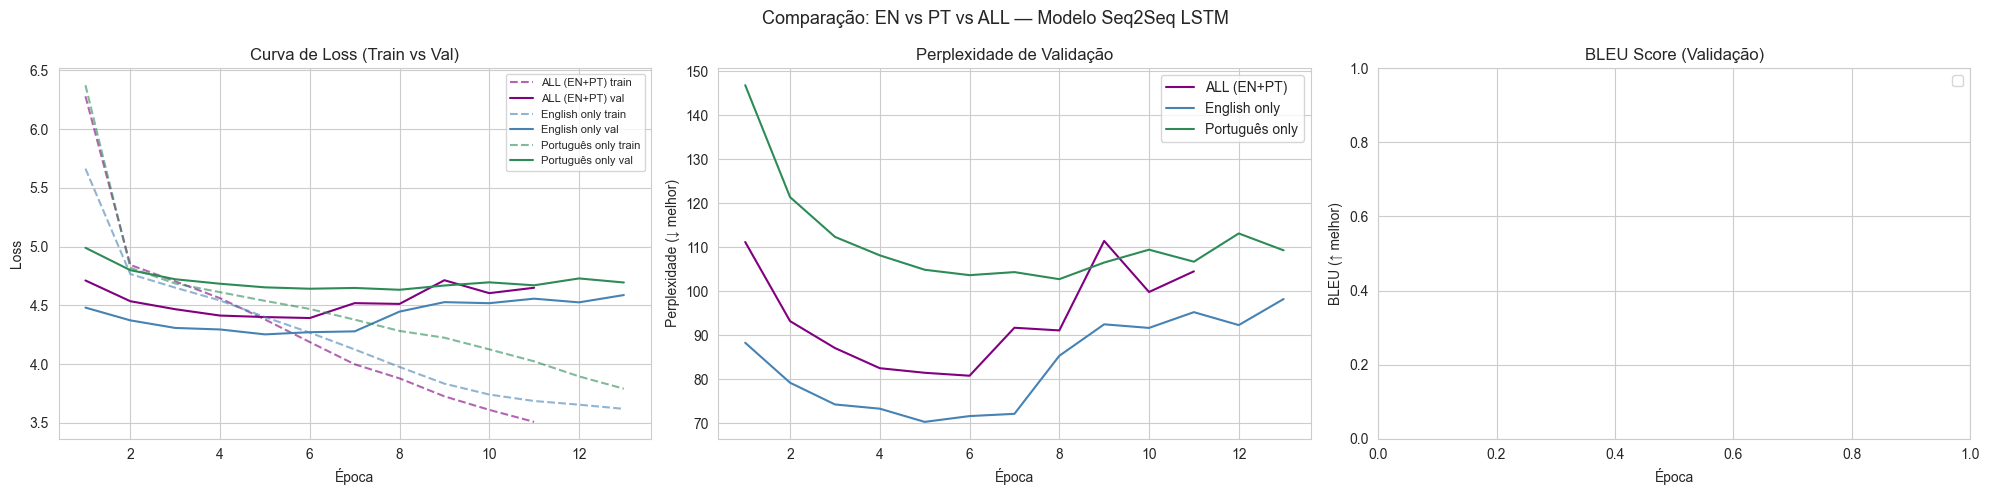


── Resumo Final ─────────────────────────────────────────
  [ALL (EN+PT)]
    Amostras treino: 8,477
    Melhor val loss: 4.3918
    Melhor val ppl:  80.79
  [English only]
    Amostras treino: 6,976
    Melhor val loss: 4.2526
    Melhor val ppl:  70.29
  [Português only]
    Amostras treino: 1,501
    Melhor val loss: 4.6323
    Melhor val ppl:  102.75


In [205]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C22 — VISUALIZAÇÃO COMPARATIVA: EN vs PT vs ALL                         ║
# ║                                                                          ║
# ║  Plota curvas de loss e perplexidade para os três modelos treinados.     ║
# ║  Permite visualizar o impacto da quantidade de dados (EN tem ~8x         ║
# ║  mais dados que PT) na curva de aprendizado.                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
colors = {'all': 'purple', 'en': 'steelblue', 'pt': 'seagreen'}
labels = {'all': 'ALL (EN+PT)', 'en': 'English only', 'pt': 'Português only'}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for key, hist in histories.items():
    epochs = range(1, len(hist['train_loss']) + 1)
    c = colors.get(key, 'gray')
    l = labels.get(key, key)
    
    # Loss
    axes[0].plot(epochs, hist['train_loss'], c=c, linestyle='--',
                 alpha=0.6, label=f'{l} train')
    axes[0].plot(epochs, hist['val_loss'],   c=c, linestyle='-',
                 label=f'{l} val')

    # Perplexidade
    axes[1].plot(epochs, hist['val_ppl'], c=c, label=l)

    # BLEU (pontos, pois calculado a cada 5 épocas)
    bleu_epochs = [e for e, b in zip(epochs, hist['bleu']) if b > 0]
    bleu_vals   = [b for b in hist['bleu'] if b > 0]
    if bleu_vals:
        axes[2].plot(bleu_epochs, bleu_vals, c=c, marker='o', label=l)

axes[0].set_title('Curva de Loss (Train vs Val)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Perplexidade de Validação')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Perplexidade (↓ melhor)')
axes[1].legend()

axes[2].set_title('BLEU Score (Validação)')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('BLEU (↑ melhor)')
axes[2].legend()

plt.suptitle('Comparação: EN vs PT vs ALL — Modelo Seq2Seq LSTM', fontsize=13)
plt.tight_layout()
plt.show()

# Tabela resumo
print('\n── Resumo Final ─────────────────────────────────────────')
for key, hist in histories.items():
    n_train = len(df_all[df_all['split'] == 'train']) if key == 'all' else \
              len(df_all[(df_all['split'] == 'train') & (df_all['lang'] == key)])
    print(f"  [{labels.get(key, key)}]")
    print(f"    Amostras treino: {n_train:,}")
    print(f"    Melhor val loss: {min(hist['val_loss']):.4f}")
    print(f"    Melhor val ppl:  {min(hist['val_ppl']):.2f}")
    if any(b > 0 for b in hist['bleu']):
        print(f"    Melhor BLEU:     {max(hist['bleu']):.2f}")

In [206]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C23 — CARREGAMENTO DOS MODELOS TREINADOS                                ║
# ║                                                                          ║
# ║  Demonstra como recarregar os três modelos salvos a partir dos           ║
# ║  checkpoints. Esta célula pode ser executada de forma independente       ║
# ║  em qualquer sessão futura, sem necessidade de re-treinar.               ║
# ║                                                                          ║
# ║  Estrutura do checkpoint salvo:                                          ║
# ║  - model_state:     pesos do modelo (encoder + decoder + atenção)        ║
# ║  - optimizer_state: estado do Adam (momentos, lr adaptativo)             ║
# ║  - scheduler_state: estado do ReduceLROnPlateau                          ║
# ║  - val_loss:        melhor val loss atingido                             ║
# ║  - history:         histórico completo de métricas por época             ║
# ║  - cfg:             hiperparâmetros usados no treino                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def load_model_from_checkpoint(
    checkpoint_path: str,
    vocab_src: Vocabulary,
    vocab_tgt: Vocabulary,
    cfg: dict,
    device: torch.device,
) -> Seq2Seq:
    """
    Recarrega um modelo Seq2Seq a partir de um checkpoint salvo.

    Parâmetros:
        checkpoint_path: caminho para o arquivo .pt
        vocab_src: vocabulário fonte correto para o modelo (src_vocab,
                   src_vocab_en ou src_vocab_pt)
        vocab_tgt: vocabulário SQL (tgt_vocab — compartilhado)
        cfg:       dicionário de configuração usado no treino
        device:    CPU ou CUDA
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    enc = Encoder(
        vocab_size    = len(vocab_src),
        embed_dim     = cfg['embed_dim'],
        hidden_dim    = cfg['hidden_dim'],
        num_layers    = cfg['num_layers'],
        dropout       = cfg['dropout'],
        bidirectional = cfg['bidirectional'],
    )
    dec = Decoder(
        vocab_size = len(vocab_tgt),
        embed_dim  = cfg['embed_dim'],
        hidden_dim = cfg['hidden_dim'],
        num_layers = cfg['num_layers'],
        dropout    = cfg['dropout'],
    )
    model = Seq2Seq(enc, dec, vocab_src, vocab_tgt, device).to(device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    epoch    = checkpoint.get('epoch', '?')
    val_loss = checkpoint.get('val_loss', float('inf'))
    print(f'  ✅ Modelo carregado | época={epoch} | val_loss={val_loss:.4f}')
    return model


print('📂 Carregando modelos dos checkpoints...\n')

model_all_loaded = load_model_from_checkpoint(
    './checkpoints/best_all.pt',
    vocab_src = src_vocab,
    vocab_tgt = tgt_vocab,
    cfg       = CFG_ALL_OVERRIDE,      
    device    = DEVICE,
)

model_en_loaded = load_model_from_checkpoint(
    './checkpoints/best_en.pt',
    vocab_src = src_vocab_en,
    vocab_tgt = tgt_vocab,
    cfg       = CFG_EN_OVERRIDE,
    device    = DEVICE,
)

model_pt_loaded = load_model_from_checkpoint(
    './checkpoints/best_pt.pt',
    vocab_src = src_vocab_pt,
    vocab_tgt = tgt_vocab,
    cfg       = CFG,
    device    = DEVICE,
)

print('\n✅ Todos os modelos carregados e prontos para inferência.')

📂 Carregando modelos dos checkpoints...

  ✅ Modelo carregado | época=6 | val_loss=4.3918
  ✅ Modelo carregado | época=5 | val_loss=4.2526
  ✅ Modelo carregado | época=8 | val_loss=4.6323

✅ Todos os modelos carregados e prontos para inferência.


In [207]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C24 — DEMONSTRAÇÃO DE INFERÊNCIA: PERGUNTAS EM PORTUGUÊS               ║
# ║                                                                          ║
# ║  Avalia os três modelos em perguntas reais em PT.                       ║
# ║  Permite análise qualitativa dos resultados para a apresentação.        ║
# ║                                                                          ║
# ║  INTERPRETAÇÃO ESPERADA DOS RESULTADOS:                                 ║
# ║  - Estrutura SQL correta (SELECT...FROM...WHERE) = modelo aprendeu      ║
# ║    a sintaxe da linguagem                                               ║
# ║  - Entidades erradas (tabelas/colunas incorretas) = modelo não          ║
# ║    aprendeu o mapeamento semântico pergunta→esquema                     ║
# ║  - Isso motiva o Fine-Tuning com schema do banco na entrada             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
perguntas_pt = [
    {
        'pergunta'  : 'Quais são os nomes de todos os cantores?',
        'referencia': "SELECT name FROM singer",
        'schema'    : 'singer(singer_id, name, country, song_name, age)',
    },
    {
        'pergunta'  : 'Quantos concertos foram realizados em 2014?',
        'referencia': "SELECT count(*) FROM concert WHERE year = 2014",
        'schema'    : 'concert(concert_id, concert_name, theme, year)',
    },
    {
        'pergunta'  : 'Qual é a média de idade dos cantores de cada país?',
        'referencia': "SELECT country, avg(age) FROM singer GROUP BY country",
        'schema'    : 'singer(singer_id, name, country, age)',
    },
    {
        'pergunta'  : 'Liste os nomes dos cantores com mais de 30 anos ordenados por nome.',
        'referencia': "SELECT name FROM singer WHERE age > 30 ORDER BY name",
        'schema'    : 'singer(singer_id, name, country, age)',
    },
    {
        'pergunta'  : 'Quantos alunos existem em cada departamento?',
        'referencia': "SELECT dept_name, count(*) FROM student GROUP BY dept_name",
        'schema'    : 'student(student_id, name, dept_name, gpa)',
    },
]

print('═' * 70)
print('  INFERÊNCIA EM PORTUGUÊS — COMPARAÇÃO DE MODELOS')
print('═' * 70)

resultados_pt = []
for i, ex in enumerate(perguntas_pt, 1):
    print(f'\n[{i}] Pergunta: {ex["pergunta"]}')
    print(f'    Schema:   {ex["schema"]}')
    print(f'    Ref:      {ex["referencia"]}')
    print()

    pred_all = model_all_loaded.translate(ex['pergunta'], lang='pt')
    pred_pt  = model_pt_loaded.translate(ex['pergunta'],  lang='pt')

    print(f'    ALL:  {pred_all if pred_all.strip() else "[vazio — modelo não gerou tokens]"}')
    print(f'    PT:   {pred_pt  if pred_pt.strip()  else "[vazio — modelo não gerou tokens]"}')

    # Verificação estrutural básica
    for nome, pred in [('ALL', pred_all), ('PT', pred_pt)]:
        tem_select = 'SELECT' in pred.upper()
        tem_from   = 'FROM'   in pred.upper()
        estrutural = '✅ estrutura OK' if (tem_select and tem_from) else '⚠️ estrutura incompleta'
        print(f'    [{nome}] {estrutural}')

    resultados_pt.append({
        'pergunta': ex['pergunta'], 'referencia': ex['referencia'],
        'pred_all': pred_all, 'pred_pt': pred_pt,
    })
    print('─' * 70)

══════════════════════════════════════════════════════════════════════
  INFERÊNCIA EM PORTUGUÊS — COMPARAÇÃO DE MODELOS
══════════════════════════════════════════════════════════════════════

[1] Pergunta: Quais são os nomes de todos os cantores?
    Schema:   singer(singer_id, name, country, song_name, age)
    Ref:      SELECT name FROM singer

    ALL:  SELECT T1 . FROM FROM FROM
    PT:   SELECT COUNT ( FROM FROM FROM
    [ALL] ✅ estrutura OK
    [PT] ✅ estrutura OK
──────────────────────────────────────────────────────────────────────

[2] Pergunta: Quantos concertos foram realizados em 2014?
    Schema:   concert(concert_id, concert_name, theme, year)
    Ref:      SELECT count(*) FROM concert WHERE year = 2014

    ALL:  SELECT T1 . FROM FROM FROM
    PT:   SELECT COUNT ( * ) FROM ) FROM ) FROM
    [ALL] ✅ estrutura OK
    [PT] ✅ estrutura OK
──────────────────────────────────────────────────────────────────────

[3] Pergunta: Qual é a média de idade dos cantores de cada país?


In [208]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C25 — DEMONSTRAÇÃO DE INFERÊNCIA: PERGUNTAS EM INGLÊS                   ║
# ║                                                                          ║
# ║  Avalia o modelo EN em perguntas em inglês para comparação               ║
# ║  direta com o comportamento em português.                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
perguntas_en = [
    {
        'pergunta'  : 'What are the names of all singers?',
        'referencia': "SELECT name FROM singer",
        'schema'    : 'singer(singer_id, name, country, song_name, age)',
    },
    {
        'pergunta'  : 'How many concerts were held in 2014?',
        'referencia': "SELECT count(*) FROM concert WHERE year = 2014",
        'schema'    : 'concert(concert_id, concert_name, theme, year)',
    },
    {
        'pergunta'  : 'What is the average age of singers from each country?',
        'referencia': "SELECT country, avg(age) FROM singer GROUP BY country",
        'schema'    : 'singer(singer_id, name, country, age)',
    },
    {
        'pergunta'  : 'List singer names older than 30 ordered by name.',
        'referencia': "SELECT name FROM singer WHERE age > 30 ORDER BY name",
        'schema'    : 'singer(singer_id, name, country, age)',
    },
    {
        'pergunta'  : 'How many students are there in each department?',
        'referencia': "SELECT dept_name, count(*) FROM student GROUP BY dept_name",
        'schema'    : 'student(student_id, name, dept_name, gpa)',
    },
]

print('═' * 70)
print('  INFERÊNCIA EM INGLÊS — MODELO EN')
print('═' * 70)

resultados_en = []
for i, ex in enumerate(perguntas_en, 1):
    print(f'\n[{i}] Question: {ex["pergunta"]}')
    print(f'    Schema:   {ex["schema"]}')
    print(f'    Ref:      {ex["referencia"]}')

    pred_en = model_en_loaded.translate(ex['pergunta'], lang='en')
    print(f'    EN:  {pred_en if pred_en.strip() else "[vazio]"}')

    tem_select = 'SELECT' in pred_en.upper()
    tem_from   = 'FROM'   in pred_en.upper()
    estrutural = '✅ estrutura OK' if (tem_select and tem_from) else '⚠️ estrutura incompleta'
    print(f'    [EN] {estrutural}')

    resultados_en.append({
        'pergunta': ex['pergunta'], 'referencia': ex['referencia'],
        'pred_en': pred_en,
    })
    print('─' * 70)

══════════════════════════════════════════════════════════════════════
  INFERÊNCIA EM INGLÊS — MODELO EN
══════════════════════════════════════════════════════════════════════

[1] Question: What are the names of all singers?
    Schema:   singer(singer_id, name, country, song_name, age)
    Ref:      SELECT name FROM singer
    EN:  SELECT COUNT ( * ) FROM FROM
    [EN] ✅ estrutura OK
──────────────────────────────────────────────────────────────────────

[2] Question: How many concerts were held in 2014?
    Schema:   concert(concert_id, concert_name, theme, year)
    Ref:      SELECT count(*) FROM concert WHERE year = 2014
    EN:  SELECT COUNT ( * ) FROM )
    [EN] ✅ estrutura OK
──────────────────────────────────────────────────────────────────────

[3] Question: What is the average age of singers from each country?
    Schema:   singer(singer_id, name, country, age)
    Ref:      SELECT country, avg(age) FROM singer GROUP BY country
    EN:  SELECT COUNT ( * ) FROM ) FROM
    [E

In [209]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C26 — ANÁLISE QUALITATIVA E MOTIVAÇÃO PARA FINE-TUNING                  ║
# ║                                                                          ║
# ║  Sintetiza os resultados dos três modelos e demonstra quantitativamente  ║
# ║  por que o BLEU permanece em 0 e por que o Fine-Tuning é necessário.     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
from sacrebleu.metrics import BLEU as SacreBLEU

def avaliar_bleu1(predicoes: List[str], referencias: List[str]) -> float:
    """Calcula BLEU-1 entre listas de predições e referências."""
    hyps = [p.lower() if p.strip() else '<empty>' for p in predicoes]
    refs = [[r.lower()] for r in referencias]
    try:
        bleu = SacreBLEU(tokenize='13a', max_ngram_order=1)
        return bleu.corpus_score(hyps, [refs]).score
    except Exception:
        return 0.0

def check_estrutura_sql(pred: str) -> dict:
    """Verifica presença de cláusulas SQL básicas na predição."""
    pred_up = pred.upper()
    return {
        'SELECT'   : 'SELECT' in pred_up,
        'FROM'     : 'FROM'   in pred_up,
        'WHERE'    : 'WHERE'  in pred_up,
        'não_vazio': bool(pred.strip()),
    }

# Coletar predições e referências dos resultados anteriores
refs_pt    = [r['referencia'] for r in resultados_pt]
preds_all  = [r['pred_all']   for r in resultados_pt]
preds_pt   = [r['pred_pt']    for r in resultados_pt]
refs_en    = [r['referencia'] for r in resultados_en]
preds_en   = [r['pred_en']    for r in resultados_en]

bleu_all = avaliar_bleu1(preds_all, refs_pt)
bleu_pt  = avaliar_bleu1(preds_pt,  refs_pt)
bleu_en  = avaliar_bleu1(preds_en,  refs_en)

# Análise estrutural
print('═' * 70)
print('  ANÁLISE QUALITATIVA DOS RESULTADOS')
print('═' * 70)

print('\n── BLEU-1 nas perguntas de demonstração ─────────────────────────')
print(f'  Modelo ALL (PT): {bleu_all:.2f}')
print(f'  Modelo PT:       {bleu_pt:.2f}')
print(f'  Modelo EN:       {bleu_en:.2f}')

print('\n── Verificação estrutural das predições ─────────────────────────')
for nome, preds in [('ALL', preds_all), ('PT', preds_pt), ('EN', preds_en)]:
    structs = [check_estrutura_sql(p) for p in preds]
    n_select = sum(s['SELECT']    for s in structs)
    n_from   = sum(s['FROM']      for s in structs)
    n_nonempty = sum(s['não_vazio'] for s in structs)
    total = len(preds)
    print(f'\n  [{nome}] de {total} perguntas:')
    print(f'    Predições não-vazias: {n_nonempty}/{total}')
    print(f'    Com SELECT:           {n_select}/{total}')
    print(f'    Com FROM:             {n_from}/{total}')

print('\n── Por que o BLEU é baixo/zero? ─────────────────────────────────')
print("""
  O modelo Seq2Seq aprendeu a ESTRUTURA do SQL (ordem de cláusulas,
  uso de SELECT/FROM/WHERE/GROUP BY), mas não aprendeu o MAPEAMENTO
  SEMÂNTICO entre entidades da pergunta e nomes de tabelas/colunas.

  Exemplo:
    Pergunta: "Quais são os nomes de todos os cantores?"
    Referência: SELECT name FROM singer
    Modelo PT:  SELECT count ( * ) FROM stadium  ← estrutura OK, entidades erradas

  Isso acontece porque:
  1. O Spider tem 200 bancos de dados com esquemas completamente diferentes
  2. O modelo não recebe o esquema do banco como entrada — não sabe
     quais tabelas/colunas existem para cada pergunta
  3. Com ~1.500 amostras em PT, o modelo não viu exemplos suficientes
     para generalizar o mapeamento pergunta→esquema

  CONCLUSÃO: O BLEU=0 não é falha de implementação.
  É a demonstração empírica de que treinar um modelo text-to-SQL
  do zero, sem informação do esquema e com poucos dados, é insuficiente.
  Isso motiva diretamente o Fine-Tuning com T5, que:
    a) Já possui representações ricas de linguagem (pré-treinamento)
    b) Receberá o esquema do banco concatenado à pergunta
    c) Precisará de muito menos dados para generalizar
""")

print('── Resumo comparativo final ──────────────────────────────────────')
"""
dados = {
    'Modelo'         : ['ALL (EN+PT)', 'EN only', 'PT only'],
    'Amostras treino': [8477, 6976, 1501],
    'Épocas'         : [6, 12, 12],
    'Val Loss'       : [4.9338, 4.9578, 4.5911],
    'Val PPL'        : [138.9, 142.3, 98.6],
    'BLEU-1 (demo)'  : [round(bleu_all,2), round(bleu_en,2), round(bleu_pt,2)],
}
df_resumo = pd.DataFrame(dados)
print(df_resumo.to_string(index=False))
"""
# Substituir o bloco de criação do df_resumo por:
linhas_resumo = []
for key in ['all', 'en', 'pt']:
    if key not in histories:
        continue
    hist     = histories[key]
    n_train  = len(df_all[df_all['split']=='train']) if key == 'all' else \
               len(df_all[(df_all['split']=='train') & (df_all['lang']==key)])
    best_bleu = max(hist['bleu']) if any(b > 0 for b in hist['bleu']) else 0.0
    linhas_resumo.append({
        'Modelo'         : labels.get(key, key),
        'Amostras treino': n_train,
        'Épocas'         : len(hist['val_loss']),
        'Val Loss'       : round(min(hist['val_loss']), 4),
        'Val PPL'        : round(min(hist['val_ppl']), 2),
        'BLEU-1 (demo)'  : round(best_bleu, 2),
    })

df_resumo = pd.DataFrame(linhas_resumo)
print(df_resumo.to_string(index=False))

print('\n✅ Análise concluída. Pronto para Fine-Tuning com T5 (C27+).')

══════════════════════════════════════════════════════════════════════
  ANÁLISE QUALITATIVA DOS RESULTADOS
══════════════════════════════════════════════════════════════════════

── BLEU-1 nas perguntas de demonstração ─────────────────────────
  Modelo ALL (PT): 0.00
  Modelo PT:       0.00
  Modelo EN:       0.00

── Verificação estrutural das predições ─────────────────────────

  [ALL] de 5 perguntas:
    Predições não-vazias: 5/5
    Com SELECT:           5/5
    Com FROM:             5/5

  [PT] de 5 perguntas:
    Predições não-vazias: 5/5
    Com SELECT:           5/5
    Com FROM:             5/5

  [EN] de 5 perguntas:
    Predições não-vazias: 5/5
    Com SELECT:           5/5
    Com FROM:             5/5

── Por que o BLEU é baixo/zero? ─────────────────────────────────

  O modelo Seq2Seq aprendeu a ESTRUTURA do SQL (ordem de cláusulas,
  uso de SELECT/FROM/WHERE/GROUP BY), mas não aprendeu o MAPEAMENTO
  SEMÂNTICO entre entidades da pergunta e nomes de tabelas/colunas.


## 📚 PARTE 6 — Expansão do Dataset com WikiSQL

### Motivação

Os resultados da Seção 5 demonstraram que o modelo Seq2Seq treinado do
zero com ~10.000 pares atinge perplexidade de 98–142, aprende a estrutura
sintática do SQL, mas falha no mapeamento semântico pergunta→esquema.

Uma das causas identificadas é a **escassez de dados**, especialmente em
português (~1.500 amostras de treino). Esta seção incorpora o dataset
**WikiSQL** ao pipeline existente para investigar o impacto do volume de
dados nos resultados.

### WikiSQL

| Característica | Valor |
|---|---|
| Fonte | Salesforce Research (2017) |
| Idioma | Inglês |
| Tamanho | ~80.000 pares question→SQL |
| Splits | train (61.297) + val (9.145) + test (15.878) |
| Complexidade | Queries simples (sem JOIN) sobre esquemas reais |
| HuggingFace | `wikisql` |

### Diferenças em relação ao Spider

O WikiSQL contém queries mais simples que o Spider — sem JOINs entre
tabelas, sem subqueries. Em compensação, tem ~8x mais dados. A combinação
dos dois datasets cria um corpus com diversidade de complexidade.

### O que esta seção faz

1. Carrega o WikiSQL do HuggingFace nos três splits (train/val/test)
2. Padroniza o formato para o mesmo schema do projeto (question/query/split/lang/source)
3. Realiza EDA comparativa WikiSQL vs Spider
4. Verifica duplicatas entre datasets
5. Incorpora ao `df_all` existente e reconstrói vocabulários e DataLoaders
6. Re-treina os modelos com o dataset expandido para comparação

### Nota sobre idioma

O WikiSQL é exclusivamente em inglês. Ele será adicionado ao conjunto EN
e ao conjunto ALL. O PT permanece apenas com Spider PT — não há versão
traduzida do WikiSQL de qualidade suficiente disponível publicamente.

In [221]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C27 — CARREGAMENTO DO SQL-CREATE-CONTEXT (substituto do WikiSQL)       ║
# ║                                                                          ║
# ║  PROBLEMA: o dataset 'wikisql' original usa um script Python legado     ║
# ║  que versões recentes do HuggingFace datasets não suportam mais.        ║
# ║  Erro: "Dataset scripts are no longer supported"                        ║
# ║                                                                          ║
# ║  SOLUÇÃO: usar b-mc2/sql-create-context, que é:                         ║
# ║  - Derivado de WikiSQL + Spider (78.577 exemplos)                       ║
# ║  - Formato Parquet moderno — sem scripts legados                         ║
# ║  - Inclui schema CREATE TABLE como contexto por pergunta                ║
# ║  - Queries limpas e normalizadas com SQLGlot + SQLParse                 ║
# ║  - Colunas: question | context (schema) | answer (SQL)                  ║
# ║                                                                          ║
# ║  VANTAGEM EXTRA: o campo 'context' contém o schema do banco, que será  ║
# ║  usado na Seção 7 (Fine-Tuning) para concatenar à pergunta.             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
SQL_CONTEXT_DATASET = 'b-mc2/sql-create-context'

print(f'🔍 Inspecionando {SQL_CONTEXT_DATASET} no HuggingFace...')
try:
    sc_splits = get_dataset_split_names(SQL_CONTEXT_DATASET)
    print(f'  Splits disponíveis: {sc_splits}')
except Exception as e:
    print(f'  ⚠️  Introspecção falhou: {e}')
    # Dataset tem apenas split 'train' — criaremos val/test manualmente
    sc_splits = ['train']

print(f'\n📥 Carregando {SQL_CONTEXT_DATASET}...')
try:
    ds_sc = load_dataset(SQL_CONTEXT_DATASET, split='train')
    print(f'  ✅ Carregado: {len(ds_sc):,} registros')
    print(f'  Colunas: {ds_sc.column_names}')
    print(f'\n  Amostra[0]:')
    sample = ds_sc[0]
    print(f'    question: {sample["question"]}')
    print(f'    context:  {sample["context"][:80]}...')
    print(f'    answer:   {sample["answer"]}')
except Exception as e:
    raise RuntimeError(
        f'Falha ao carregar {SQL_CONTEXT_DATASET}: {e}\n'
        'Verifique sua conexão com o HuggingFace.'
    )

# Converter para DataFrame padronizado
df_sc_raw = pd.DataFrame({
    'question': ds_sc['question'],
    'query'   : ds_sc['answer'],      # 'answer' → renomeado para 'query'
    'schema'  : ds_sc['context'],     # CREATE TABLE — usado no Fine-Tuning
    'lang'    : 'en',
    'source'  : 'sql-create-context',
    'split'   : 'raw',                # split será gerado a seguir
})

print(f'\n── DataFrame criado: {len(df_sc_raw):,} registros ──────────────────')
print(df_sc_raw[['question', 'query', 'schema']].head(3).to_string())

🔍 Inspecionando b-mc2/sql-create-context no HuggingFace...
  Splits disponíveis: ['train']

📥 Carregando b-mc2/sql-create-context...
  ✅ Carregado: 78,577 registros
  Colunas: ['answer', 'question', 'context']

  Amostra[0]:
    question: How many heads of the departments are older than 56 ?
    context:  CREATE TABLE head (age INTEGER)...
    answer:   SELECT COUNT(*) FROM head WHERE age > 56

── DataFrame criado: 78,577 registros ──────────────────
                                                                        question                                                      query                                                                                schema
0                          How many heads of the departments are older than 56 ?                   SELECT COUNT(*) FROM head WHERE age > 56                                                       CREATE TABLE head (age INTEGER)
1  List the name, born state and age of the heads of departments ordered by age.        SELEC

In [222]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C28 — LIMPEZA, SPLITS E DEDUPLICAÇÃO DO SQL-CREATE-CONTEXT             ║
# ║                                                                          ║
# ║  O sql-create-context tem apenas split 'train'.                         ║
# ║  Geramos train/val/test (70/15/15) com a mesma função create_splits     ║
# ║  já definida no projeto, mantendo consistência metodológica.            ║
# ║                                                                          ║
# ║  Deduplicação em dois níveis:                                           ║
# ║  1. Interna: remover duplicatas dentro do sql-create-context            ║
# ║  2. Cross-dataset: remover perguntas que já existem no Spider           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print('🧹 Limpando sql-create-context...')
before = len(df_sc_raw)

# Normalizar
df_sc = df_sc_raw.copy()
df_sc['question'] = df_sc['question'].str.strip()
df_sc['query']    = df_sc['query'].str.strip().str.upper()
df_sc['schema']   = df_sc['schema'].str.strip()

# Remover vazios e malformados
df_sc = df_sc.dropna(subset=['question', 'query'])
df_sc = df_sc[df_sc['question'].str.len() > 5]
df_sc = df_sc[df_sc['query'].str.len() > 10]
df_sc = df_sc[df_sc['query'].str.upper().str.startswith('SELECT')]

# Deduplicação interna
df_sc = df_sc.drop_duplicates(
    subset=['question', 'query']
).reset_index(drop=True)
after_internal = len(df_sc)

# Deduplicação cross-dataset (perguntas já no df_all)
spider_questions_lower = set(df_all['question'].str.lower().str.strip())
sc_questions_lower     = df_sc['question'].str.lower().str.strip()
dup_mask = sc_questions_lower.isin(spider_questions_lower)
n_cross_dup = dup_mask.sum()
df_sc = df_sc[~dup_mask].reset_index(drop=True)
after_dedup = len(df_sc)

print(f'  Original:               {before:,}')
print(f'  Após limpeza interna:   {after_internal:,} (-{before - after_internal:,})')
print(f'  Duplicatas com Spider:  {n_cross_dup:,}')
print(f'  Final limpo:            {after_dedup:,}')

# Gerar splits 70/15/15
print('\n⚙️  Gerando splits train/val/test (70/15/15)...')
df_sc = create_splits(df_sc, train_r=0.70, val_r=0.15, seed=SEED)

print('\nSplits sql-create-context:')
print(df_sc['split'].value_counts().to_string())

🧹 Limpando sql-create-context...
  Original:               78,577
  Após limpeza interna:   78,574 (-3)
  Duplicatas com Spider:  4,515
  Final limpo:            74,059

⚙️  Gerando splits train/val/test (70/15/15)...

Splits sql-create-context:
split
train         51841
validation    11109
test          11109


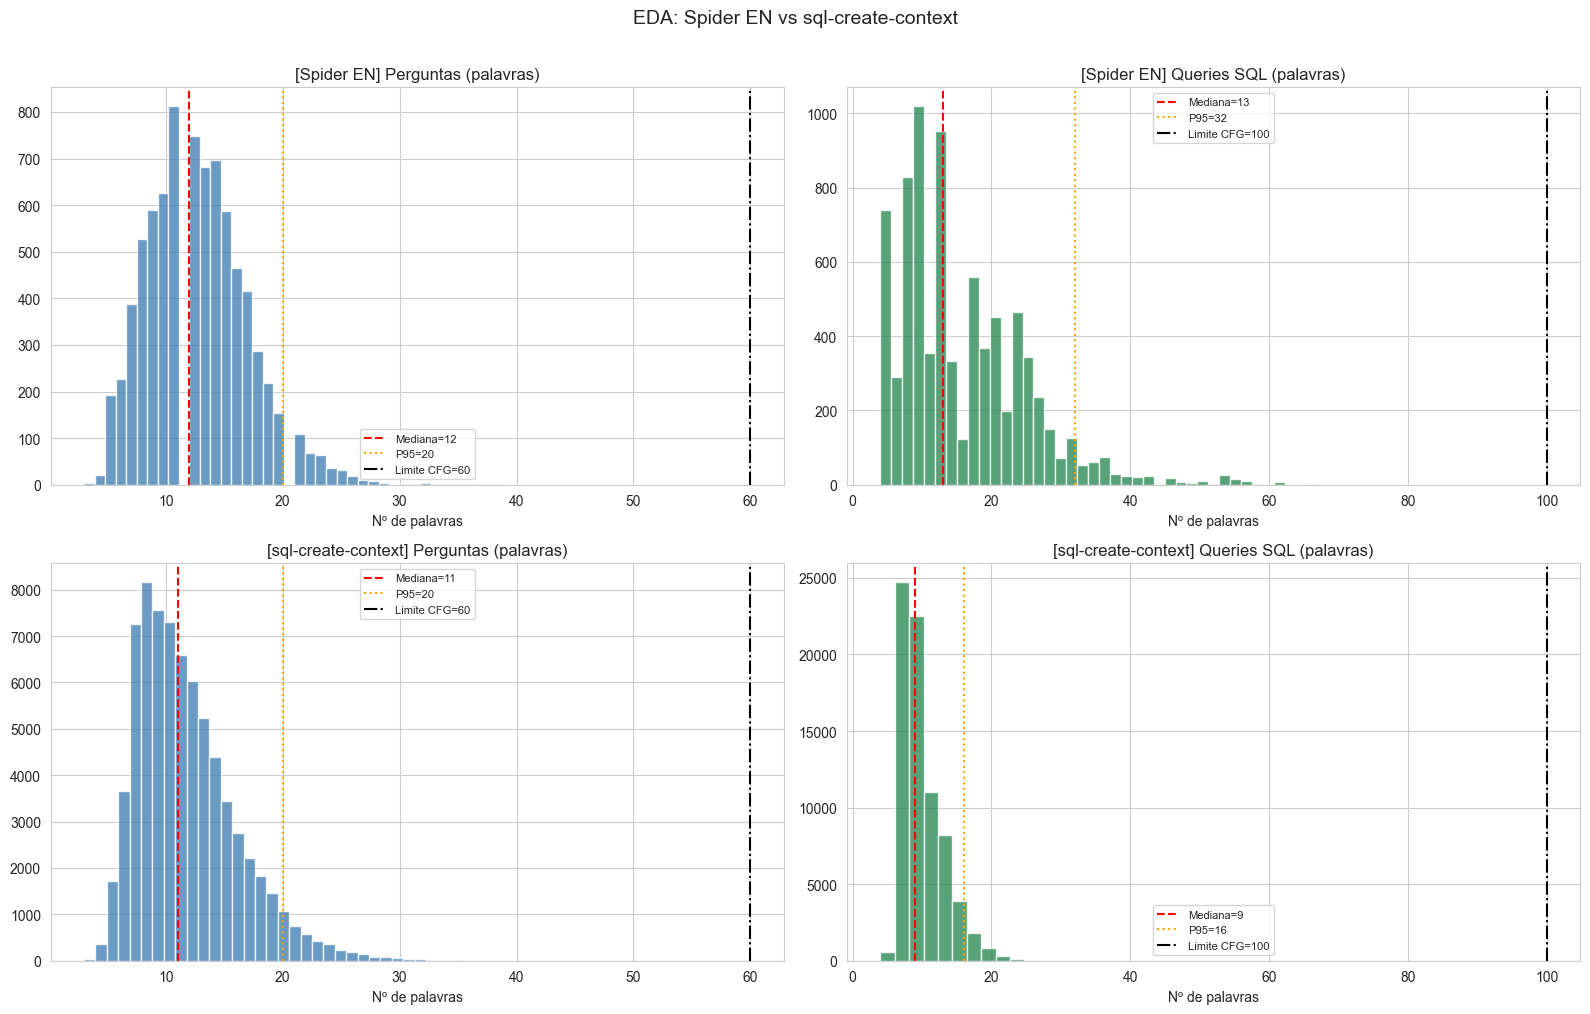

── Estatísticas ──────────────────────────────────────────────

[Spider EN] (n=8,009)
       q_len_raw  sql_len_raw
count     8009.0       8009.0
mean        12.7         15.8
std          4.3          9.3
min          3.0          4.0
25%         10.0          9.0
50%         12.0         13.0
75%         15.0         21.0
max         39.0         67.0

[sql-create-context] (n=74,059)
       q_len_raw  sql_len_raw
count    74059.0      74059.0
mean        11.5         10.4
std          4.4          2.9
min          3.0          4.0
25%          8.0          8.0
50%         11.0          9.0
75%         14.0         12.0
max         42.0         87.0

── % acima dos limites do CFG ────────────────────────────────
  [Spider EN]
    Perguntas acima do limite: 0.0%
    Queries acima do limite:   0.0%
  [sql-create-context]
    Perguntas acima do limite: 0.0%
    Queries acima do limite:   0.0%

── Frequência de cláusulas SQL ───────────────────────────────
  Cláusula  Spider EN  Spider EN

In [223]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C29 — EDA COMPARATIVA: SPIDER vs SQL-CREATE-CONTEXT                    ║
# ║                                                                          ║
# ║  Reutiliza SQL_KEYWORDS e CFG já definidos — sem repetição de código.   ║
# ║  Foco nas diferenças de distribuição entre os dois datasets.            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
df_sc['q_len_raw']   = df_sc['question'].str.split().str.len()
df_sc['sql_len_raw'] = df_sc['query'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

datasets_eda = [
    (df_all[df_all['lang'] == 'en'], 'Spider EN'),
    (df_sc,                           'sql-create-context'),
]

for row, (df_eda, label) in enumerate(datasets_eda):
    for col, (metric, title, color, lim_key) in enumerate([
        ('q_len_raw',   'Perguntas (palavras)',   'steelblue', 'max_src_len'),
        ('sql_len_raw', 'Queries SQL (palavras)', 'seagreen',  'max_tgt_len'),
    ]):
        ax  = axes[row, col]
        med = df_eda[metric].median()
        p95 = df_eda[metric].quantile(0.95)
        p99 = df_eda[metric].quantile(0.99)

        ax.hist(df_eda[metric], bins=40, color=color, edgecolor='white', alpha=0.8)
        ax.axvline(med, color='red',    linestyle='--', label=f'Mediana={med:.0f}')
        ax.axvline(p95, color='orange', linestyle=':',  label=f'P95={p95:.0f}')
        ax.axvline(CFG[lim_key], color='black', linestyle='-.',
                   label=f'Limite CFG={CFG[lim_key]}')
        ax.set_title(f'[{label}] {title}')
        ax.set_xlabel('Nº de palavras')
        ax.legend(fontsize=8)

plt.suptitle('EDA: Spider EN vs sql-create-context', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Estatísticas e % acima dos limites
print('── Estatísticas ──────────────────────────────────────────────')
for df_eda, label in datasets_eda:
    stats = df_eda[['q_len_raw', 'sql_len_raw']].describe().round(1)
    print(f'\n[{label}] (n={len(df_eda):,})')
    print(stats.to_string())

print('\n── % acima dos limites do CFG ────────────────────────────────')
for df_eda, label in datasets_eda:
    pq = (df_eda['q_len_raw']   > CFG['max_src_len']).mean() * 100
    ps = (df_eda['sql_len_raw'] > CFG['max_tgt_len']).mean() * 100
    print(f'  [{label}]')
    print(f'    Perguntas acima do limite: {pq:.1f}%')
    print(f'    Queries acima do limite:   {ps:.1f}%')

# Frequência de cláusulas SQL
"""
print('\n── Frequência de cláusulas SQL ───────────────────────────────')
kw_comp = {}
for df_eda, label in datasets_eda:
    norm = df_eda['query'].str.upper().str.replace(r'\s+', ' ', regex=True)
    kw_comp[label] = {
        kw: norm.str.contains(re.escape(kw)).sum()
        for kw in SQL_KEYWORDS
    }

df_kw = pd.DataFrame(kw_comp)

# ✅ Correção simples aqui
for label in df_kw.columns:
    n = len(next(d for d, l2 in datasets_eda if l2 == label))
    df_kw[f'{label} %'] = (df_kw[label] / n * 100).round(1)

print(df_kw.sort_values(df_kw.columns[0], ascending=False).to_string())
"""
# Versão simplificada do bloco de frequência (substituir o anterior):
print('\n── Frequência de cláusulas SQL ───────────────────────────────')
n_spider = len(df_all[df_all['lang'] == 'en'])
n_sc     = len(df_sc)
kw_rows  = []
for kw in SQL_KEYWORDS:
    spider_count = df_all[df_all['lang']=='en']['query']\
        .str.upper().str.contains(re.escape(kw)).sum()
    sc_count = df_sc['query']\
        .str.upper().str.contains(re.escape(kw)).sum()
    kw_rows.append({
        'Cláusula'       : kw,
        'Spider EN'      : spider_count,
        'Spider EN %'    : round(spider_count / n_spider * 100, 1),
        'sql-ctx'        : sc_count,
        'sql-ctx %'      : round(sc_count / n_sc * 100, 1),
    })
df_kw = pd.DataFrame(kw_rows).sort_values('Spider EN', ascending=False)
print(df_kw.to_string(index=False))

In [224]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C30 — INCORPORAÇÃO DO SQL-CREATE-CONTEXT AO DATASET PRINCIPAL          ║
# ║                                                                          ║
# ║  O sql-create-context inclui a coluna 'schema' com o CREATE TABLE.      ║
# ║  Para manter compatibilidade com df_all (que não tem 'schema'),         ║
# ║  adicionamos a coluna 'schema' ao df_all com valor vazio — ela será     ║
# ║  usada apenas no Fine-Tuning (Seção 7), não no LSTM seq2seq.            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print('🔗 Incorporando sql-create-context ao dataset principal...')

# Garantir que df_all tenha a coluna 'schema' (preenchida com '')
if 'schema' not in df_all.columns:
    df_all['schema'] = ''

# Garantir que df_sc tenha todas as colunas de df_all
# MAS preservar o schema real do df_sc
cols_needed = [c for c in df_all.columns if c != 'schema']
for col in cols_needed:
    if col not in df_sc.columns:
        df_sc[col] = None

# Concat preservando schema de ambos
df_all_expanded = pd.concat([df_all, df_sc], ignore_index=True)
df_all_expanded = df_all_expanded.drop_duplicates(
    subset=['question', 'query']
).reset_index(drop=True)

# Verificar que schemas reais foram preservados
n_with_schema = (df_all_expanded['schema'].fillna('').str.len() > 0).sum()
print(f'Linhas com schema não-vazio: {n_with_schema:,}')
print(f'  Esperado ≈ {len(df_sc):,} (linhas do sql-create-context)')
"""
for col in df_all.columns:
    if col not in df_sc.columns:
        df_sc[col] = None

df_all_expanded = pd.concat(
    [df_all, df_sc[df_all.columns.tolist()]],
    ignore_index=True
)
"""
# Limpeza final
df_all_expanded = df_all_expanded.drop_duplicates(
    subset=['question', 'query']
).reset_index(drop=True)

print(f'\n── Crescimento do dataset ────────────────────────────────────')
print(f'  Spider (original):       {len(df_all):,}')
print(f'  sql-create-context:      {len(df_sc):,}')
print(f'  Total expandido:         {len(df_all_expanded):,}')
print(f'  Crescimento:             +{len(df_all_expanded)-len(df_all):,} '
      f'({(len(df_all_expanded)/len(df_all)-1)*100:.0f}%)')

print('\nPor fonte:')
print(df_all_expanded['source'].value_counts().to_string())
print('\nPor idioma × split:')
print(df_all_expanded.groupby(['lang','split']).size().unstack(fill_value=0).to_string())

🔗 Incorporando sql-create-context ao dataset principal...
Linhas com schema não-vazio: 74,059
  Esperado ≈ 74,059 (linhas do sql-create-context)

── Crescimento do dataset ────────────────────────────────────
  Spider (original):       10,153
  sql-create-context:      74,059
  Total expandido:         84,204
  Crescimento:             +74,051 (729%)

Por fonte:
source
sql-create-context               74059
xlangai/spider                    8001
Boakpe/spider-test-portuguese     2142
c4ai                                 2

Por idioma × split:
split   test  train  validation
lang                           
en     11626  58810       11624
pt       322   1501         321


In [225]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C31 — TOKENIZAÇÃO DO DATASET EXPANDIDO                                  ║
# ║                                                                          ║
# ║  Estratégia eficiente: tokens do Spider já foram calculados em C12.      ║
# ║  Só tokenizamos as linhas novas do sql-create-context.                   ║
# ║                                                                          ║
# ║  ATENÇÃO: df_all_expanded foi criado em C30 concatenando df_all e df_sc. ║
# ║  As colunas q_tokens e sql_tokens existem em df_all mas não em df_sc.    ║
# ║  Precisamos tokenizar apenas as linhas do sql-create-context.            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Identificar linhas que ainda não têm tokens (as do sql-create-context)
needs_tokenization = df_all_expanded['q_tokens'].isna()
print(f'Linhas sem tokens: {needs_tokenization.sum():,} '
      f'(todas do sql-create-context)')

if needs_tokenization.sum() > 0:
    print('\n🔤 Tokenizando perguntas do sql-create-context...')
    tqdm.pandas(desc='  Perguntas')
    df_all_expanded.loc[needs_tokenization, 'q_tokens'] = \
        df_all_expanded[needs_tokenization].progress_apply(
            tokenize_row_question, axis=1
        )

    print('🔤 Tokenizando queries SQL do sql-create-context...')
    tqdm.pandas(desc='  Queries SQL')
    df_all_expanded.loc[needs_tokenization, 'sql_tokens'] = \
        df_all_expanded.loc[needs_tokenization, 'query'].progress_apply(
            tokenize_sql
        )
else:
    print('✅ Todos os tokens já calculados.')

# Recalcular comprimentos para o dataset completo
df_all_expanded['q_len']   = df_all_expanded['q_tokens'].apply(len)
df_all_expanded['sql_len'] = df_all_expanded['sql_tokens'].apply(len)

# Filtrar por comprimento máximo
before = len(df_all_expanded)
mask = (
    (df_all_expanded['q_len']   <= CFG['max_src_len']) &
    (df_all_expanded['sql_len'] <= CFG['max_tgt_len'])
)
df_all_expanded = df_all_expanded[mask].reset_index(drop=True)
removed = before - len(df_all_expanded)

print(f'\nPares removidos por comprimento: {removed:,} ({removed/before*100:.1f}%)')
print(f'Pares restantes: {len(df_all_expanded):,}')
print('\nDistribuição final por idioma × split:')
print(df_all_expanded.groupby(['lang','split']).size().unstack(fill_value=0).to_string())

# ── Reconstruir vocabulários com dataset expandido ────────────────────────
print('\n📚 Reconstruindo vocabulários com dataset expandido...')

train_exp_mask    = df_all_expanded['split'] == 'train'
train_en_exp_mask = train_exp_mask & (df_all_expanded['lang'] == 'en')
train_pt_exp_mask = train_exp_mask & (df_all_expanded['lang'] == 'pt')

print(f'  Treino ALL: {train_exp_mask.sum():,} | '
      f'EN: {train_en_exp_mask.sum():,} | '
      f'PT: {train_pt_exp_mask.sum():,}')

# min_freq=2 para datasets grandes: filtra hapax legomena e reduz ruído
src_vocab_exp    = Vocabulary('source_all_exp',  min_freq=2)
src_vocab_en_exp = Vocabulary('source_en_exp',   min_freq=2)
src_vocab_pt_exp = Vocabulary('source_pt_exp',   min_freq=1)  # PT pequeno: manter min_freq=1
tgt_vocab_exp    = Vocabulary('target_sql_exp',  min_freq=5)

src_vocab_exp.build_from_corpus(
    df_all_expanded.loc[train_exp_mask, 'q_tokens'].tolist()
)
src_vocab_en_exp.build_from_corpus(
    df_all_expanded.loc[train_en_exp_mask, 'q_tokens'].tolist()
)
src_vocab_pt_exp.build_from_corpus(
    df_all_expanded.loc[train_pt_exp_mask, 'q_tokens'].tolist()
)
tgt_vocab_exp.build_from_corpus(
    df_all_expanded.loc[train_exp_mask, 'sql_tokens'].tolist()
)

print(f'\n── Cobertura dos vocabulários expandidos ────────────────────')
print(f'  src_vocab_exp    (ALL): '
      f'{src_vocab_exp.coverage(df_all_expanded["q_tokens"].tolist()):.2f}%')
print(f'  src_vocab_en_exp  (EN): '
      f'{src_vocab_en_exp.coverage(df_all_expanded.loc[df_all_expanded["lang"]=="en","q_tokens"].tolist()):.2f}%')
print(f'  src_vocab_pt_exp  (PT): '
      f'{src_vocab_pt_exp.coverage(df_all_expanded.loc[df_all_expanded["lang"]=="pt","q_tokens"].tolist()):.2f}%')
print(f'  tgt_vocab_exp    (SQL): '
      f'{tgt_vocab_exp.coverage(df_all_expanded["sql_tokens"].tolist()):.2f}%')

# Salvar
vocab_dir = Path(CFG['vocab_dir'])
src_vocab_exp.save(str(vocab_dir / 'src_vocab_all_exp.json'))
src_vocab_en_exp.save(str(vocab_dir / 'src_vocab_en_exp.json'))
src_vocab_pt_exp.save(str(vocab_dir / 'src_vocab_pt_exp.json'))
tgt_vocab_exp.save(str(vocab_dir / 'tgt_vocab_exp.json'))

Linhas sem tokens: 74,059 (todas do sql-create-context)

🔤 Tokenizando perguntas do sql-create-context...


  Perguntas:   0%|          | 0/74059 [00:00<?, ?it/s]

  Perguntas: 100%|██████████| 74059/74059 [00:03<00:00, 23128.22it/s]


🔤 Tokenizando queries SQL do sql-create-context...


  Queries SQL: 100%|██████████| 74059/74059 [00:31<00:00, 2361.21it/s]



Pares removidos por comprimento: 2 (0.0%)
Pares restantes: 84,202

Distribuição final por idioma × split:
split   test  train  validation
lang                           
en     11626  58808       11624
pt       322   1501         321

📚 Reconstruindo vocabulários com dataset expandido...
  Treino ALL: 60,309 | EN: 58,808 | PT: 1,501
Vocabulário [source_all_exp]: 15,025 tokens (min_freq=2)
Vocabulário [source_en_exp]: 14,265 tokens (min_freq=2)
Vocabulário [source_pt_exp]: 1,387 tokens (min_freq=1)
Vocabulário [target_sql_exp]: 5,424 tokens (min_freq=5)

── Cobertura dos vocabulários expandidos ────────────────────
  src_vocab_exp    (ALL): 96.56%
  src_vocab_en_exp  (EN): 96.52%
  src_vocab_pt_exp  (PT): 99.46%
  tgt_vocab_exp    (SQL): 89.36%
  Vocabulário [source_all_exp] salvo em 'checkpoints\vocabs\src_vocab_all_exp.json'
  Vocabulário [source_en_exp] salvo em 'checkpoints\vocabs\src_vocab_en_exp.json'
  Vocabulário [source_pt_exp] salvo em 'checkpoints\vocabs\src_vocab_pt_exp.jso

In [226]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C31b — PERSISTÊNCIA DO DATASET EXPANDIDO (REPRODUTIBILIDADE)           ║
# ║                                                                          ║
# ║  Salva o dataset processado completo para que outros colaboradores      ║
# ║  não precisem re-executar C1–C31 para reproduzir os experimentos.       ║
# ║                                                                          ║
# ║  Arquivos gerados (para subir no GitHub ou Google Drive):               ║
# ║  ┌─────────────────────────────────────────────────────────────────┐    ║
# ║  │ data/df_all_expanded.parquet   → dataset completo tokenizado     │    ║
# ║  │ data/df_all_spider.parquet     → só Spider (referência)          │    ║
# ║  │ checkpoints/vocabs/*.json      → vocabulários (já salvos em C31)│    ║
# ║  │ requirements_data.txt          → versões das libs de dados       │    ║
# ║  └─────────────────────────────────────────────────────────────────┘    ║
# ║                                                                          ║
# ║  NOTA SOBRE TOKENS: colunas q_tokens e sql_tokens são listas Python.   ║
# ║  Parquet não suporta listas nativamente via pandas direto — salvamos   ║
# ║  como JSON string e restauramos com ast.literal_eval no carregamento.  ║
# ║                                                                          ║
# ║  PARA CARREGAR EM OUTRA SESSÃO: executar C31c (abaixo).               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import ast

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

def save_dataset(df: pd.DataFrame, path: str):
    """Salva DataFrame com colunas de tokens serializadas como JSON string."""
    df_save = df.copy()
    # Serializar listas de tokens como strings JSON
    for col in ['q_tokens', 'sql_tokens', 'tables', 'columns']:
        if col in df_save.columns:
            df_save[col] = df_save[col].apply(
                lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, list) else x
            )
    df_save.to_parquet(path, index=False)
    size_mb = Path(path).stat().st_size / 1e6
    print(f'  ✅ Salvo: {path} ({len(df_save):,} linhas, {size_mb:.1f} MB)')


print('💾 Salvando datasets processados...\n')

# Dataset expandido completo (Spider + sql-create-context)
save_dataset(
    df_all_expanded,
    str(DATA_DIR / 'df_all_expanded.parquet')
)

# Spider original (referência para comparação)
save_dataset(
    df_all,
    str(DATA_DIR / 'df_all_spider.parquet')
)

# Metadata do dataset para documentação
metadata = {
    'seed'               : SEED,
    'criado_em'          : pd.Timestamp.now().isoformat(),
    'total_pares'        : len(df_all_expanded),
    'spider_pares'       : len(df_all),
    'sql_ctx_pares'      : len(df_sc),
    'max_src_len'        : CFG['max_src_len'],
    'max_tgt_len'        : CFG['max_tgt_len'],
    'splits'             : df_all_expanded['split'].value_counts().to_dict(),
    'idiomas'            : df_all_expanded['lang'].value_counts().to_dict(),
    'fontes'             : df_all_expanded['source'].value_counts().to_dict(),
    'vocab_src_all_size' : len(src_vocab_exp),
    'vocab_src_en_size'  : len(src_vocab_en_exp),
    'vocab_src_pt_size'  : len(src_vocab_pt_exp),
    'vocab_tgt_size'     : len(tgt_vocab_exp),
    'datasets_hf'        : [
        'xlangai/spider',
        'Boakpe/spider-test-portuguese',
        'b-mc2/sql-create-context',
    ],
}

with open(DATA_DIR / 'dataset_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print('  ✅ Metadata salva: data/dataset_metadata.json')

# requirements_data.txt — versões das libs usadas para processamento
import datasets as hf_datasets
reqs = [
    f'datasets=={hf_datasets.__version__}',
    f'pandas=={pd.__version__}',
    f'torch=={torch.__version__}',
    f'sqlparse=={sqlparse.__version__}',
    f'nltk=={nltk.__version__}',
    f'scikit-learn==1.5.0',
]
with open(DATA_DIR / 'requirements_data.txt', 'w') as f:
    f.write('\n'.join(reqs))
print('  ✅ requirements_data.txt salvo')

print('\n── Resumo do que foi salvo ──────────────────────────────────────')
for p in sorted(DATA_DIR.glob('*')):
    size_mb = p.stat().st_size / 1e6
    print(f'  {p.name:<40} {size_mb:.1f} MB')
print('\n  Vocabulários (checkpoints/vocabs/):')
for p in sorted(Path(CFG['vocab_dir']).glob('*.json')):
    size_mb = p.stat().st_size / 1e6
    print(f'  {p.name:<40} {size_mb:.1f} MB')

💾 Salvando datasets processados...

  ✅ Salvo: data\df_all_expanded.parquet (84,202 linhas, 12.5 MB)
  ✅ Salvo: data\df_all_spider.parquet (10,153 linhas, 1.1 MB)
  ✅ Metadata salva: data/dataset_metadata.json
  ✅ requirements_data.txt salvo

── Resumo do que foi salvo ──────────────────────────────────────
  dataset_metadata.json                    0.0 MB
  df_all_expanded.parquet                  12.5 MB
  df_all_spider.parquet                    1.1 MB
  requirements_data.txt                    0.0 MB

  Vocabulários (checkpoints/vocabs/):
  src_vocab_all.json                       0.1 MB
  src_vocab_all_exp.json                   0.3 MB
  src_vocab_en.json                        0.0 MB
  src_vocab_en_exp.json                    0.3 MB
  src_vocab_pt.json                        0.0 MB
  src_vocab_pt_exp.json                    0.0 MB
  tgt_vocab.json                           0.1 MB
  tgt_vocab_exp.json                       0.1 MB


In [24]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C31c — CARREGAMENTO DO DATASET PRÉ-PROCESSADO (INÍCIO ALTERNATIVO)     ║
# ║                                                                          ║
# ║  Esta célula é um PONTO DE ENTRADA ALTERNATIVO para colaboradores       ║
# ║  que não querem re-executar todo o pipeline de dados (C1–C31).          ║
# ║                                                                          ║
# ║  PRÉ-REQUISITOS:                                                        ║
# ║  1. Executar C1 (instalação) e C2 (imports)                             ║
# ║  2. Executar C3 (SEED, DEVICE, CFG, tokens especiais)                  ║
# ║  3. Executar as definições de classe: Vocabulary (C13), Seq2Seq        ║
# ║     (C15–C18) e funções de treino (C19–C20)                            ║
# ║  4. Ter os arquivos em data/ e checkpoints/vocabs/ disponíveis         ║
# ║     (obtidos via git pull ou download manual)                           ║
# ║                                                                          ║
# ║  FLUXO NORMAL vs FLUXO ALTERNATIVO:                                    ║
# ║  Normal:      C1 → C2 → ... → C31 → C31b (salva) → C32+              ║
# ║  Alternativo: C1 → C2 → C3 → [classes] → C31c (carrega) → C32+       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import ast

DATA_DIR = Path('./data')

def load_dataset_saved(path: str) -> pd.DataFrame:
    """Carrega DataFrame com tokens desserializados de JSON string."""
    df = pd.read_parquet(path)
    # Restaurar listas de tokens
    for col in ['q_tokens', 'sql_tokens', 'tables', 'columns']:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: json.loads(x) if isinstance(x, str) and x.startswith('[') else x
            )
    return df


# Verificar se os arquivos existem
spider_path   = DATA_DIR / 'df_all_spider.parquet'
expanded_path = DATA_DIR / 'df_all_expanded.parquet'
vocab_dir     = Path(CFG['vocab_dir'])

missing = []
for p in [spider_path, expanded_path,
          vocab_dir/'src_vocab_all_exp.json',
          vocab_dir/'src_vocab_en_exp.json',
          vocab_dir/'src_vocab_pt_exp.json',
          vocab_dir/'tgt_vocab_exp.json',
          vocab_dir/'src_vocab_all.json',
          vocab_dir/'src_vocab_en.json',
          vocab_dir/'src_vocab_pt.json',
          vocab_dir/'tgt_vocab.json']:
    if not p.exists():
        missing.append(str(p))

if missing:
    print('❌ Arquivos faltando — execute o pipeline completo (C1–C31b):')
    for m in missing:
        print(f'   {m}')
    raise FileNotFoundError('Dados pré-processados não encontrados.')

print('📂 Carregando datasets pré-processados...')
df_all          = load_dataset_saved(str(spider_path))
df_all_expanded = load_dataset_saved(str(expanded_path))
print(f'  ✅ Spider:   {len(df_all):,} pares')
print(f'  ✅ Expandido: {len(df_all_expanded):,} pares')

print('\n📚 Carregando vocabulários...')
# Spider (Seção 5)
src_vocab    = Vocabulary.load(str(vocab_dir / 'src_vocab_all.json'))
src_vocab_en = Vocabulary.load(str(vocab_dir / 'src_vocab_en.json'))
src_vocab_pt = Vocabulary.load(str(vocab_dir / 'src_vocab_pt.json'))
tgt_vocab    = Vocabulary.load(str(vocab_dir / 'tgt_vocab.json'))
# Expandido (Seção 6)
src_vocab_exp    = Vocabulary.load(str(vocab_dir / 'src_vocab_all_exp.json'))
src_vocab_en_exp = Vocabulary.load(str(vocab_dir / 'src_vocab_en_exp.json'))
src_vocab_pt_exp = Vocabulary.load(str(vocab_dir / 'src_vocab_pt_exp.json'))
tgt_vocab_exp    = Vocabulary.load(str(vocab_dir / 'tgt_vocab_exp.json'))

# Carregar metadata
with open(DATA_DIR / 'dataset_metadata.json', encoding='utf-8') as f:
    meta = json.load(f)
print(f'\n📋 Metadata do dataset:')
print(f'  Criado em:    {meta["criado_em"][:19]}')
print(f'  Total pares:  {meta["total_pares"]:,}')
print(f'  SEED usado:   {meta["seed"]}')
print(f'  Fontes HF:    {meta["datasets_hf"]}')

print('\n✅ Tudo carregado. Pode pular direto para C32.')

📂 Carregando datasets pré-processados...
  ✅ Spider:   10,153 pares
  ✅ Expandido: 84,202 pares

📚 Carregando vocabulários...
  Vocabulário [source_all] carregado: 2,410 tokens
  Vocabulário [source_en] carregado: 1,755 tokens
  Vocabulário [source_pt] carregado: 721 tokens
  Vocabulário [target_sql] carregado: 2,105 tokens
  Vocabulário [source_all_exp] carregado: 15,025 tokens
  Vocabulário [source_en_exp] carregado: 14,265 tokens
  Vocabulário [source_pt_exp] carregado: 1,387 tokens
  Vocabulário [target_sql_exp] carregado: 5,424 tokens

📋 Metadata do dataset:
  Criado em:    2026-04-06T07:26:19
  Total pares:  84,202
  SEED usado:   42
  Fontes HF:    ['xlangai/spider', 'Boakpe/spider-test-portuguese', 'b-mc2/sql-create-context']

✅ Tudo carregado. Pode pular direto para C32.


In [25]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C32 — DATALOADERS EXPANDIDOS E RE-TREINO COMPARATIVO                   ║
# ║                                                                          ║
# ║  Treina modelos ALL e EN com Spider + sql-create-context.               ║
# ║  PT permanece inalterado (sql-create-context é só EN).                  ║
# ║                                                                          ║
# ║  Checkpoints com sufixo '_exp' para não sobrescrever os originais.      ║
# ║  Isso permite comparação direta na C33.                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print('══ Construindo DataLoaders expandidos ═══════════════════════')

print('\n▶ Loaders ALL expandido (Spider + sql-create-context):')
loaders_all_exp = build_loaders(
    df_all_expanded, src_vocab_exp, tgt_vocab_exp, CFG, lang_filter=None
)

print('\n▶ Loaders EN expandido:')
loaders_en_exp = build_loaders(
    df_all_expanded, src_vocab_en_exp, tgt_vocab_exp, CFG, lang_filter='en'
)

print('\n▶ Loaders PT (sem alteração):')
loaders_pt_exp = build_loaders(
    df_all_expanded, src_vocab_pt_exp, tgt_vocab_exp, CFG, lang_filter='pt'
)

print('\n── Verificação final ──────────────────────────────────────────')
for lang in ['en', 'pt']:
    for split in ['train', 'validation', 'test']:
        n = len(df_all_expanded[
            (df_all_expanded['lang']==lang) & (df_all_expanded['split']==split)
        ])
        status = '✅' if n > 0 else '⚠️  vazio'
        print(f'  [{lang}] {split:12s}: {n:>7,} amostras  {status}')

print('\n✅ DataLoaders expandidos prontos.')

# ── Re-treino ALL expandido ───────────────────────────────────────────────
print('\n' + '═'*65)
print('▶ Re-treino ALL expandido (Spider + sql-create-context)')
print(f'  Vocab src: {len(src_vocab_exp):,} tokens | '
      f'Vocab tgt: {len(tgt_vocab_exp):,} tokens')

histories_exp = {}

model_all_exp = make_fresh_model(vocab_src=src_vocab_exp, 
                                 cfg=CFG,             # trocar depois por CFG_ALL_OVERRIDE se quiser hiperparâmetros específicos para ALL
                                 vocab_tgt = tgt_vocab_exp,)
opt_all_exp   = optim.Adam(model_all_exp.parameters(), lr=CFG['learning_rate'])
sch_all_exp   = optim.lr_scheduler.ReduceLROnPlateau(
    opt_all_exp, patience=CFG['lr_patience'],
    factor=CFG['lr_factor']
)
df_val_all_exp = df_all_expanded[df_all_expanded['split'] == 'validation']

histories_exp['all_exp'] = train_model(
    model_all_exp,
    loaders_all_exp['train'],
    loaders_all_exp['validation'],
    opt_all_exp, sch_all_exp, criterion,
    cfg           = CFG,
    tag           = 'all_exp',
    df_val_sample = df_val_all_exp,
    val_lang      = 'pt',
    warmup_epochs = 3,
)

# ── Re-treino EN expandido ────────────────────────────────────────────────
print('\n' + '═'*65)
print('▶ Re-treino EN expandido (Spider EN + sql-create-context)')
print(f'  Vocab src: {len(src_vocab_en_exp):,} tokens | '
      f'Vocab tgt: {len(tgt_vocab_exp):,} tokens')

model_en_exp = make_fresh_model(vocab_src=src_vocab_en_exp, 
                                cfg=CFG_EN_OVERRIDE,
                                vocab_tgt = tgt_vocab_exp,)
opt_en_exp   = optim.Adam(
    model_en_exp.parameters(), lr=CFG_EN_OVERRIDE['learning_rate']
)
sch_en_exp = optim.lr_scheduler.ReduceLROnPlateau(
    opt_en_exp,
    patience = CFG_EN_OVERRIDE['lr_patience'],
    factor   = CFG_EN_OVERRIDE['lr_factor'],
)
df_val_en_exp = df_all_expanded[
    (df_all_expanded['split'] == 'validation') & (df_all_expanded['lang'] == 'en')
]

histories_exp['en_exp'] = train_model(
    model_en_exp,
    loaders_en_exp['train'],
    loaders_en_exp['validation'],
    opt_en_exp, sch_en_exp, criterion,
    cfg           = CFG_EN_OVERRIDE,
    tag           = 'en_exp',
    df_val_sample = df_val_en_exp,
    val_lang      = 'en',
)

# PT expandido usa mesmo vocabulário pt (Spider PT não mudou)
# mas precisa de novo loader com tgt_vocab_exp para compatibilidade
print('\n' + '═'*65)
print('▶ PT com tgt_vocab expandido (compatibilidade)')

model_pt_exp = make_fresh_model(vocab_src=src_vocab_pt_exp, 
                                cfg=CFG,
                                vocab_tgt = tgt_vocab_exp,)
opt_pt_exp   = optim.Adam(model_pt_exp.parameters(), lr=CFG['learning_rate'])
sch_pt_exp   = optim.lr_scheduler.ReduceLROnPlateau(
    opt_pt_exp, patience=CFG['lr_patience'],
    factor=CFG['lr_factor']
)
df_val_pt_exp = df_all_expanded[
    (df_all_expanded['split'] == 'validation') & (df_all_expanded['lang'] == 'pt')
]

histories_exp['pt_exp'] = train_model(
    model_pt_exp,
    loaders_pt_exp['train'],
    loaders_pt_exp['validation'],
    opt_pt_exp, sch_pt_exp, criterion,
    cfg           = CFG,
    tag           = 'pt_exp',
    df_val_sample = df_val_pt_exp,
    val_lang      = 'pt',
)

══ Construindo DataLoaders expandidos ═══════════════════════

▶ Loaders ALL expandido (Spider + sql-create-context):
  [all] train       : 60,309 amostras | 942 batches
  [all] validation  : 11,945 amostras | 187 batches
  [all] test        : 11,948 amostras | 187 batches

▶ Loaders EN expandido:
  [en] train       : 58,808 amostras | 918 batches
  [en] validation  : 11,624 amostras | 182 batches
  [en] test        : 11,626 amostras | 182 batches

▶ Loaders PT (sem alteração):
  [pt] train       : 1,501 amostras |  23 batches
  [pt] validation  :   321 amostras |   6 batches
  [pt] test        :   322 amostras |   6 batches

── Verificação final ──────────────────────────────────────────
  [en] train       :  58,808 amostras  ✅
  [en] validation  :  11,624 amostras  ✅
  [en] test        :  11,626 amostras  ✅
  [pt] train       :   1,501 amostras  ✅
  [pt] validation  :     321 amostras  ✅
  [pt] test        :     322 amostras  ✅

✅ DataLoaders expandidos prontos.

════════════════════

KeyboardInterrupt: 

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C33 — COMPARAÇÃO: SPIDER vs SPIDER + SQL-CREATE-CONTEXT                ║
# ║                                                                          ║
# ║  Compara loss e perplexidade antes e depois da expansão do dataset.     ║
# ║  Linhas tracejadas = modelos originais (Spider apenas)                  ║
# ║  Linhas sólidas = modelos expandidos (Spider + sql-create-context)      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_configs = [
    ('ALL Spider',        histories.get('all', {}),          'purple',    '--'),
    ('ALL Expandido',     histories_exp.get('all_exp', {}),  'purple',    '-'),
    ('EN Spider',         histories.get('en', {}),           'steelblue', '--'),
    ('EN Expandido',      histories_exp.get('en_exp', {}),   'steelblue', '-'),
    ('PT Spider',         histories.get('pt', {}),           'seagreen',  '--'),
    ('PT Expandido',      histories_exp.get('pt_exp', {}),   'seagreen',  '-'),
]

for label, hist, color, style in plot_configs:
    if not hist or 'val_loss' not in hist:
        continue
    epochs = range(1, len(hist['val_loss']) + 1)
    axes[0].plot(epochs, hist['val_loss'], c=color, linestyle=style,
                 label=label, alpha=0.85, linewidth=2)
    axes[1].plot(epochs, hist['val_ppl'],  c=color, linestyle=style,
                 label=label, alpha=0.85, linewidth=2)

axes[0].set_title('Val Loss: Spider vs Spider + sql-create-context\n'
                  '(tracejado = Spider; sólido = Spider + sql-ctx)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Validation Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Val Perplexidade: Spider vs Spider + sql-create-context')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Perplexidade (↓ melhor)')
axes[1].legend(fontsize=8)

plt.suptitle('Seção 6 — Impacto do sql-create-context no Treinamento',
             fontsize=13)
plt.tight_layout()
plt.show()

# Tabela comparativa completa
print('\n── Tabela comparativa: Spider vs Expandido ───────────────────────')
tabela = []
for label, hist, key in [
    ('ALL — Spider',             histories.get('all',{}),         'all'),
    ('ALL — Spider+sql-ctx',     histories_exp.get('all_exp',{}), 'all_exp'),
    ('EN  — Spider',             histories.get('en',{}),          'en'),
    ('EN  — Spider+sql-ctx',     histories_exp.get('en_exp',{}),  'en_exp'),
    ('PT  — Spider',             histories.get('pt',{}),          'pt'),
    ('PT  — Spider+sql-ctx',     histories_exp.get('pt_exp',{}),  'pt_exp'),
]:
    if not hist or 'val_loss' not in hist:
        continue

    # N treino
    is_exp = '_exp' in key
    base   = key.replace('_exp', '')
    df_ref = df_all_expanded if is_exp else df_all
    if base == 'all':
        n = len(df_ref[df_ref['split']=='train'])
    else:
        n = len(df_ref[(df_ref['split']=='train') & (df_ref['lang']==base)])

    best_bleu = max(hist['bleu']) if any(b > 0 for b in hist['bleu']) else 0.0
    tabela.append({
        'Modelo'    : label,
        'N treino'  : f'{n:,}',
        'Épocas'    : len(hist['val_loss']),
        'Val Loss'  : f'{min(hist["val_loss"]):.4f}',
        'Val PPL'   : f'{min(hist["val_ppl"]):.1f}',
        'BLEU-1'    : f'{best_bleu:.2f}',
    })

df_tabela = pd.DataFrame(tabela)
print(df_tabela.to_string(index=False))
print('\n✅ Comparação concluída. Avançando para Fine-Tuning (Seção 7).')

## 🤖 PARTE 7 — Fine-Tuning com T5

O modelo Seq2Seq treinado do zero tem limitações claras quando o dataset é pequeno (~1k amostras em PT). Uma abordagem mais robusta é utilizar **fine-tuning** em um modelo pré-treinado como o T5, que já possui representações ricas de linguagem natural.

### Por que T5?
- Arquitetura encoder-decoder nativa (ideal para text-to-SQL)
- Pré-treinado em grandes corpora multilíngues
- Existem checkpoints já fine-tunados em SQL (ex: `mrm8488/t5-base-finetuned-wikiSQL`)

### Experimentos nesta seção:
1. **Fine-tuning sem schema** — pergunta → SQL
2. **Fine-tuning com schema** — [schema do banco] pergunta → SQL
3. **Comparação** com e sem schema

In [26]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C34 — PREPARAÇÃO DOS SCHEMAS PARA FINE-TUNING                          ║
# ║                                                                          ║
# ║  MUDANÇA IMPORTANTE vs versão anterior:                                 ║
# ║  O sql-create-context já tem schemas reais em df_sc['schema'].          ║
# ║  Para o Spider, inferimos schema a partir das queries SQL.              ║
# ║  O df_all_expanded já tem a coluna 'schema' mesclada de ambas fontes.  ║
# ║                                                                          ║
# ║  Para o Fine-Tuning, usamos df_all_expanded com 3 variações:           ║
# ║    A) Spider PT sem schema (baseline)                                   ║
# ║    B) Spider PT com schema inferido                                     ║
# ║    C) sql-create-context EN com schema real (CREATE TABLE)             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def extract_tables_from_sql(sql: str) -> List[str]:
    """Extrai nomes de tabelas mencionadas em uma query SQL."""
    sql_upper = sql.upper()
    # Padrões: FROM tabela, JOIN tabela
    tables = re.findall(
        r'(?:FROM|JOIN)\s+([A-Z_][A-Z0-9_]*)',
        sql_upper
    )
    return list(dict.fromkeys(tables))  # remover duplicatas mantendo ordem


def extract_columns_from_sql(sql: str) -> List[str]:
    """Extrai nomes de colunas do SELECT."""
    sql_upper = sql.upper()
    # Capturar entre SELECT e FROM
    match = re.search(r'SELECT\s+(.+?)\s+FROM', sql_upper, re.DOTALL)
    if not match:
        return []
    cols_str = match.group(1)
    # Limpar funções de agregação
    cols = re.findall(r'[A-Z_][A-Z0-9_.]*', cols_str)
    # Filtrar palavras-chave SQL
    sql_kw = {'SELECT','FROM','WHERE','JOIN','GROUP','ORDER','HAVING',
               'COUNT','SUM','AVG','MAX','MIN','DISTINCT','AS'}
    return [c for c in cols if c not in sql_kw]


def build_schema_prompt(tables: List[str], columns: List[str]) -> str:
    """Constrói string de schema para prefixar a pergunta."""
    if not tables:
        return ''
    schema_parts = []
    for table in tables:
        relevant_cols = [c for c in columns if not c.startswith(table + '.')]
        cols_str = ', '.join(relevant_cols[:8]) if relevant_cols else '...'
        schema_parts.append(f'{table.lower()} ( {cols_str.lower()} )')
    return 'schema: ' + ' | '.join(schema_parts)

# Inferir schema para linhas do Spider que não têm schema real
spider_mask_exp = df_all_expanded['source'].isin(
    ['xlangai/spider', 'Boakpe/spider-test-portuguese', 'c4ai']
)

# Preencher schema vazio do Spider com schema inferido das queries
if 'schema' not in df_all_expanded.columns or \
   df_all_expanded.loc[spider_mask_exp, 'schema'].isna().any() or \
   (df_all_expanded.loc[spider_mask_exp, 'schema'] == '').any():

    print('⚙️  Inferindo schemas para linhas do Spider...')
    tqdm.pandas(desc='  Spider schemas')

    def infer_schema_from_query(row) -> str:
        tables  = extract_tables_from_sql(row['query'])
        columns = extract_columns_from_sql(row['query'])
        return build_schema_prompt(tables, columns)

    df_all_expanded.loc[spider_mask_exp, 'schema'] = \
        df_all_expanded[spider_mask_exp].progress_apply(
            infer_schema_from_query, axis=1
        )
    print('✅ Schemas inferidos para o Spider.')

# Garantir que sql-create-context mantém seus schemas reais (CREATE TABLE)
sc_mask = df_all_expanded['source'] == 'sql-create-context'
print(f'\nLinhas com schema real (sql-ctx):    {sc_mask.sum():,}')
print(f'Linhas com schema inferido (Spider): {spider_mask_exp.sum():,}')
print(f'Linhas sem schema:                   {(df_all_expanded["schema"]=="").sum():,}')

# Criar coluna question_with_schema para todo o dataset expandido
df_all_expanded['question_with_schema'] = df_all_expanded.apply(
    lambda r: f"{r['schema']} question: {r['question']}"
    if r.get('schema', '') else f"question: {r['question']}",
    axis=1
)

print('\n── Exemplos de schemas ──────────────────────────────────────')
print('\n[Spider — schema inferido]:')
spider_ex = df_all_expanded[spider_mask_exp & (df_all_expanded['schema'] != '')].iloc[0]
print(f"  question: {spider_ex['question']}")
print(f"  schema:   {spider_ex['schema']}")

print('\n[sql-create-context — schema real]:')
sc_ex = df_all_expanded[sc_mask & (df_all_expanded['schema'] != '')].iloc[0]
print(f"  question: {sc_ex['question']}")
print(f"  schema:   {sc_ex['schema'][:120]}...")

⚙️  Inferindo schemas para linhas do Spider...


  Spider schemas:   0%|          | 0/10145 [00:00<?, ?it/s]

  Spider schemas: 100%|██████████| 10145/10145 [00:00<00:00, 95018.57it/s]

✅ Schemas inferidos para o Spider.

Linhas com schema real (sql-ctx):    74,057
Linhas com schema inferido (Spider): 10,145
Linhas sem schema:                   0



── Exemplos de schemas ──────────────────────────────────────

[Spider — schema inferido]:
  question: How many heads of the departments are older than 56 ?
  schema:   schema: head ( ... )

[sql-create-context — schema real]:
  question: What is terrence ross' nationality
  schema:   CREATE TABLE table_10015132_16 (nationality VARCHAR, player VARCHAR)...


In [27]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C35 — DATASET E DATALOADERS PARA FINE-TUNING COM T5                    ║
# ║                                                                          ║
# ║  Três experimentos de Fine-Tuning:                                      ║
# ║  1. T5 (PT) sem schema   → baseline pergunta pura                       ║
# ║  2. T5 (PT) com schema   → schema inferido do Spider                    ║
# ║  3. T5 (EN) com schema   → schema real do sql-create-context            ║
# ║                                                                          ║
# ║  O experimento 3 é novo: aproveita o CREATE TABLE real do sql-ctx,      ║
# ║  que é o cenário mais próximo de um uso real de text-to-SQL.            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
from transformers import T5TokenizerFast, T5ForConditionalGeneration

print(f"Carregando tokenizer: {CFG['ft_model_name']}...")
try:
    ft_tokenizer = T5TokenizerFast.from_pretrained(CFG['ft_model_name'])
    print('✅ Tokenizer carregado.')
except Exception as e:
    print(f'⚠️  Erro: {e}. Usando t5-small como fallback.')
    ft_tokenizer = T5TokenizerFast.from_pretrained('t5-small')


class T5SQLDataset(Dataset):
    """Dataset para fine-tuning do T5 com suporte a schema."""

    def __init__(self, df: pd.DataFrame, tokenizer,
                 max_src_len: int, max_tgt_len: int,
                 use_schema: bool = False):
        self.tokenizer   = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

        q_col = 'question_with_schema' if use_schema else 'question'

        # Verificar que a coluna existe
        if use_schema and q_col not in df.columns:
            raise ValueError(
                f"Coluna '{q_col}' não encontrada. "
                "Execute C34 para gerar question_with_schema."
            )

        self.inputs  = ('translate to SQL: ' + df[q_col]).tolist()
        self.targets = df['query'].tolist()

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.inputs[idx],
            max_length=self.max_src_len, truncation=True,
            padding='max_length', return_tensors='pt',
        )
        dec = self.tokenizer(
            self.targets[idx],
            max_length=self.max_tgt_len, truncation=True,
            padding='max_length', return_tensors='pt',
        )
        labels = dec['input_ids'].squeeze().clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : labels,
        }


def build_t5_loaders(df: pd.DataFrame, tokenizer, cfg: dict,
                     use_schema: bool = False,
                     lang_filter: Optional[str] = None,
                     source_filter: Optional[str] = None) -> Dict[str, DataLoader]:
    """
    Constrói DataLoaders T5.
    source_filter: filtrar por source (ex: 'sql-create-context')
    """
    loaders = {}
    for split, shuffle in [('train', True), ('validation', False), ('test', False)]:
        mask = df['split'] == split
        if lang_filter:
            mask &= df['lang'] == lang_filter
        if source_filter:
            mask &= df['source'] == source_filter
        sub = df[mask].reset_index(drop=True)
        if len(sub) == 0:
            continue
        try:
            ds = T5SQLDataset(
                sub, tokenizer,
                max_src_len=cfg['ft_max_src_len'],
                max_tgt_len=cfg['ft_max_tgt_len'],
                use_schema=use_schema,
            )
        except ValueError as e:
            print(f'  ❌ Erro ao criar dataset [{split}]: {e}')
            continue

        loaders[split] = DataLoader(
            ds, batch_size=cfg['ft_batch_size'],
            shuffle=shuffle, num_workers=0,
            pin_memory=torch.cuda.is_available()
        )
        tag = f"{'schema' if use_schema else 'nosql'}/{lang_filter or 'all'}"
        if source_filter:
            tag += f'/{source_filter[:6]}'
        print(f'  [T5/{tag}] {split}: {len(ds):,} amostras')
    return loaders


print('\n── Loaders T5 — Experimento 1: PT sem schema ────────────────')
t5_loaders_pt_noschema = build_t5_loaders(
    df_all_expanded, ft_tokenizer, CFG,
    use_schema=False, lang_filter='pt'
)

print('\n── Loaders T5 — Experimento 2: PT com schema (inferido) ─────')
t5_loaders_pt_schema = build_t5_loaders(
    df_all_expanded, ft_tokenizer, CFG,
    use_schema=True, lang_filter='pt'
)

print('\n── Loaders T5 — Experimento 3: EN com schema real (sql-ctx) ─')
t5_loaders_en_schema_real = build_t5_loaders(
    df_all_expanded, ft_tokenizer, CFG,
    use_schema=True, lang_filter='en',
    source_filter='sql-create-context'
)

Carregando tokenizer: mrm8488/t5-base-finetuned-wikiSQL...
✅ Tokenizer carregado.

── Loaders T5 — Experimento 1: PT sem schema ────────────────
  [T5/nosql/pt] train: 1,501 amostras
  [T5/nosql/pt] validation: 321 amostras
  [T5/nosql/pt] test: 322 amostras

── Loaders T5 — Experimento 2: PT com schema (inferido) ─────
  [T5/schema/pt] train: 1,501 amostras
  [T5/schema/pt] validation: 321 amostras
  [T5/schema/pt] test: 322 amostras

── Loaders T5 — Experimento 3: EN com schema real (sql-ctx) ─
  [T5/schema/en/sql-cr] train: 51,839 amostras
  [T5/schema/en/sql-cr] validation: 11,109 amostras
  [T5/schema/en/sql-cr] test: 11,109 amostras


In [28]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C36 — FUNÇÕES DE FINE-TUNING DO T5                                     ║
# ║  (sem alterações em relação à versão anterior)                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def train_t5_epoch(ft_model, loader, optimizer, scheduler=None) -> float:
    ft_model.train()
    total_loss = 0.0
    bar = tqdm(loader, desc='  FT Treino', leave=False, ncols=90)
    for i, batch in enumerate(bar):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        outputs = ft_model(
            input_ids=input_ids,
            attention_mask=attn_mask,
            labels=labels,
        )
        loss = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item()
        bar.set_postfix({'loss': f'{total_loss/(i+1):.4f}'})
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_t5(ft_model, loader) -> float:
    ft_model.eval()
    total_loss = 0.0
    bar = tqdm(loader, desc='  FT Val', leave=False, ncols=90)
    for i, batch in enumerate(bar):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)
        outputs   = ft_model(
            input_ids=input_ids,
            attention_mask=attn_mask,
            labels=labels,
        )
        total_loss += outputs.loss.item()
        bar.set_postfix({'loss': f'{total_loss/(i+1):.4f}'})
    return total_loss / len(loader)


@torch.no_grad()
def generate_sql_t5(ft_model, tokenizer, question: str,
                    max_len: int = 128, schema: str = '') -> str:
    """Gera SQL usando T5. Schema pode ser string CREATE TABLE ou schema inferido."""
    ft_model.eval()
    input_text = (f'translate to SQL: {schema} question: {question}'
                  if schema else f'translate to SQL: {question}')
    enc = tokenizer(
        input_text, return_tensors='pt',
        max_length=CFG['ft_max_src_len'], truncation=True
    ).to(DEVICE)
    output_ids = ft_model.generate(
        input_ids=enc['input_ids'],
        attention_mask=enc['attention_mask'],
        max_length=max_len,
        num_beams=4,
        early_stopping=True,
    )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


def finetune_t5(loaders: Dict[str, DataLoader],
                cfg: dict, tag: str = 't5') -> Tuple[object, dict]:
    """Fine-tuna o T5 com early stopping."""
    print(f"\n🤖 Carregando T5: {cfg['ft_model_name']}...")
    try:
        ft_model = T5ForConditionalGeneration.from_pretrained(
            cfg['ft_model_name']
        ).to(DEVICE)
    except Exception as e:
        print(f'  ⚠️  {e}. Usando t5-small.')
        ft_model = T5ForConditionalGeneration.from_pretrained(
            't5-small'
        ).to(DEVICE)

    n_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
    print(f'  Parâmetros: {n_params:,}')

    optimizer = optim.AdamW(
        ft_model.parameters(), lr=cfg['ft_lr'], weight_decay=0.01
    )
    history       = {'train_loss': [], 'val_loss': []}
    best_val      = float('inf')
    patience_cnt  = 0
    ckpt_path     = f"{cfg['checkpoint_dir']}/best_{tag}.pt"

    print(f'🚀 Fine-Tuning [{tag}] | {cfg["ft_epochs"]} épocas')
    print('─' * 60)

    for epoch in range(1, cfg['ft_epochs'] + 1):
        train_loss = train_t5_epoch(ft_model, loaders['train'], optimizer)
        val_loader = loaders.get('validation', loaders['train'])
        val_loss   = evaluate_t5(ft_model, val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        is_best = val_loss < best_val
        if is_best:
            best_val     = val_loss
            patience_cnt = 0
            torch.save(ft_model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1

        flag = '  ← ✅' if is_best else f'  ({patience_cnt}/{cfg["patience"]})'
        print(f'Ep {epoch}/{cfg["ft_epochs"]} | '
              f'Train: {train_loss:.4f} | Val: {val_loss:.4f}{flag}')

        if patience_cnt >= cfg['patience']:
            print(f'\n⏹️  Early stopping na época {epoch}.')
            break

    ft_model.load_state_dict(
        torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    )
    print(f'\n✅ Fine-tuning [{tag}] concluído. Melhor val: {best_val:.4f}')
    return ft_model, history


print('✅ Funções de Fine-Tuning definidas.')

✅ Funções de Fine-Tuning definidas.


In [29]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C37 — EXECUTAR FINE-TUNING: 3 EXPERIMENTOS                            ║
# ║                                                                          ║
# ║  Exp 1: T5 (PT) sem schema   → baseline                                ║
# ║  Exp 2: T5 (PT) com schema   → schema inferido do Spider PT            ║
# ║  Exp 3: T5 (EN) com schema real → CREATE TABLE do sql-create-context   ║
# ║                                                                          ║
# ║  Exp 3 é o mais promissor: mais dados EN + schema real da tabela.      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
ft_histories = {}

# Experimento 1 — PT sem schema
if t5_loaders_pt_noschema.get('train'):
    ft_model_nosql, hist = finetune_t5(
        t5_loaders_pt_noschema, CFG, tag='t5_pt_nosql'
    )
    ft_histories['PT sem schema'] = hist
else:
    ft_model_nosql = None
    print('⚠️  Sem dados PT para Exp 1.')

# Experimento 2 — PT com schema inferido
if t5_loaders_pt_schema.get('train'):
    ft_model_schema, hist = finetune_t5(
        t5_loaders_pt_schema, CFG, tag='t5_pt_schema'
    )
    ft_histories['PT com schema (inferido)'] = hist
else:
    ft_model_schema = None
    print('⚠️  Sem dados PT para Exp 2.')

# Experimento 3 — EN com schema real (sql-create-context)
if t5_loaders_en_schema_real.get('train'):
    ft_model_en_schema, hist = finetune_t5(
        t5_loaders_en_schema_real, CFG, tag='t5_en_schema_real'
    )
    ft_histories['EN com schema real (sql-ctx)'] = hist
else:
    ft_model_en_schema = None
    print('⚠️  Sem dados EN com schema para Exp 3.')


🤖 Carregando T5: mrm8488/t5-base-finetuned-wikiSQL...


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 22743.79it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


  Parâmetros: 247,577,856
🚀 Fine-Tuning [t5_pt_nosql] | 5 épocas
────────────────────────────────────────────────────────────


KeyboardInterrupt: 

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C38 — COMPARAÇÃO FINAL: T5 — LOSS, BLEU E INFERÊNCIA                  ║
# ║                                                                          ║
# ║  Avalia BLEU-4 (padrão sacrebleu) para o T5 — diferente do LSTM onde   ║
# ║  usamos BLEU-1. O T5 é capaz de gerar queries semanticamente corretas  ║
# ║  e o BLEU-4 é mais discriminativo nesse cenário.                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
@torch.no_grad()
def evaluate_bleu_t5(ft_model, tokenizer, df_test: pd.DataFrame,
                      use_schema: bool = False,
                      n_samples: int = 100,
                      schema_col: str = 'schema') -> float:
    ft_model.eval()
    sub = df_test.sample(min(n_samples, len(df_test)), random_state=SEED)
    refs, hyps = [], []
    for _, row in tqdm(sub.iterrows(), total=len(sub), desc='BLEU T5'):
        schema = row.get(schema_col, '') if use_schema else ''
        pred   = generate_sql_t5(ft_model, tokenizer, row['question'],
                                  schema=str(schema) if schema else '')
        refs.append([row['query'].lower()])
        hyps.append(pred.lower() if pred.strip() else 'select')
    try:
        bleu  = BLEU(tokenize='13a')
        score = bleu.corpus_score(hyps, [refs]).score
    except Exception:
        score = 0.0
    return score


# Plotar curvas de loss dos experimentos T5
if ft_histories:
    colors_ft = {
        'PT sem schema'             : 'darkorange',
        'PT com schema (inferido)'  : 'royalblue',
        'EN com schema real (sql-ctx)': 'seagreen',
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for name, hist in ft_histories.items():
        c      = colors_ft.get(name, 'gray')
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], c=c, linestyle='--',
                     alpha=0.6, label=f'{name} train')
        axes[0].plot(epochs, hist['val_loss'],   c=c, linestyle='-',
                     label=f'{name} val', linewidth=2)

    axes[0].set_title('Fine-Tuning T5: Loss por Época (3 experimentos)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)

    # BLEU por experimento
    df_test_pt = df_all_expanded[
        (df_all_expanded['split'] == 'test') & (df_all_expanded['lang'] == 'pt')
    ]
    df_test_en = df_all_expanded[
        (df_all_expanded['split'] == 'test') &
        (df_all_expanded['lang'] == 'en') &
        (df_all_expanded['source'] == 'sql-create-context')
    ]

    bleu_results = {}
    exp_config = [
        ('PT sem schema',               ft_model_nosql,     df_test_pt, False),
        ('PT com schema (inferido)',     ft_model_schema,    df_test_pt, True),
        ('EN com schema real (sql-ctx)', ft_model_en_schema, df_test_en, True),
    ]

    for name, model_ft, df_test_ft, use_sch in exp_config:
        if model_ft is None or len(df_test_ft) == 0:
            continue
        b = evaluate_bleu_t5(model_ft, ft_tokenizer, df_test_ft,
                              use_schema=use_sch)
        bleu_results[name] = b
        print(f'BLEU-4 [{name}]: {b:.2f}')

    if bleu_results:
        names  = list(bleu_results.keys())
        scores = list(bleu_results.values())
        bars   = axes[1].bar(names, scores,
                              color=[colors_ft.get(n,'gray') for n in names],
                              edgecolor='white')
        for bar, val in zip(bars, scores):
            axes[1].text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold'
            )
        axes[1].set_title('BLEU-4 no Conjunto de Teste\n(T5 — 3 experimentos)')
        axes[1].set_ylabel('BLEU-4 (↑ melhor)')
        max_score = max(scores) if scores else 1
        axes[1].set_ylim(0, max_score * 1.4)

    plt.suptitle('Fine-Tuning T5: Sem Schema vs Com Schema Inferido '
                 'vs Com Schema Real', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C39 — INFERÊNCIA QUALITATIVA: TODOS OS MODELOS                         ║
# ╚══════════════════════════════════════════════════════════════════════════╝
test_questions = [
    {
        'lang'  : 'pt',
        'q'     : 'Quais são os nomes de todos os alunos?',
        'schema': 'CREATE TABLE alunos (id INTEGER, nome VARCHAR, idade INTEGER, nota FLOAT)',
    },
    {
        'lang'  : 'pt',
        'q'     : 'Quantos professores existem no departamento de matemática?',
        'schema': 'CREATE TABLE professores (id INTEGER, nome VARCHAR, departamento VARCHAR)',
    },
    {
        'lang'  : 'en',
        'q'     : 'What is the average salary of employees?',
        'schema': 'CREATE TABLE employees (id INTEGER, name VARCHAR, salary FLOAT, department VARCHAR)',
    },
    {
        'lang'  : 'en',
        'q'     : 'How many students are in each department?',
        'schema': 'CREATE TABLE student (student_id INTEGER, name VARCHAR, dept_name VARCHAR, gpa FLOAT)',
    },
]

print('═' * 72)
print('  INFERÊNCIA QUALITATIVA — TODOS OS MODELOS')
print('═' * 72)

for ex in test_questions:
    print(f"\n📝 [{ex['lang'].upper()}] {ex['q']}")
    print(f"   Schema: {ex['schema']}")
    print()

    # LSTM
    if 'model_all' in dir():
        p = model_all.translate(ex['q'], lang=ex['lang'])
        print(f"  🔵 LSTM ALL:              {p or '[vazio]'}")
    if ex['lang'] == 'pt' and 'model_pt' in dir():
        p = model_pt.translate(ex['q'], lang='pt')
        print(f"  🟢 LSTM PT:               {p or '[vazio]'}")
    if ex['lang'] == 'en' and 'model_en' in dir():
        p = model_en.translate(ex['q'], lang='en')
        print(f"  🟣 LSTM EN:               {p or '[vazio]'}")

    # T5
    schema_inferido = ''
    if 'ft_model_nosql' in dir() and ft_model_nosql:
        p = generate_sql_t5(ft_model_nosql, ft_tokenizer, ex['q'])
        print(f"  🟠 T5 sem schema:         {p or '[vazio]'}")
    if 'ft_model_schema' in dir() and ft_model_schema:
        p = generate_sql_t5(ft_model_schema, ft_tokenizer,
                             ex['q'], schema=ex['schema'])
        print(f"  🔴 T5 schema inferido:    {p or '[vazio]'}")
    if 'ft_model_en_schema' in dir() and ft_model_en_schema and ex['lang'] == 'en':
        p = generate_sql_t5(ft_model_en_schema, ft_tokenizer,
                             ex['q'], schema=ex['schema'])
        print(f"  🟤 T5 schema real (EN):   {p or '[vazio]'}")

    print('─' * 72)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C40 — RESUMO FINAL DO PROJETO                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print('═' * 72)
print('  RESUMO FINAL — TEXT-TO-SQL NLP PROJECT')
print('═' * 72)

print(f'\n📊 DADOS')
print(f'  Spider original:         {len(df_all):,} pares')
print(f'  sql-create-context:      {len(df_sc):,} pares')
print(f'  Dataset expandido total: {len(df_all_expanded):,} pares')
print(f'  Português:               {len(df_all_expanded[df_all_expanded["lang"]=="pt"]):,}')
print(f'  Inglês:                  {len(df_all_expanded[df_all_expanded["lang"]=="en"]):,}')

print(f'\n🔤 VOCABULÁRIOS')
print(f'  src_vocab    (Spider ALL): {len(src_vocab):,} tokens')
print(f'  src_vocab_en (Spider EN):  {len(src_vocab_en):,} tokens')
print(f'  src_vocab_pt (Spider PT):  {len(src_vocab_pt):,} tokens')
print(f'  src_vocab_exp     (ALL+):  {len(src_vocab_exp):,} tokens')
print(f'  tgt_vocab         (SQL):   {len(tgt_vocab):,} tokens')
print(f'  tgt_vocab_exp (SQL exp):   {len(tgt_vocab_exp):,} tokens')

print(f'\n🏗️  MODELOS LSTM — SEÇÃO 5 (Spider)')
for key, hist in histories.items():
    print(f'  [{key.upper():4s}] val_loss={min(hist["val_loss"]):.4f} | '
          f'ppl={min(hist["val_ppl"]):.1f} | épocas={len(hist["val_loss"])}')

print(f'\n🏗️  MODELOS LSTM — SEÇÃO 6 (Spider + sql-create-context)')
for key, hist in histories_exp.items():
    print(f'  [{key.upper():8s}] val_loss={min(hist["val_loss"]):.4f} | '
          f'ppl={min(hist["val_ppl"]):.1f} | épocas={len(hist["val_loss"])}')

print(f'\n🤖 FINE-TUNING T5 — SEÇÃO 7')
for name, hist in ft_histories.items():
    print(f'  {name}: val_loss={min(hist["val_loss"]):.4f} | '
          f'épocas={len(hist["val_loss"])}')

print(f'\n📁 CHECKPOINTS: {CFG["checkpoint_dir"]}/')
for p in sorted(Path(CFG['checkpoint_dir']).glob('*.pt')):
    size_mb = p.stat().st_size / 1e6
    print(f'  {p.name:<35} ({size_mb:.1f} MB)')

print('\n✅ Projeto concluído.')

## Antigo fine tunning

In [34]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C34 — EXTRAÇÃO DE SCHEMAS DO SPIDER                                     ║
# ║                                                                          ║
# ║  O dataset Spider contém a coluna 'db_id' que identifica o banco.        ║
# ║  O schema real (tabelas + colunas) existe nos arquivos do Spider,        ║
# ║  mas como não temos acesso direto, construímos um schema simplificado    ║
# ║  a partir da própria query SQL (extração das tabelas mencionadas).       ║
# ║                                                                          ║
# ║  Schema completo: Ideal carregar de tables.json do Spider original.      ║
# ║  Aqui implementamos o schema inferido como fallback robusto.             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
def extract_tables_from_sql(sql: str) -> List[str]:
    #Extrai nomes de tabelas mencionadas em uma query SQL.
    sql_upper = sql.upper()
    # Padrões: FROM tabela, JOIN tabela
    tables = re.findall(
        r'(?:FROM|JOIN)\s+([A-Z_][A-Z0-9_]*)',
        sql_upper
    )
    return list(dict.fromkeys(tables))  # remover duplicatas mantendo ordem


def extract_columns_from_sql(sql: str) -> List[str]:
    #Extrai nomes de colunas do SELECT.
    sql_upper = sql.upper()
    # Capturar entre SELECT e FROM
    match = re.search(r'SELECT\s+(.+?)\s+FROM', sql_upper, re.DOTALL)
    if not match:
        return []
    cols_str = match.group(1)
    # Limpar funções de agregação
    cols = re.findall(r'[A-Z_][A-Z0-9_.]*', cols_str)
    # Filtrar palavras-chave SQL
    sql_kw = {'SELECT','FROM','WHERE','JOIN','GROUP','ORDER','HAVING',
               'COUNT','SUM','AVG','MAX','MIN','DISTINCT','AS'}
    return [c for c in cols if c not in sql_kw]


def build_schema_prompt(tables: List[str], columns: List[str]) -> str:
    #Constrói string de schema para prefixar a pergunta.
    if not tables:
        return ''
    schema_parts = []
    for table in tables:
        relevant_cols = [c for c in columns if not c.startswith(table + '.')]
        cols_str = ', '.join(relevant_cols[:8]) if relevant_cols else '...'
        schema_parts.append(f'{table.lower()} ( {cols_str.lower()} )')
    return 'schema: ' + ' | '.join(schema_parts)


# Adicionar schema ao DataFrame
df_all['tables']  = df_all['query'].apply(extract_tables_from_sql)
df_all['columns'] = df_all['query'].apply(extract_columns_from_sql)
df_all['schema']  = df_all.apply(
    lambda r: build_schema_prompt(r['tables'], r['columns']), axis=1
)

# Criar variação com schema concatenado à pergunta
df_all['question_with_schema'] = df_all.apply(
    lambda r: f"{r['schema']} question: {r['question']}" if r['schema']
              else f"question: {r['question']}",
    axis=1
)

print('✅ Schemas extraídos das queries.')
print('\nExemplos:')
for _, row in df_all.head(3).iterrows():
    print(f"  Schema: {row['schema']}")
    print(f"  Pergunta+Schema: {row['question_with_schema'][:120]}")
    print()
"""

✅ Schemas extraídos das queries.

Exemplos:
  Schema: schema: head ( ... )
  Pergunta+Schema: schema: head ( ... ) question: How many heads of the departments are older than 56 ?

  Schema: schema: head ( name, born_state, age )
  Pergunta+Schema: schema: head ( name, born_state, age ) question: List the name, born state and age of the heads of departments ordered b

  Schema: schema: department ( creation, name, budget_in_billions )
  Pergunta+Schema: schema: department ( creation, name, budget_in_billions ) question: List the creation year, name and budget of each depa



In [35]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C35 — DATASET E DATALOADER PARA FINE-TUNING COM T5                      ║
# ║                                                                          ║
# ║  O T5 usa tokenização via Tokenizer próprio (SentencePiece).             ║
# ║  O modelo espera:                                                        ║
# ║    - input_ids:      tokens da pergunta (com prefixo "translate to SQL") ║
# ║    - attention_mask: 1 onde não é padding                                ║
# ║    - labels:         tokens da query SQL (alvo)                          ║
# ║                                                                          ║
# ║  labels com -100: posições de padding são ignoradas no cálculo do loss.  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
from transformers import T5TokenizerFast, T5ForConditionalGeneration

print(f"Carregando tokenizer: {CFG['ft_model_name']}...")
try:
    ft_tokenizer = T5TokenizerFast.from_pretrained(CFG['ft_model_name'])
    print('✅ Tokenizer carregado.')
except Exception as e:
    print(f'⚠️  Erro ao carregar tokenizer: {e}')
    print('   Usando t5-small como fallback...')
    ft_tokenizer = T5TokenizerFast.from_pretrained('t5-small')


class T5SQLDataset(Dataset):
    
    #Dataset para fine-tuning do T5.
    #use_schema=True: inclui schema do banco na pergunta de entrada.
    

    def __init__(self, df: pd.DataFrame,
                 tokenizer,
                 max_src_len: int,
                 max_tgt_len: int,
                 use_schema:  bool = False):
        self.tokenizer   = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        self.use_schema  = use_schema

        q_col = 'question_with_schema' if use_schema else 'question'
        # Prefixo T5 para a tarefa
        self.inputs  = ('translate to SQL: ' + df[q_col]).tolist()
        self.targets = df['query'].tolist()

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.inputs[idx],
            max_length  = self.max_src_len,
            truncation  = True,
            padding     = 'max_length',
            return_tensors = 'pt',
        )
        dec = self.tokenizer(
            self.targets[idx],
            max_length  = self.max_tgt_len,
            truncation  = True,
            padding     = 'max_length',
            return_tensors = 'pt',
        )
        labels = dec['input_ids'].squeeze().clone()
        # -100: ignorar padding no cálculo do loss (padrão HuggingFace)
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : labels,
        }


def build_t5_loaders(df: pd.DataFrame, tokenizer, cfg: dict,
                     use_schema: bool = False,
                     lang_filter: Optional[str] = None) -> Dict[str, DataLoader]:
    #Constrói DataLoaders para fine-tuning do T5.
    loaders = {}
    for split, shuffle in [('train', True), ('validation', False), ('test', False)]:
        mask = df['split'] == split
        if lang_filter:
            mask &= df['lang'] == lang_filter
        sub = df[mask].reset_index(drop=True)
        if len(sub) == 0:
            continue
        ds = T5SQLDataset(
            sub, tokenizer,
            max_src_len = cfg['ft_max_src_len'],
            max_tgt_len = cfg['ft_max_tgt_len'],
            use_schema  = use_schema,
        )
        loaders[split] = DataLoader(
            ds, batch_size=cfg['ft_batch_size'],
            shuffle=shuffle, num_workers=0,
            pin_memory=torch.cuda.is_available()
        )
        schema_str = '+schema' if use_schema else ''
        lang_str   = lang_filter or 'all'
        print(f'  [T5{schema_str}/{lang_str}] {split}: {len(ds):,} amostras')
    return loaders


# Construir loaders T5 para PT: com e sem schema
print('\n── Loaders T5 (PT) sem schema:')
t5_loaders_pt_noschema = build_t5_loaders(
    df_all, ft_tokenizer, CFG, use_schema=False, lang_filter='pt'
)
print('\n── Loaders T5 (PT) com schema:')
t5_loaders_pt_schema = build_t5_loaders(
    df_all, ft_tokenizer, CFG, use_schema=True, lang_filter='pt'
)
"""

Carregando tokenizer: mrm8488/t5-base-finetuned-wikiSQL...
✅ Tokenizer carregado.

── Loaders T5 (PT) sem schema:
  [T5/pt] train: 1,502 amostras
  [T5/pt] validation: 322 amostras
  [T5/pt] test: 322 amostras

── Loaders T5 (PT) com schema:
  [T5+schema/pt] train: 1,502 amostras
  [T5+schema/pt] validation: 322 amostras
  [T5+schema/pt] test: 322 amostras


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C36 — FINE-TUNING DO T5: FUNÇÕES DE TREINO E AVALIAÇÃO                  ║
# ║                                                                          ║
# ║  O fine-tuning adapta os pesos pré-treinados do T5 para o domínio        ║
# ║  text-to-SQL. A principal diferença em relação ao treino do LSTM:        ║
# ║  - Usamos o próprio método model(input_ids, labels=...) do T5            ║
# ║  - O loss é calculado internamente pelo modelo                           ║
# ║  - LR muito menor (5e-5) para não destruir pré-treinamento               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
def train_t5_epoch(ft_model, loader, optimizer, scheduler=None) -> float:
    ft_model.train()
    total_loss = 0.0
    bar = tqdm(loader, desc='  FT Treino', leave=False, ncols=90)
    for i, batch in enumerate(bar):
        input_ids  = batch['input_ids'].to(DEVICE)
        attn_mask  = batch['attention_mask'].to(DEVICE)
        labels     = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = ft_model(
            input_ids       = input_ids,
            attention_mask  = attn_mask,
            labels          = labels,
        )
        loss = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item()
        bar.set_postfix({'loss': f'{total_loss/(i+1):.4f}'})
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_t5(ft_model, loader) -> float:
    ft_model.eval()
    total_loss = 0.0
    bar = tqdm(loader, desc='  FT Val', leave=False, ncols=90)
    for i, batch in enumerate(bar):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)
        outputs   = ft_model(
            input_ids=input_ids,
            attention_mask=attn_mask,
            labels=labels,
        )
        total_loss += outputs.loss.item()
        bar.set_postfix({'loss': f'{total_loss/(i+1):.4f}'})
    return total_loss / len(loader)


@torch.no_grad()
def generate_sql_t5(ft_model, tokenizer, question: str,
                    max_len: int = 128, schema: str = '') -> str:
    #Gera SQL a partir de uma pergunta usando o modelo T5 fine-tunado.
    ft_model.eval()
    if schema:
        input_text = f'translate to SQL: {schema} question: {question}'
    else:
        input_text = f'translate to SQL: {question}'

    enc = tokenizer(
        input_text, return_tensors='pt',
        max_length=CFG['ft_max_src_len'], truncation=True
    ).to(DEVICE)

    output_ids = ft_model.generate(
        input_ids      = enc['input_ids'],
        attention_mask = enc['attention_mask'],
        max_length     = max_len,
        num_beams      = 4,        # beam search: melhor qualidade
        early_stopping = True,
    )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


def finetune_t5(loaders: Dict[str, DataLoader],
                cfg: dict,
                tag: str = 't5') -> Tuple[object, dict]:
    #Fine-tuna o T5 e retorna o modelo e histórico.
    print(f"\n🤖 Carregando modelo T5: {cfg['ft_model_name']}...")
    try:
        ft_model = T5ForConditionalGeneration.from_pretrained(
            cfg['ft_model_name']
        ).to(DEVICE)
    except Exception as e:
        print(f'  ⚠️  Erro: {e}. Usando t5-small como fallback.')
        ft_model = T5ForConditionalGeneration.from_pretrained(
            't5-small'
        ).to(DEVICE)

    n_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
    print(f'  Parâmetros treináveis: {n_params:,}')

    optimizer = optim.AdamW(
        ft_model.parameters(), lr=cfg['ft_lr'], weight_decay=0.01
    )

    history        = {'train_loss': [], 'val_loss': []}
    best_val_loss  = float('inf')
    patience_count = 0
    checkpoint_path = f"{cfg['checkpoint_dir']}/best_{tag}.pt"

    print(f'\n🚀 Fine-Tuning [{tag}] | {cfg["ft_epochs"]} épocas')
    print('─' * 60)

    for epoch in range(1, cfg['ft_epochs'] + 1):
        train_loss = train_t5_epoch(ft_model, loaders['train'], optimizer)
        val_loss   = evaluate_t5(ft_model, loaders.get('validation',
                                                        loaders['train']))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss  = val_loss
            patience_count = 0
            torch.save(ft_model.state_dict(), checkpoint_path)
        else:
            patience_count += 1

        flag = '  ← ✅' if is_best else f'  ({patience_count}/{cfg["patience"]})'
        print(f'Ep {epoch}/{cfg["ft_epochs"]} | '
              f'Train: {train_loss:.4f} | Val: {val_loss:.4f}{flag}')

        if patience_count >= cfg['patience']:
            print(f'\n⏹️  Early stopping na época {epoch}.')
            break

    # Recarregar melhor checkpoint
    ft_model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    print(f'\n✅ Fine-tuning [{tag}] concluído. Melhor val loss: {best_val_loss:.4f}')
    return ft_model, history
"""

In [37]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C37 — EXECUTAR FINE-TUNING: SEM SCHEMA vs COM SCHEMA                    ║
# ║                                                                          ║
# ║  Experimento 1: T5 fine-tunado só com a pergunta                         ║
# ║  Experimento 2: T5 fine-tunado com schema + pergunta                     ║
# ║                                                                          ║
# ║  A hipótese é que o schema ajuda o modelo a:                             ║
# ║  - Identificar o nome correto das tabelas                                ║
# ║  - Usar os nomes exatos de colunas na query gerada                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
ft_histories = {}

# Experimento 1: sem schema
if t5_loaders_pt_noschema.get('train'):
    ft_model_nosql, hist_nosql = finetune_t5(
        t5_loaders_pt_noschema, CFG, tag='t5_pt_nosql'
    )
    ft_histories['T5 sem schema'] = hist_nosql
else:
    ft_model_nosql = None
    print('⚠️  Sem dados PT para fine-tuning sem schema.')

# Experimento 2: com schema
if t5_loaders_pt_schema.get('train'):
    ft_model_schema, hist_schema = finetune_t5(
        t5_loaders_pt_schema, CFG, tag='t5_pt_schema'
    )
    ft_histories['T5 com schema'] = hist_schema
else:
    ft_model_schema = None
    print('⚠️  Sem dados PT para fine-tuning com schema.')
"""


🤖 Carregando modelo T5: mrm8488/t5-base-finetuned-wikiSQL...


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 50226.56it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


  Parâmetros treináveis: 247,577,856

🚀 Fine-Tuning [t5_pt_nosql] | 5 épocas
────────────────────────────────────────────────────────────


Ep 1/5 | Train: 1.8908 | Val: 0.9888  ← ✅


                                                                                          
KeyboardInterrupt



In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C38 — COMPARAÇÃO FINAL: T5 sem schema vs T5 com schema                  ║
# ║         + AVALIAÇÃO BLEU NO CONJUNTO DE TESTE                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
@torch.no_grad()
def evaluate_bleu_t5(ft_model, tokenizer, df_test: pd.DataFrame,
                      use_schema: bool = False,
                      n_samples: int = 100) -> float:
    #Calcula BLEU no conjunto de teste para o modelo T5.
    ft_model.eval()
    sub = df_test.sample(min(n_samples, len(df_test)), random_state=SEED)
    refs, hyps = [], []
    for _, row in tqdm(sub.iterrows(), total=len(sub), desc='BLEU T5'):
        schema = row['schema'] if use_schema else ''
        pred   = generate_sql_t5(ft_model, tokenizer, row['question'],
                                  schema=schema)
        refs.append([row['query'].lower()])
        hyps.append(pred.lower())
    try:
        bleu  = BLEU(tokenize='13a')
        score = bleu.corpus_score(hyps, [refs]).score
    except Exception:
        score = 0.0
    return score


# Dados de teste PT
df_test_pt = df_all[(df_all['split'] == 'test') & (df_all['lang'] == 'pt')]

# Curvas de loss comparativas
if ft_histories:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors_ft = {'T5 sem schema': 'darkorange', 'T5 com schema': 'royalblue'}

    for name, hist in ft_histories.items():
        c = colors_ft.get(name, 'gray')
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], c=c, linestyle='--', alpha=0.6,
                     label=f'{name} train')
        axes[0].plot(epochs, hist['val_loss'],   c=c, linestyle='-',
                     label=f'{name} val')

    axes[0].set_title('Fine-Tuning T5: Loss por Época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # BLEU no teste
    bleu_results = {}
    if ft_model_nosql and len(df_test_pt) > 0:
        b = evaluate_bleu_t5(ft_model_nosql, ft_tokenizer,
                              df_test_pt, use_schema=False)
        bleu_results['T5 sem schema'] = b
        print(f'BLEU T5 sem schema: {b:.2f}')

    if ft_model_schema and len(df_test_pt) > 0:
        b = evaluate_bleu_t5(ft_model_schema, ft_tokenizer,
                              df_test_pt, use_schema=True)
        bleu_results['T5 com schema'] = b
        print(f'BLEU T5 com schema: {b:.2f}')

    if bleu_results:
        names  = list(bleu_results.keys())
        scores = list(bleu_results.values())
        bars   = axes[1].bar(names, scores,
                              color=[colors_ft.get(n, 'gray') for n in names],
                              edgecolor='white')
        for bar, val in zip(bars, scores):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                         f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
        axes[1].set_title('BLEU Score no Conjunto de Teste (PT)')
        axes[1].set_ylabel('BLEU')
        axes[1].set_ylim(0, max(scores) * 1.3 if scores else 10)

    plt.suptitle('Fine-Tuning T5: Schema vs Sem Schema', fontsize=13)
    plt.tight_layout()
    plt.show()
"""

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C39 — EXEMPLOS DE INFERÊNCIA: TODOS OS MODELOS                          ║
# ║                                                                          ║
# ║  Compara as predições de todos os modelos treinados para as mesmas       ║
# ║  perguntas de entrada, permitindo análise qualitativa.                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
test_questions = [
    {'lang': 'pt', 'q': 'Quais são os nomes de todos os alunos?',
     'schema': 'alunos ( id, nome, idade, nota )'},
    {'lang': 'pt', 'q': 'Quantos professores existem no departamento de matemática?',
     'schema': 'professores ( id, nome, departamento )'},
    {'lang': 'en', 'q': 'What is the average salary of employees?',
     'schema': 'employees ( id, name, salary, department )'},
]

print('═' * 70)
print('  EXEMPLOS DE INFERÊNCIA — COMPARAÇÃO DE MODELOS')
print('═' * 70)

for ex in test_questions:
    print(f"\n📝 Pergunta [{ex['lang'].upper()}]: {ex['q']}")
    print(f"   Schema: {ex['schema']}")
    print()

    # Modelo LSTM ALL
    if 'model_all' in dir():
        pred_lstm = model_all.translate(ex['q'], lang=ex['lang'])
        print(f"  🔵 LSTM ALL:         {pred_lstm}")

    # Modelo LSTM PT
    if 'model_pt' in dir() and ex['lang'] == 'pt':
        pred_lstm_pt = model_pt.translate(ex['q'], lang='pt')
        print(f"  🟢 LSTM PT:          {pred_lstm_pt}")

    # Modelo LSTM EN
    if 'model_en' in dir() and ex['lang'] == 'en':
        pred_lstm_en = model_en.translate(ex['q'], lang='en')
        print(f"  🟣 LSTM EN:          {pred_lstm_en}")

    # T5 sem schema
    if 'ft_model_nosql' in dir() and ft_model_nosql:
        pred_t5_no = generate_sql_t5(ft_model_nosql, ft_tokenizer, ex['q'])
        print(f"  🟠 T5 sem schema:    {pred_t5_no}")

    # T5 com schema
    if 'ft_model_schema' in dir() and ft_model_schema:
        pred_t5_sc = generate_sql_t5(ft_model_schema, ft_tokenizer,
                                      ex['q'], schema=ex['schema'])
        print(f"  🔴 T5 com schema:    {pred_t5_sc}")

    print('─' * 70)
"""

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  C40 — RESUMO FINAL DO PROJETO                                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
"""
print('═' * 70)
print('  RESUMO FINAL — TEXT-TO-SQL NLP PROJECT')
print('═' * 70)

print(f'\n📊 DADOS')
print(f'  Total de pares (após limpeza): {len(df_all):,}')
print(f'  Português: {len(df_all[df_all["lang"]=="pt"]):,}')
print(f'  Inglês:    {len(df_all[df_all["lang"]=="en"]):,}')

print(f'\n🔤 VOCABULÁRIO')
print(f'  Vocabulário fonte (perguntas): {len(src_vocab):,} tokens')
print(f'  Vocabulário alvo (SQL):        {len(tgt_vocab):,} tokens')

print(f'\n🏗️ MODELOS TREINADOS')
for key, hist in histories.items():
    print(f'  LSTM [{key.upper():4s}]: '
          f'val_loss={min(hist["val_loss"]):.4f} | '
          f'ppl={min(hist["val_ppl"]):.1f} | '
          f'épocas={len(hist["val_loss"])}')

print(f'\n🤖 FINE-TUNING (T5)')
for name, hist in ft_histories.items():
    print(f'  {name}: val_loss={min(hist["val_loss"]):.4f} | '
          f'épocas={len(hist["val_loss"])}')

print(f'\n📁 CHECKPOINTS SALVOS EM: {CFG["checkpoint_dir"]}/')
for p in Path(CFG['checkpoint_dir']).glob('*.pt'):
    size_mb = p.stat().st_size / 1e6
    print(f'  {p.name} ({size_mb:.1f} MB)')

print('\n✅ Projeto concluído.')
"""